In [1]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
# geopandas extends pandas to handle geospatial data and perform operations on geographic shapes.
import geopandas as gpd
# matplotlib.colors provides tools to define and manipulate colormaps for visualizations.
import matplotlib.colors as mcolors
# ListedColormap allows the creation of custom colormaps for visualizations.
from matplotlib.colors import ListedColormap
from pathlib import Path
from typing import List
from matplotlib.patches import Patch
from scipy.signal import find_peaks
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.optimize import nnls
#import matplotlib.colormaps as cm
import matplotlib.markers as mmarkers
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
# For PDPs
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import OneHotEncoder
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize

In [62]:


def collect_files(base_dir: str, dirs: List[str], subpath: str, pattern: str, exclude: str = None) -> List[str]:
    """
    Collects files matching a pattern from specified subdirectories.

    Parameters:
        base_dir (str): Base directory containing all subdirectories.
        dirs (List[str]): List of subdirectory names.
        subpath (str): Relative path inside each subdirectory where files are located.
        pattern (str): Glob pattern to match files.
        exclude (str, optional): String pattern to exclude from results.

    Returns:
        List[str]: Sorted list of matching file paths as strings.
    """
    all_files = []
    for d in dirs:
        search_path = Path(base_dir) / d / subpath / pattern
        files = sorted(search_path.parent.glob(search_path.name))
        if exclude:
            files = [f for f in files if exclude not in f.name]
        all_files.extend([str(f) for f in files])
    return all_files

# Base directory and subdirectories
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b748-oct-02", 
    "b749-oct-03", 
]

# Collect files
core_processed_files = collect_files(base_dir, dirs, "core_processed", "core_faam*r1*.nc", exclude="_1hz")
dry_neph_files = collect_files(base_dir, dirs, "mo-non-core", "metoffice*neph1*.nc")
flight_sum_files = collect_files(base_dir, dirs, ".", "flight-sum*.txt")
sp2_files = collect_files(base_dir, dirs, "non-core", "man-sp2*.na")
ams_files = collect_files(base_dir, dirs, "non-core", "man-ams*.na")
lidar_files = collect_files(base_dir, dirs, "non-core", "met*.nc")
core_processed_files_cloud = collect_files(base_dir, dirs, "core_processed", "core-cloud*r0*.nc")
#core-cloud-phy_faam_20120920_v500_r0_b737#

# Example: print or pass them into other analysis
# print(core_processed_files)


In [63]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_core = {extract_flight_number(f) for f in core_processed_files}
flights_ams = {extract_flight_number(f) for f in dry_neph_files}
flights_sp2 = {extract_flight_number(f) for f in sp2_files}
flights_neph = {extract_flight_number(f) for f in ams_files}
flights_cloud = {extract_flight_number(f) for f in core_processed_files_cloud}

# Find flights that are in all three datasets
common_flights = flights_core & flights_ams & flights_sp2 & flights_neph & flights_cloud # Set intersection

# Filter the file lists to include only matching flights
filtered_core = [f for f in core_processed_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in ams_files if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in sp2_files if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in dry_neph_files if extract_flight_number(f) in common_flights]
filtered_cloud = [f for f in core_processed_files_cloud if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered Core files: {len(filtered_core)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_neph)}")
print(f"Filtered Cloud files: {len(filtered_cloud)}")

Common flights: ['b734', 'b737', 'b739', 'b742', 'b743', 'b744', 'b745', 'b746', 'b748', 'b749']
Filtered Core files: 10
Filtered AMS files: 10
Filtered SP2 files: 10
Filtered Neph files: 10
Filtered Cloud files: 10


In [76]:
def geometric_mean_diameter(D_lower, D_upper, concentrations):
    """
    Compute geometric mean diameter (µm) from channel boundaries and concentrations.
    """
    # Bin midpoints in log-space
    D_mid = np.sqrt(D_lower * D_upper)

    # Ensure concentrations is numpy array and mask invalids
    concentrations = np.array(concentrations, dtype=float)
    mask = (concentrations > 0) & (concentrations != 9999)

    if not np.any(mask):
        #print('retornou')
        return np.nan  # no valid data

    conc = concentrations[mask]
    D_mid = D_mid[mask]

    # Weighted geometric mean
    log_Dg = np.nansum(conc * np.log(D_mid)) / np.nansum(conc)
    return np.exp(log_Dg)

In [77]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds_t = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds_t])

    dsf = dsf.assign_coords(time=dsf['neph_spm'])
    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))
    #dsf["Times"] = (("time",), datetime_values)
    #dsf["datetime"] = (("time",), datetime_values)
    #dsf = dsf.set_coords('neph_spm')

    return dsf

In [78]:
def dataset_sp2_ams_neph(file_path_sp2,file_path_ams,file_path_neph):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )
 
    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None


    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams,ds_neph

In [79]:
def Nc_file_treatment_v2(aux_ds_sp2, aux_ds_ams, aux_ds_psap):

    variables = ["SO4", "NH4", "ORG", "NO3", "Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    # Prepare individual valid masks and apply them
    resampled_vars = {}
    resampled_uncs = {}

    for var in variables:
        valid_mask = (aux_ds_ams[var] != 9999999) & (aux_ds_ams[var] >= 0)
        filtered = aux_ds_ams[var].where(valid_mask)
        resampled_vars[var] = filtered.resample(datetime="1min").mean()

    for unc in variables_unc:
        resampled_uncs[unc] = aux_ds_ams[unc].resample(datetime="1min").mean()

    # Process BC_mass
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2["BC_mass"].where(valid_BC_mass_mask) * 1e-3  # Convert to µg/m³
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    # Sum only valid AMS components at each time
    total_mass_ams = sum(v.fillna(0) for v in resampled_vars.values())

    # Sum only available AMS uncertainties (quadrature)
    total_uncertainty_ams = np.sqrt(sum((resampled_uncs[unc].fillna(0))**2 for unc in variables_unc))

    # Total BC mass (only one component here)
    total_mass_bc = resampled_ds_sp2

    # Combine AMS + BC total mass
    total_mass = total_mass_ams + total_mass_bc

    # PSAP filtering
    resampled_psap = aux_ds_psap.resample(Time='1min').mean()
    valid_PSAP_mask = (
        (resampled_psap["CO_AERO_FLAG"] == 0) 
#        (resampled_psap["CO_AERO"] >= 160) &
#        (resampled_psap["GPS_ALT"] <= 3000) &
#        (resampled_psap["GPS_ALT"] >= 200)
    )
    filtered_ds_psap = resampled_psap.where(valid_PSAP_mask, drop=False)
    filtered_ds_psap_aux = resampled_psap.where(valid_PSAP_mask, drop=True)

    # Match times
    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])
    total_mass_matched = total_mass.sel(time=common_times)
    total_mass_matched_uncertainty = total_uncertainty_ams.sel(time=common_times)
    #ds_psap_matched = filtered_ds_psap.sel(data_point=common_times)

    # Create auxiliary PSAP dataset with matching times
    psap_time = filtered_ds_psap_aux['data_point'].values
    mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])
    ds_psap_matched_aux = filtered_ds_psap_aux.where(mask, drop=True)

    # Optional mass breakdowns
    amonium_sulfate_nitrate = (
        resampled_vars["SO4"] +
        resampled_vars["NH4"] +
        resampled_vars["NO3"]
    )
    org = resampled_vars["ORG"]
    bc_mass = resampled_ds_sp2

    data_masses = [bc_mass, amonium_sulfate_nitrate, org]

    return ds_psap_matched_aux, total_mass_matched, total_mass_matched_uncertainty, ds_psap_matched_aux, data_masses


In [80]:
def file_ams_sp2_treatment_v3(aux_ds_sp2, aux_ds_ams):
    """
    Process AMS and SP2 datasets:
    - Filter invalid values
    - Exclude points where uncertainty > 0.5 * value
    - Resample to 1 min averages
    - Propagate uncertainties
    - Compute ammonium sulfate and nitrate mass concentrations
    """
    variables = ["SO4", "NH4", "ORG", "NO3", "Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]

    resampled_vars = {}
    resampled_uncs = {}

    for var, var_unc in zip(variables, variables_unc):
        # Mask invalid data
        valid_mask = (aux_ds_ams[var] != 9999999) & (aux_ds_ams[var_unc] != 9999999)

        # Additional restriction: only accept if uncertainty < 0.5 × value
        valid_mask &= aux_ds_ams[var_unc] < 0.5 * aux_ds_ams[var]

        data = aux_ds_ams[var].where(valid_mask)
        unc = aux_ds_ams[var_unc].where(valid_mask)

        # Resample (1 min mean)
        resampled_vars[var] = data.resample(datetime="1min").mean()

        # Count of valid points
        counts = data.resample(datetime="1min").count()

        # Propagate uncertainty: σ_mean = sqrt(sum(σ_i²)) / N
        sum_unc_sq = (unc ** 2).resample(datetime="1min").sum()
        resampled_uncs[var_unc] = np.sqrt(sum_unc_sq) / counts

    # Combine all processed variables
    resampled_ds_ams = xr.Dataset({**resampled_vars, **resampled_uncs})

    # --- Add derived variables ---
    # (NH4)2SO4 = 1.375 * SO4
    resampled_ds_ams["NH4_2SO4"] = 1.375 * resampled_ds_ams["SO4"]

    # NH4NO3 = 1.292 * NO3
    resampled_ds_ams["NH4NO3"] = 1.292 * resampled_ds_ams["NO3"]

    # Process BC_mass
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2["BC_mass"].where(valid_BC_mass_mask) * 1e-3  # Convert to µg/m³
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    return resampled_ds_ams, resampled_ds_sp2

In [81]:
def extract_pcasp_geo_diameter(ds_core_cloud):
    """
    Compute geometric mean diameters from PCASP channels in ds_core_cloud.
    
    Parameters
    ----------
    ds_core_cloud : xarray.Dataset
        Dataset containing PCASP variables:
        - PCAS2_01 ... PCAS2_30
        - PCAS2_D_L_NOM, PCAS2_D_U_NOM
        - PCAS2TSPM (time coordinate)
    geometric_mean_diameter_func : callable
        Function to compute geometric mean diameter given
        (D_lower_limits, D_upper_limits, concentrations).
    
    Returns
    -------
    times : np.ndarray
        Array of time values.
    Dgs : np.ndarray
        Array of geometric mean diameters.
    """

    # Collect PCASP channels into one DataArray (channels x time)
    pcasp_channels = [f"PCAS2_{i:02d}" for i in range(1, 31)]
    da_pcasp = xr.concat([ds_core_cloud[v] for v in pcasp_channels], dim="PCAS2CH")

    # Replace invalid values (9999) with NaN
    da_pcasp = da_pcasp.where(da_pcasp != 9999)

    # Diameter bin limits
    D_lower_limits = ds_core_cloud['PCAS2_D_L_NOM'].values
    D_upper_limits = ds_core_cloud['PCAS2_D_U_NOM'].values

    # Loop through time to compute geometric mean diameters
    times = da_pcasp['PCAS2TSPM'].values
    geom_diam_list = []

    for t in times:
        snapshot = da_pcasp.sel(PCAS2TSPM=t)
        concentrations = snapshot.values
        Dg = geometric_mean_diameter(D_lower_limits, D_upper_limits, concentrations)
        geom_diam_list.append((t, Dg))

    # Unpack times and diameters
    times, Dgs = zip(*geom_diam_list)
    return da_pcasp, times, Dgs

In [82]:
ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(filtered_sp2[1],filtered_ams[1],filtered_neph[1])
ds_core = xr.open_dataset(filtered_core[1])
ds_core_cloud = xr.open_dataset(filtered_cloud[0])

In [83]:
results_test = []


da_pcasp, times_cloud, Dgs = extract_pcasp_geo_diameter(ds_core_cloud)
# Align Dg values with matched times
series = pd.Series(Dgs, index=pd.to_datetime(times_cloud))
# Resample to 1-minute mean
Dgs_1min = series.resample("1min").mean()


ams_resampled, sp2_resampled = file_ams_sp2_treatment_v3(ds_sp2,ds_ams)
resampled_neph = ds_neph.resample(datetime='1min').mean()
resampled_core = ds_core.resample(Time='1min').mean()


resampled_neph_time = resampled_neph["time"].values  # Reference timestamps
ams_resampled_time = ams_resampled["time"].values
sp2_resampled_time = sp2_resampled["time"].values
resampled_core_time = resampled_core["data_point"].values


print(f"Number of timestamps Neph: {len(resampled_neph_time)}")
print(f"Number of timestamps AMS: {len(ams_resampled_time)}")
print(f"Number of timestamps SP2: {len(sp2_resampled_time)}")
print(f"Number of timestamps Dg: {len(Dgs_1min)}")
print(f"Number of timestamps core: {len(resampled_core_time)}")

# First find common times between neph and AMS
common_times = np.intersect1d(resampled_neph_time, ams_resampled_time)

print(len(common_times))
# Then intersect with SP2
common_times = np.intersect1d(common_times, sp2_resampled_time)
common_times = np.intersect1d(common_times, resampled_core_time)

print(f"Number of common timestamps: {len(common_times)}")


core_file_matched = resampled_core.sel(data_point=common_times)
ams_resampled_matched = ams_resampled.sel(time=common_times)
sp2_resampled_matched = sp2_resampled.sel(time=common_times)
resampled_neph_matched = resampled_neph.sel(time=common_times)
Dg_aligned_matched = Dgs_1min.reindex(pd.to_datetime(common_times), method="nearest")


Height = core_file_matched['GPS_ALT'].values.squeeze()
Lon = core_file_matched['LON_GPS'].values.squeeze()
Lat = core_file_matched['LAT_GPS'].values.squeeze()
CO_conc_matched = core_file_matched['CO_AERO'].values.squeeze()
PSAP_matched = core_file_matched['PSAP_LIN'].values.squeeze()


TSC_blue = resampled_neph_matched["TSC_BLUU"].values.squeeze()
TSC_green = resampled_neph_matched["TSC_GRNU"].values.squeeze()
TSC_red = resampled_neph_matched["TSC_REDU"].values.squeeze()

BC = sp2_resampled_matched.values

ORG = ams_resampled_matched['ORG'].values
ORG_unc = ams_resampled_matched['ORG_uncertainty'].values
SO4 = ams_resampled_matched['SO4'].values
SO4_unc = ams_resampled_matched['SO4_uncertainty'].values
NH4 = ams_resampled_matched['NH4'].values
NH4_unc = ams_resampled_matched['NH4_uncertainty'].values
NO3 = ams_resampled_matched['NO3'].values
NO3_unc = ams_resampled_matched['NO3_uncertainty'].values


SIC = SO4 + NH4 + NO3
SIC_unc = np.sqrt(SO4_unc**2 + NH4_unc**2 + NO3_unc**2)


print('len BC:',len(BC))
print('len SIC:',len(SIC))
print('len Neph:',len(TSC_green))
print('len Dg:',len(Dg_aligned_matched))

# Extract the flight number (b###) from the file path
match = re.search(r'b\d{3}', filtered_core[1])  # Looks for 'b' followed by 3 digits
flight_number = match.group(0) if match else "Unknown"

results_test.append({
    'ORG': ORG,
    'ORG_UNC': ORG_unc,
    'BC': BC,
    'SO4': SO4,
    'SIC': SIC,
    'SIC_UNC': SIC_unc,
    'TSC_blue':TSC_blue,
    'TSC_green':TSC_green,
    'TSC_red':TSC_red,
    'Abs_psap': PSAP_matched,
    'DG_aligned': Dg_aligned_matched,
    'CO': CO_conc_matched,
    'ALT' : Height,
    'LON': Lon,
    'LAT': Lat,
    'flight': flight_number
})

Number of timestamps Neph: 353
Number of timestamps AMS: 294
Number of timestamps SP2: 408
Number of timestamps Dg: 431
Number of timestamps core: 439
294
Number of common timestamps: 294
len BC: 294
len SIC: 294
len Neph: 294
len Dg: 294


In [84]:
filtered_cloud[2]

'/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core-cloud-phy_faam_20120923_v500_r0_b739.nc'

In [85]:
ds_core_cloud = xr.open_dataset(filtered_cloud[2])

In [86]:
# --- Bin geometry ---
D_lower = ds_core_cloud["PCAS2_D_L_NOM"].values  # lower diameter limit for each bin (µm)
D_upper = ds_core_cloud["PCAS2_D_U_NOM"].values  # upper diameter limit for each bin (µm)

# Midpoint diameter (µm)
D_mid = (D_lower + D_upper) / 2.0
D_mid = np.nan_to_num(D_mid, nan=0.0)  # replace NaNs with 0
D_mid[0]

0.0

In [87]:
# assumed density (g / cm^3)
density = 1.8

# collect PCASP channels and remove invalid values
pcasp_channels = [f"PCAS2_{i:02d}" for i in range(1, 31)]
da_pcasp = xr.concat([ds_core_cloud[v] for v in pcasp_channels], dim="PCAS2CH")
da_pcasp = da_pcasp.where(da_pcasp != 9999)  # #/cm³

# bin limits (µm)
D_lower_limits = ds_core_cloud['PCAS2_D_L_NOM'].values   # shape (30,)
D_upper_limits = ds_core_cloud['PCAS2_D_U_NOM'].values

# mid diameters (µm)
D_mid = (D_lower_limits + D_upper_limits) / 2.0
D_mid = np.nan_to_num(D_mid, nan=0.0)  # replace NaNs with 0

# particle volume (µm^3) per particle assuming spheres:
V_particle = (np.pi / 6.0) * (D_mid**3)   # shape (30,)

# make volumes an xarray aligned on PCAS2CH
da_V_particle = xr.DataArray(
    V_particle, dims=["PCAS2CH"], coords={"PCAS2CH": da_pcasp["PCAS2CH"]}
)

# volume concentration per bin (µm^3 / cm^3)
vol_conc_bins = da_pcasp * da_V_particle

# mass concentration per bin (µg / m^3)
mass_conc_bins = vol_conc_bins * density  # µg/m³ per bin

# -----------------------------
#  Split into PM_fine (<=1 µm) and PM_coarse (1–3 µm)
# -----------------------------
mask_fine = (D_mid <= 1.0)
mask_coarse = (D_mid > 1.0) & (D_mid <= 3.0)

PM_fine = mass_conc_bins.sel(PCAS2CH=mask_fine).sum(dim="PCAS2CH", skipna=True)
PM_coarse = mass_conc_bins.sel(PCAS2CH=mask_coarse).sum(dim="PCAS2CH", skipna=True)

# optional: 1-minute averaged
PM_fine_1min = PM_fine.resample(PCAS2TSPM="30s").mean(skipna=True)
PM_coarse_1min = PM_coarse.resample(PCAS2TSPM="30s").mean(skipna=True)

print("Max PM_fine (1-min, µg/m³):", float(np.nanmax(PM_fine_1min.values)))
print("Max PM_coarse (1-min, µg/m³):", float(np.nanmax(PM_coarse_1min.values)))

Max PM_fine (1-min, µg/m³): 18.692678451538086
Max PM_coarse (1-min, µg/m³): 34.18357467651367


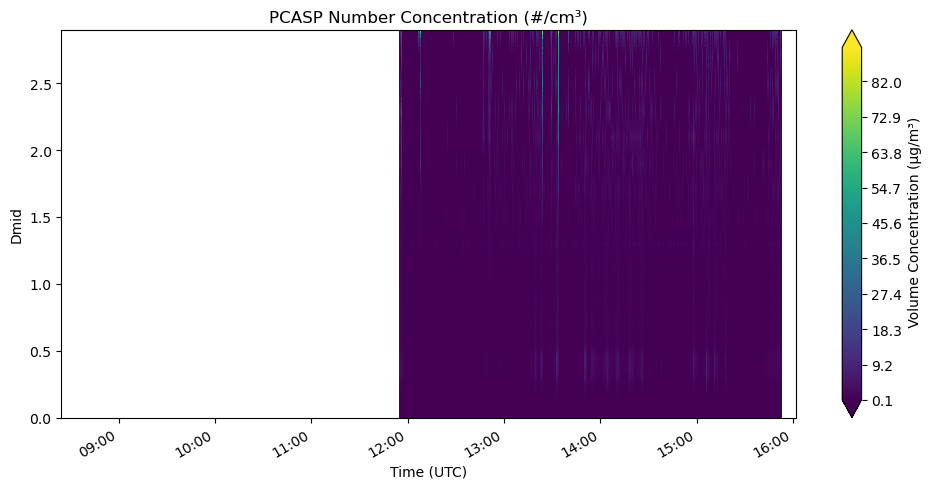

In [88]:
# --- Collect PCASP channels ---
pcasp_channels = [f"PCAS2_{i:02d}" for i in range(1, 31)]
da_pcasp = xr.concat([ds_core_cloud[v] for v in pcasp_channels], dim="PCAS2CH")
da_pcasp = da_pcasp.where(da_pcasp != 9999)  # remove fill values (#/cm³)
#da_pcasp = da_pcasp.resample(PCAS2TSPM="1min").mean(skipna=True)

# bin limits (µm)
D_lower_limits = ds_core_cloud['PCAS2_D_L_NOM'].values   # shape (30,)
D_upper_limits = ds_core_cloud['PCAS2_D_U_NOM'].values

# mid diameters (µm)
D_mid = (D_lower_limits + D_upper_limits) / 2.0
D_mid = np.nan_to_num(D_mid, nan=0.0)  # replace NaNs with 0

# particle volume (µm^3) per particle assuming spheres:
V_particle = (np.pi / 6.0) * (D_mid**3)   # shape (30,)

# make volumes an xarray aligned on PCAS2CH
da_V_particle = xr.DataArray(
    V_particle, dims=["PCAS2CH"], coords={"PCAS2CH": da_pcasp["PCAS2CH"]}
)

# volume concentration per bin (µm^3 / cm^3)
vol_conc_bins = da_pcasp * da_V_particle

# mass concentration per bin (µg / m^3)
mass_conc_bins = vol_conc_bins * density  # µg/m³ per bin

Z = mass_conc_bins   # shape: (channels, time) → (30,445)
# --- Prepare axes data ---
time_pcasp = da_pcasp["PCAS2TSPM"].values  # datetime64 array, shape (N_time,)
channels = np.arange(1, len(da_pcasp["PCAS2CH"]) + 1)  # 1 to 30
#Z = da_pcasp.values  # shape should be (N_channels, N_time)

fig, ax = plt.subplots(figsize=(10, 5))

#vmin, vmax = 1, 1000  # define limits
#levels = np.linspace(vmin,vmax,100)
# --- Plot ---
cs = ax.contourf(
    time_pcasp,   # x-axis (datetime)
    D_mid,     # y-axis (channel number)
    Z,            # 2D array (channels × time)
    levels=1000,
    cmap="viridis",
    extend='both', 
)

# --- Formatting ---
#ax.set_yscale('log')
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Dmid")
ax.set_title("PCASP Number Concentration (#/cm³)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()


cbar = fig.colorbar(cs,label=" Volume Concentration (µg/m³)")

# define evenly spaced ticks
#tick_values = np.linspace(vmin, vmax, 6)
#cbar.set_ticks(tick_values)
#cbar.set_ticklabels([f"{int(t)}" for t in tick_values])

plt.tight_layout()
plt.show()


In [89]:
def plot_pcasp_concentration(ds_core_cloud, density=1.8,vmin=0,vmax=1000):
    """
    Plot PCASP number (or mass) concentration as a contour plot vs time and D_mid.
    
    Parameters
    ----------
    ds_core_cloud : xarray.Dataset
        Dataset containing PCASP measurements and bin diameter information.
    density : float, optional
        Particle density in g/cm³ (default = 1.8).
    vmin, vmax : float, optional
        Minimum and maximum limits for color scaling.
    """

    # --- Collect PCASP channels ---
    pcasp_channels = [f"PCAS2_{i:02d}" for i in range(1, 31)]
    da_pcasp = xr.concat([ds_core_cloud[v] for v in pcasp_channels], dim="PCAS2CH")
    da_pcasp = da_pcasp.where(da_pcasp != 9999)  # remove fill values (#/cm³)
    da_pcasp = da_pcasp.resample(PCAS2TSPM="1min").mean(skipna=True)  # optional resampling

    # --- Bin limits (µm) ---
    D_lower_limits = ds_core_cloud['PCAS2_D_L_NOM'].values
    D_upper_limits = ds_core_cloud['PCAS2_D_U_NOM'].values

    # --- Mid diameters (µm) ---
    D_mid = (D_lower_limits + D_upper_limits) / 2.0
    D_mid = np.nan_to_num(D_mid, nan=0.0)  # replace NaNs with 0

    # --- Particle volume (µm³) per particle (assuming spheres) ---
    V_particle = (np.pi / 6.0) * (D_mid ** 3)

    # --- Convert to xarray aligned on PCAS2CH ---
    da_V_particle = xr.DataArray(
        V_particle, dims=["PCAS2CH"], coords={"PCAS2CH": da_pcasp["PCAS2CH"]}
    )

    # --- Volume and mass concentration per bin ---
    vol_conc_bins = da_pcasp * da_V_particle  # µm³/cm³
    mass_conc_bins = vol_conc_bins * density  # µg/m³ per bin

    # --- Prepare plot data ---
    Z = mass_conc_bins  # shape: (channels, time)
    time_pcasp = da_pcasp["PCAS2TSPM"].values

    # --- Create plot ---
    fig, ax = plt.subplots(figsize=(10, 5))

    cs = ax.contourf(
        time_pcasp,
        D_mid,
        Z,
        levels=100,
        cmap="viridis",
        extend='both',
        norm=LogNorm()
    )

    # --- Formatting ---
    ax.set_xlabel("Time (UTC)")
    ax.set_ylabel("Dmid (µm)")
    ax.set_title("PCASP Number Concentration (#/cm³)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.autofmt_xdate()

    # --- Colorbar ---
    cbar = fig.colorbar(cs, label="Volume Concentration (µg/m³)")

    plt.tight_layout()
    plt.show()

    return 

In [90]:
def plot_pcasp_concentration_v2(da_pcasp,D_mid, density=1.8,vmin=0,vmax=1000):

    # --- Particle volume (µm³) per particle (assuming spheres) ---
    V_particle = (np.pi / 6.0) * (D_mid ** 3)

    # --- Convert to xarray aligned on PCAS2CH ---
    da_V_particle = xr.DataArray(
        V_particle, dims=["PCAS2CH"], coords={"PCAS2CH": da_pcasp["PCAS2CH"]}
    )

    # --- Volume and mass concentration per bin ---
    vol_conc_bins = da_pcasp * da_V_particle  # µm³/cm³
    mass_conc_bins = vol_conc_bins * density  # µg/m³ per bin

    # --- Prepare plot data ---
    Z = mass_conc_bins  # shape: (channels, time)
    time_pcasp = da_pcasp["PCAS2TSPM"].values

    # --- Create plot ---
    fig, ax = plt.subplots(figsize=(10, 5))

    cs = ax.contourf(
        time_pcasp,
        D_mid,
        Z,
        levels=100,
        cmap="viridis",
        extend='both',
    )

    # --- Formatting ---
    ax.set_xlabel("Time (UTC)")
    ax.set_ylabel("Dmid (µm)")
    ax.set_title("PCASP Number Concentration (#/cm³)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.autofmt_xdate()

    # --- Colorbar ---
    cbar = fig.colorbar(cs, label="Volume Concentration (µg/m³)")

    plt.tight_layout()
    plt.show()

    return 

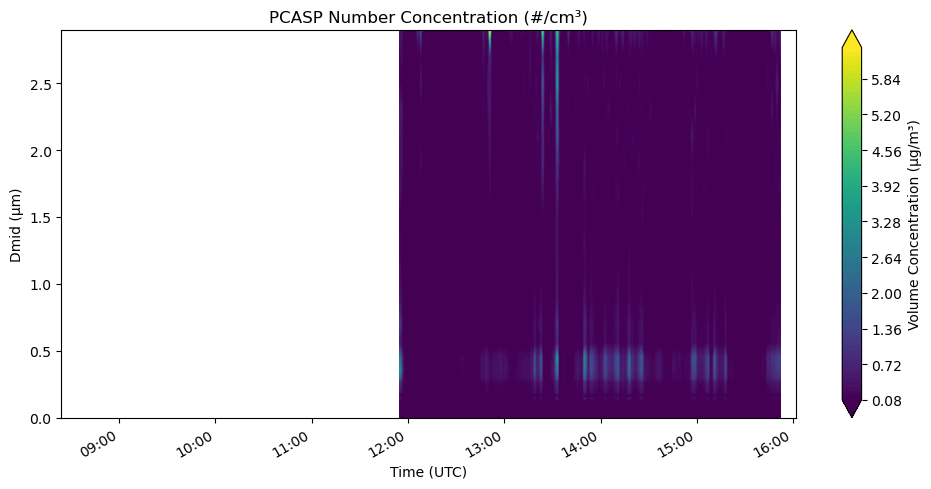

In [91]:
da_pcasp, times_cloud, Dgs = extract_pcasp_geo_diameter(ds_core_cloud)
da_pcasp = da_pcasp.resample(PCAS2TSPM="1min").mean(skipna=True)  # optional resampling
# --- Bin limits (µm) ---
D_lower_limits = ds_core_cloud['PCAS2_D_L_NOM'].values
D_upper_limits = ds_core_cloud['PCAS2_D_U_NOM'].values

# --- Mid diameters (µm) ---
D_mid = (D_lower_limits + D_upper_limits) / 2.0
D_mid = np.nan_to_num(D_mid, nan=0.0)
plot_pcasp_concentration_v2(da_pcasp,D_mid)

In [20]:
print(da_pcasp)

<xarray.DataArray 'PCAS2_01' (PCAS2CH: 30, PCAS2TSPM: 459)> Size: 55kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * PCAS2TSPM  (PCAS2TSPM) datetime64[ns] 4kB 2012-09-23T08:24:00 ... 2012-09...
Dimensions without coordinates: PCAS2CH
Attributes:
    units:      cm-3
    Number:     9999
    frequency:  1
    long_name:  PCASP2 (SPP200) conc in size channel 1
    comment:    Concentrations corrected for aspiration efficiencies using ca...


/tmp/ipykernel_645/1231639765.py:48: UserWarning: Log scale: values of z <= 0 have been masked
  cs = ax.contourf(


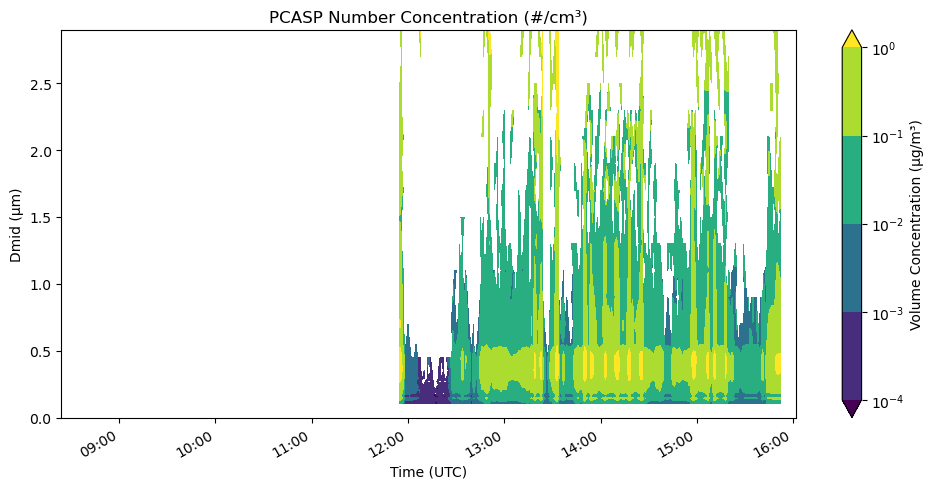

In [21]:
plot_pcasp_concentration(ds_core_cloud)

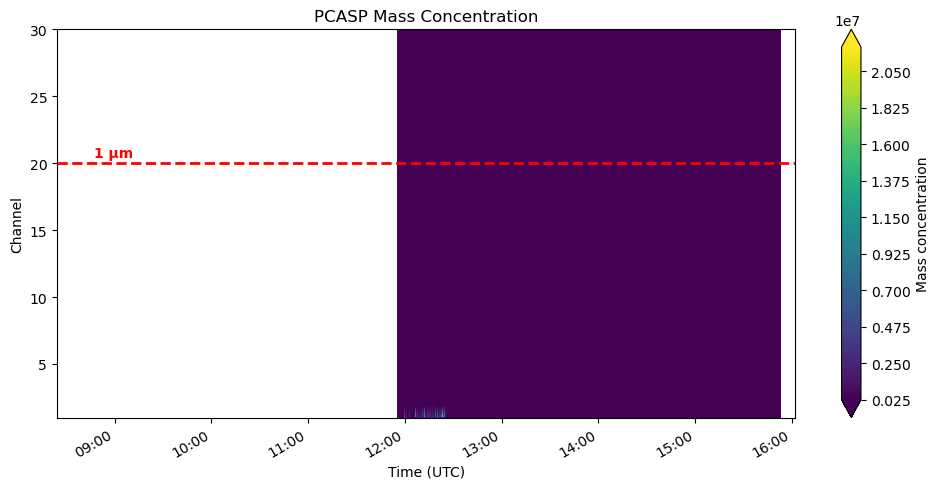

In [22]:
# --- Collect PCASP channels ---
pcasp_channels = [f"PCAS2_{i:02d}" for i in range(1, 31)]
da_pcasp = xr.concat([ds_core_cloud[v] for v in pcasp_channels], dim="PCAS2CH")
da_pcasp = da_pcasp.where(da_pcasp != 9999)  # remove fill values (#/cm³)
#da_pcasp = da_pcasp.resample(PCAS2TSPM="1min").mean(skipna=True)

Z = mass_conc_bins   # shape: (channels, time) → (30,445)
# --- Prepare axes data ---
time_pcasp = da_pcasp["PCAS2TSPM"].values  # datetime64 array, shape (N_time,)
channels = np.arange(1, len(da_pcasp["PCAS2CH"]) + 1)  # 1 to 30
Z = da_pcasp.values  # shape should be (N_channels, N_time)

fig, ax = plt.subplots(figsize=(10, 5))

vmin, vmax = 1, 1000  # define limits
levels = 100
# --- Plot ---
cs = ax.contourf(
    time_pcasp,   # x-axis (datetime)
    channels,     # y-axis (channel number)
    Z,            # 2D array (channels × time)
    levels=levels,
    cmap="viridis",
    extend='both' 
)

# --- Add red line for 1 µm (channel 20) ---
channel_1um = 20
ax.axhline(y=channel_1um, color='red', linestyle='--', linewidth=2, label='1 µm')

# Add text label near the line
ax.text(
    time_pcasp[len(time_pcasp)//20],  # position ~5% along x-axis
    channel_1um + 0.5,
    "1 µm",
    color='red',
    fontsize=10,
    fontweight='bold'
)

# --- Formatting ---
#ax.set_yscale('log')
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Channel")
ax.set_title("PCASP Mass Concentration")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()


cbar = fig.colorbar(cs,label="Mass concentration")

# define evenly spaced ticks
#tick_values = np.linspace(vmin, vmax, 6)
#cbar.set_ticks(tick_values)
#cbar.set_ticklabels([f"{int(t)}" for t in tick_values])

plt.tight_layout()
plt.show()


In [23]:
def plot_flight_summary_and_regressions(df_all_one_file):
    """
    Plot for each flight:
      - altitude vs. index
      - CO vs. index
      - TSC_green vs. index
      - pie chart of average composition (SO4, NH4, NO3, ORG, BC)
    And, at the end, show NNLS and WLS regression diagnostics comparing
    predicted vs. measured TSC_green.

    Parameters
    ----------
    df_all_one_file : pandas.DataFrame
        Combined dataset containing all flights with variables:
        ['TSC_green', 'BC', 'ORG', 'SO4', 'NH4', 'NO3', 'ORG_UNC', 'SO4_UNC',
         'NH4_UNC', 'NO3_UNC', 'ALT', 'CO', 'Flight']
    """
    # --- Loop over each flight
    flights = df_all_one_file['Flight'].unique()

    for flight in flights:
        df_flight = df_all_one_file[df_all_one_file['Flight'] == flight]

        # --- Composition for pie
        species = ['SO4', 'NH4', 'NO3', 'ORG', 'BC']
        avg_composition = df_flight[species].mean()
        total_mass = avg_composition.sum()
        percentages = 100 * avg_composition / total_mass

        # --- Figure layout
        fig, axes = plt.subplots(5, 1, figsize=(10, 15))
        fig.suptitle(f"Flight {flight} Summary", fontsize=16)

        # --- Altitude
        axes[0].plot(df_flight.index, df_flight['ALT'],'.', color='tab:blue')
        axes[0].set_ylabel("Altitude (m)")
        axes[0].grid(True, linestyle='--', alpha=0.5)

        # --- CO
        axes[1].plot(df_flight.index, df_flight['CO'],'.', color='tab:orange')
        axes[1].set_ylabel("CO (ppbv)")
        axes[1].grid(True, linestyle='--', alpha=0.5)

        # --- CO/ORG
        axes[2].plot(df_flight.index, df_flight['CO']/df_flight['ORG'],'.', color='tab:Red')
        axes[2].set_ylabel("CO/ORG")
        axes[2].grid(True, linestyle='--', alpha=0.5)

        # --- Scattering
        axes[3].plot(df_flight.index, df_flight['TSC_green'] * 1e6,'.', color='tab:green')
        axes[3].set_ylabel("TSC_green (Mm⁻¹)")
        axes[3].grid(True, linestyle='--', alpha=0.5)

        # --- Pie chart
        wedges, texts, autotexts = axes[4].pie(
            avg_composition,
            labels=species,
            autopct=lambda p: f"{p:.1f}%",
            startangle=140,
            textprops={'color': "w"}
        )
        axes[4].set_title("Mean Composition")
        axes[4].legend(
            [f"{sp}: {pct:.1f}%" for sp, pct in zip(species, percentages)],
            loc="center left",
            bbox_to_anchor=(1, 0.5),
        )

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    return 

In [99]:
filtered_neph

['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/mo-non-core/metoffice-neph1_faam_20120918_r1_b734.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/mo-non-core/metoffice-neph1_faam_20120920_r1_b737.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/mo-non-core/metoffice-neph1_faam_20120923_r1_b739.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b742-sep-27/mo-non-core/metoffice-neph1_faam_20120927_r1_b742.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b743-sep-27/mo-non-core/metoffice-neph1_faam_20120927_r1_b743.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b744-sep-28/mo-non-core/metoffice-neph1_faam_20120928_r1_b744.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b745-sep-28/mo-non-core/metoffice-neph1_faam_20120928_r1_b745.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b746-sep-29/mo-non-core/metoffice-n

In [100]:
results_sct_all = []

# Iterate over all matching flights
for sp2_file, ams_file, core_file, neph_file, cloud_file in zip(filtered_sp2, filtered_ams, filtered_core, filtered_neph,filtered_cloud):
    
    ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(sp2_file,ams_file,neph_file)
    ds_core = xr.open_dataset(core_file)
    ds_core_cloud = xr.open_dataset(cloud_file)
    da_pcasp, times_cloud, Dgs = extract_pcasp_geo_diameter(ds_core_cloud)
    series = pd.Series(Dgs, index=pd.to_datetime(times_cloud))

    # Resample to 1-minute mean
    ams_resampled, sp2_resampled = file_ams_sp2_treatment_v3(ds_sp2,ds_ams)
    resampled_neph = ds_neph.resample(datetime='1min').mean()
    resampled_core = ds_core.resample(Time='1min').mean()
    resampled_core_filtered = resampled_core.where(resampled_core["CO_AERO_FLAG"] == 0, drop=True)
    Dgs_1min = series.resample("1min").mean()
    da_pcasp_resampled = da_pcasp.resample(PCAS2TSPM="1min").mean(skipna=True)
    
    
    resampled_neph_time = resampled_neph["time"].values  # Reference timestamps
    ams_resampled_time = ams_resampled["time"].values
    sp2_resampled_time = sp2_resampled["time"].values
    resampled_core_time = resampled_core_filtered["data_point"].values
    
    
    #print(f"Number of timestamps Neph: {len(resampled_neph_time)}")
    #print(f"Number of timestamps AMS: {len(ams_resampled_time)}")
    #print(f"Number of timestamps SP2: {len(sp2_resampled_time)}")
    #print(f"Number of timestamps Dg: {len(Dgs_1min)}")
    #print(f"Number of timestamps core: {len(resampled_core_time)}")
    
    # First find common times between neph and AMS
    common_times = np.intersect1d(resampled_neph_time, ams_resampled_time)
    
    # Then intersect with SP2
    common_times = np.intersect1d(common_times, sp2_resampled_time)
    # Then intersect with CORE
    common_times = np.intersect1d(common_times, resampled_core_time)
    
    #print(f"Number of common timestamps: {len(common_times)}")
    
    
    core_file_matched = resampled_core_filtered.sel(data_point=common_times)
    ams_resampled_matched = ams_resampled.sel(time=common_times)
    sp2_resampled_matched = sp2_resampled.sel(time=common_times)
    resampled_neph_matched = resampled_neph.sel(time=common_times)
    Dg_aligned_matched = Dgs_1min.reindex(pd.to_datetime(common_times), method="nearest")
    da_pcasp_resampled_matched = da_pcasp_resampled.sel(PCAS2TSPM=common_times)
    
    #Core file variables
    Height = core_file_matched['GPS_ALT'].values.squeeze()
    Lon = core_file_matched['LON_GPS'].values.squeeze()
    Lat = core_file_matched['LAT_GPS'].values.squeeze()
    CO_conc_matched = core_file_matched['CO_AERO'].values.squeeze()
    PSAP_matched = core_file_matched['PSAP_LIN'].values.squeeze()
    #Neph file variables
    TSC_blue = resampled_neph_matched["TSC_BLUU"].values.squeeze()
    TSC_green = resampled_neph_matched["TSC_GRNU"].values.squeeze()
    TSC_red = resampled_neph_matched["TSC_REDU"].values.squeeze()
    #Sp2 file variables
    BC = sp2_resampled_matched.values
    #AMS file variables
    ORG = ams_resampled_matched['ORG'].values
    ORG_unc = ams_resampled_matched['ORG_uncertainty'].values
    SO4 = ams_resampled_matched['SO4'].values
    SO4_unc = ams_resampled_matched['SO4_uncertainty'].values
    NH4 = ams_resampled_matched['NH4'].values
    NH4_unc = ams_resampled_matched['NH4_uncertainty'].values
    NO3 = ams_resampled_matched['NO3'].values
    NO3_unc = ams_resampled_matched['NO3_uncertainty'].values
    AS = ams_resampled_matched['NH4_2SO4'].values
    AN = ams_resampled_matched['NH4NO3'].values
    #PCASP variables
    Dg = Dg_aligned_matched
    #pcasp_time = da_pcasp_resampled_matched['PCAS2TSPM'].values
    #pcasp_ch = da_pcasp_resampled_matched['PCAS2CH'].values
    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', core_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    print(flight_number)
    
    results_sct_all.append({
        'ORG': ORG,
        'BC': BC,
        'SO4': SO4,
        'NH4': NH4,
        'NO3': NO3,
        'AS': AS,
        'AN': AN,
        'TSC_blue':TSC_blue,
        'TSC_green':TSC_green,
        'TSC_red':TSC_red,
        'DG_aligned': Dg,
        'CO': CO_conc_matched,
        'ALT' : Height,
        'LON': Lon,
        'LAT': Lat,
        'PCASP': da_pcasp_resampled_matched,
        'flight': flight_number,
        'Time': core_file_matched['data_point'].values
    })


b734
b737
b739
b742
b743
b744
b745
b746
b748
b749


In [101]:
# Combine all flight data
combined_data = []
for entry in results_sct_all:
    try:
        df = pd.DataFrame({
            'TSC_blue': entry['TSC_blue'],
            'TSC_green': entry['TSC_green'],
            'TSC_red': entry['TSC_red'],
            'BC': entry['BC'],
            'ORG': entry['ORG'],
            'SO4': entry['SO4'],
            'NH4': entry['NH4'],
            'NO3': entry['NO3'],
            'DG': entry['DG_aligned'],
            'ALT' : entry['ALT'],
            'LON': entry['LON'],
            'LAT': entry['LAT'],
            'CO': entry['CO'],
            'Flight': entry['flight'],
        })

        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all_one_file = pd.concat(combined_data)

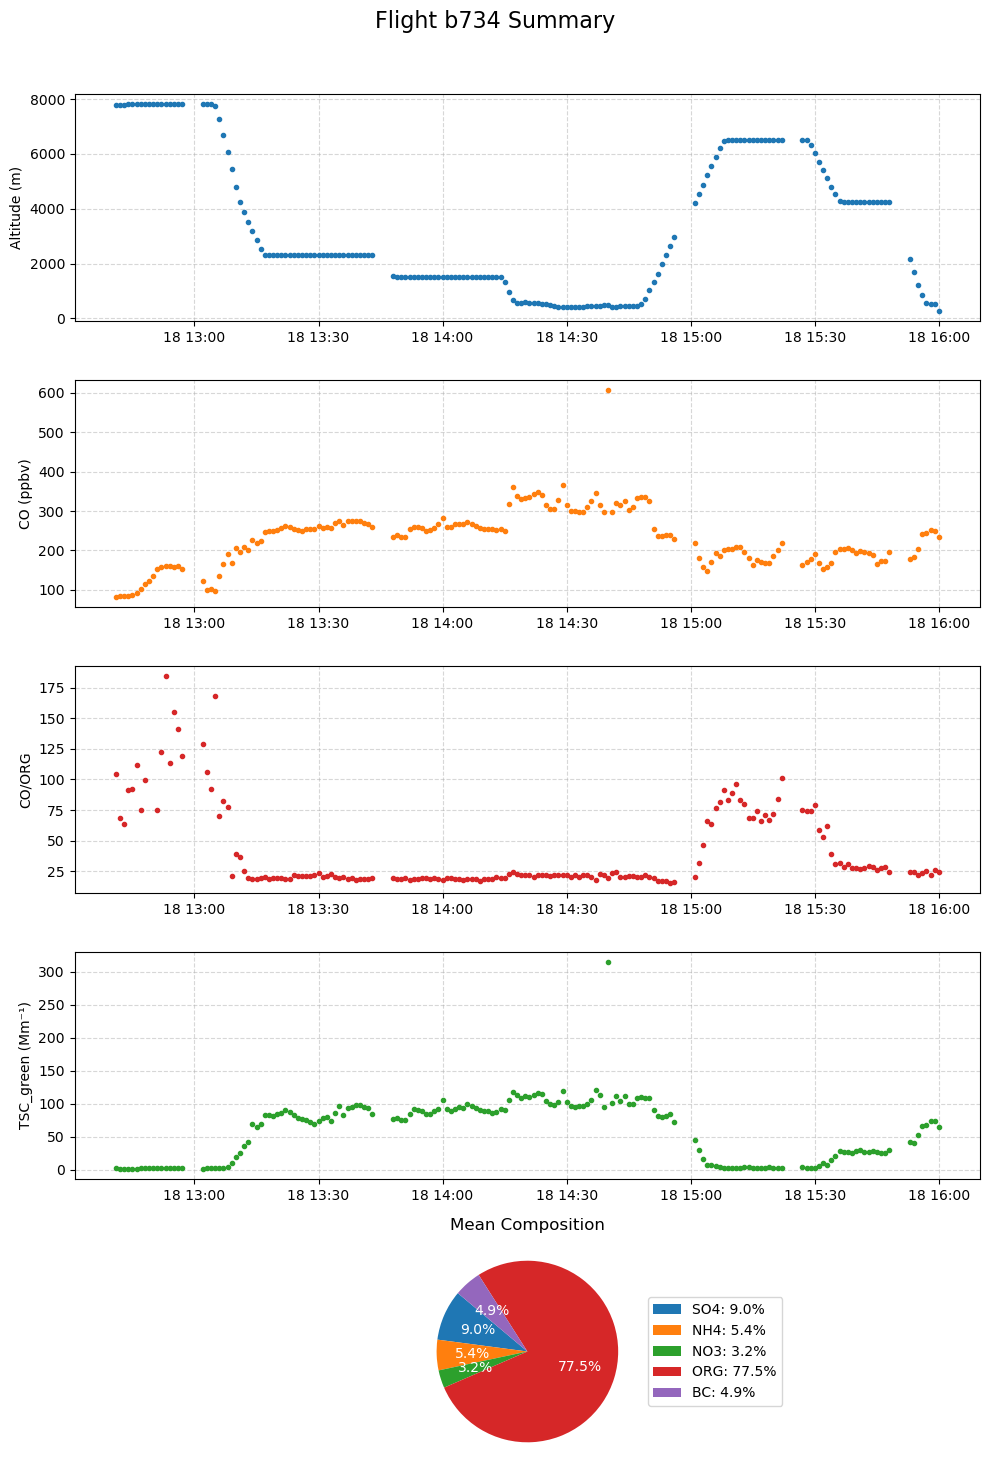

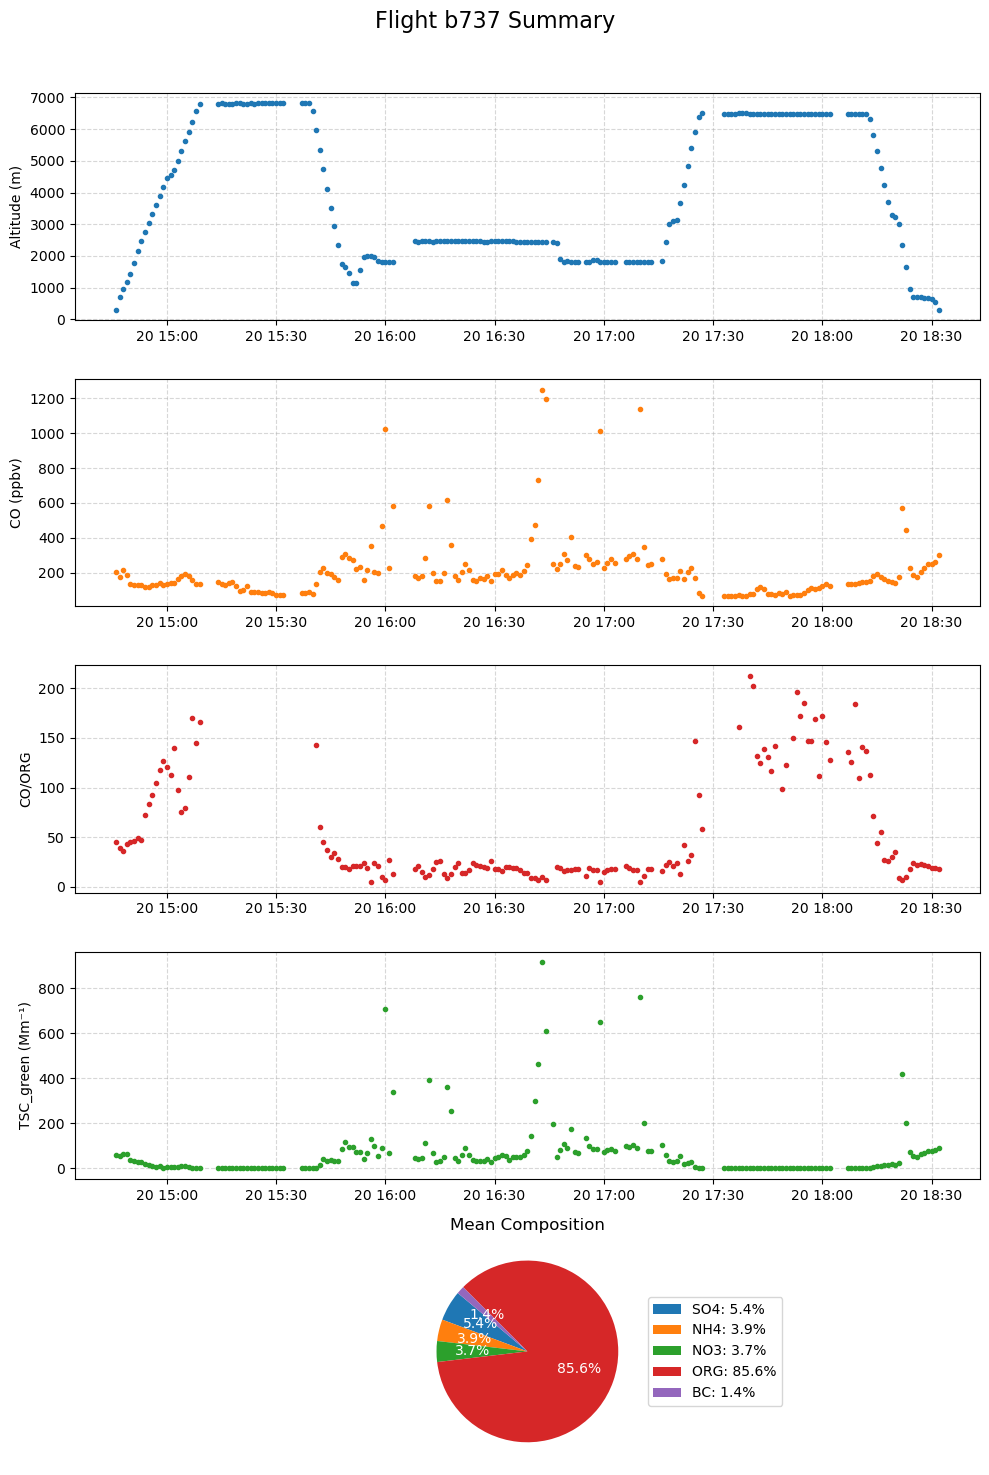

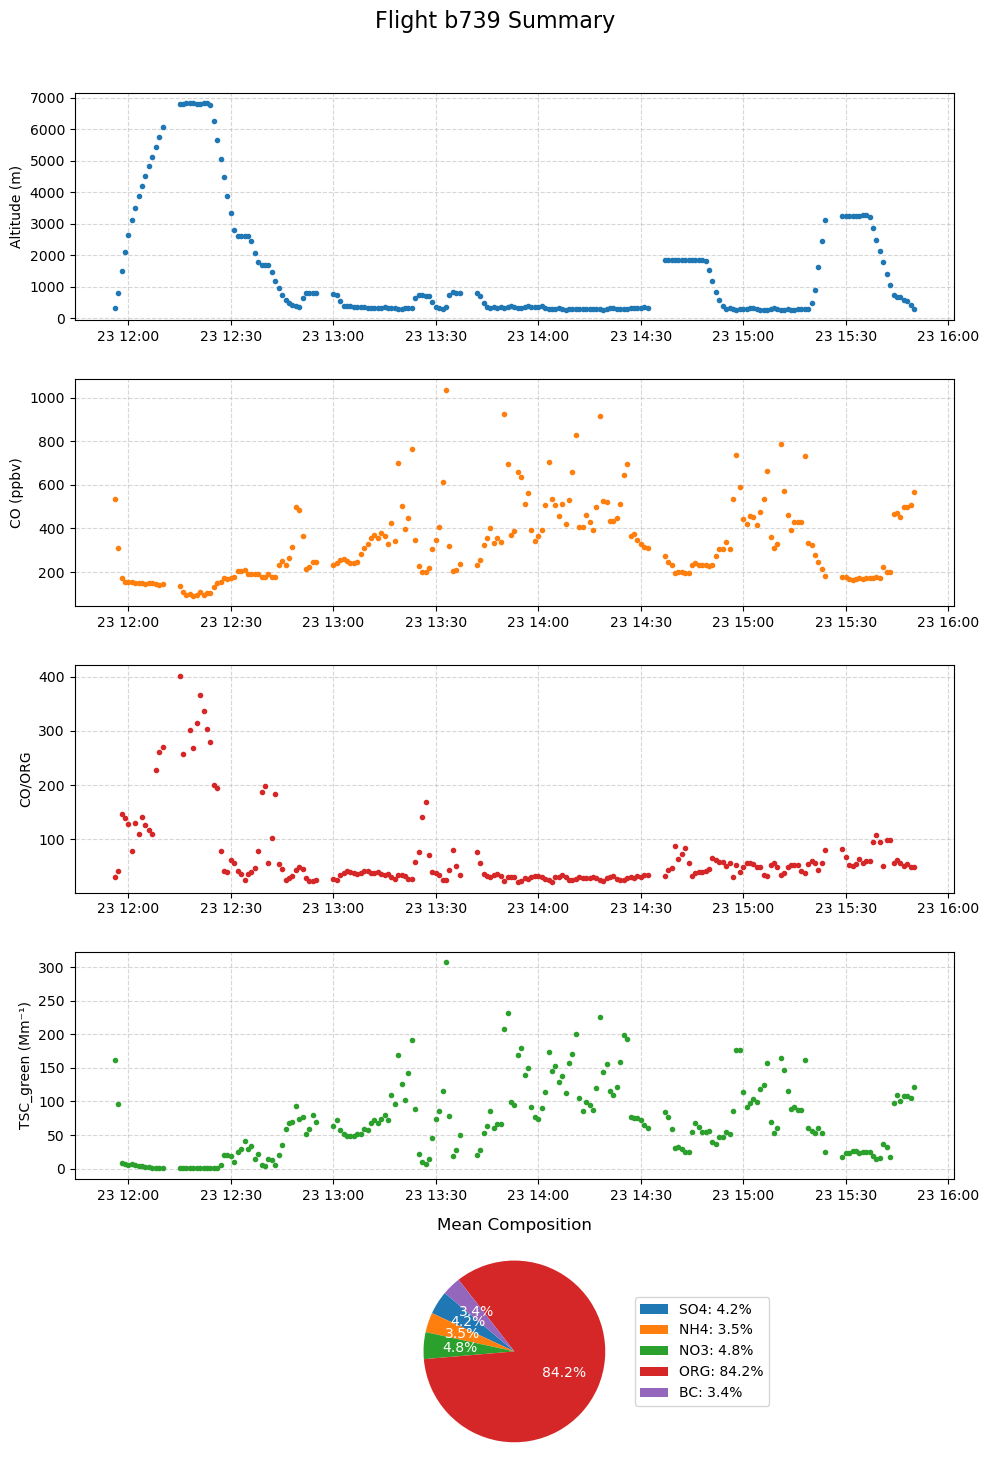

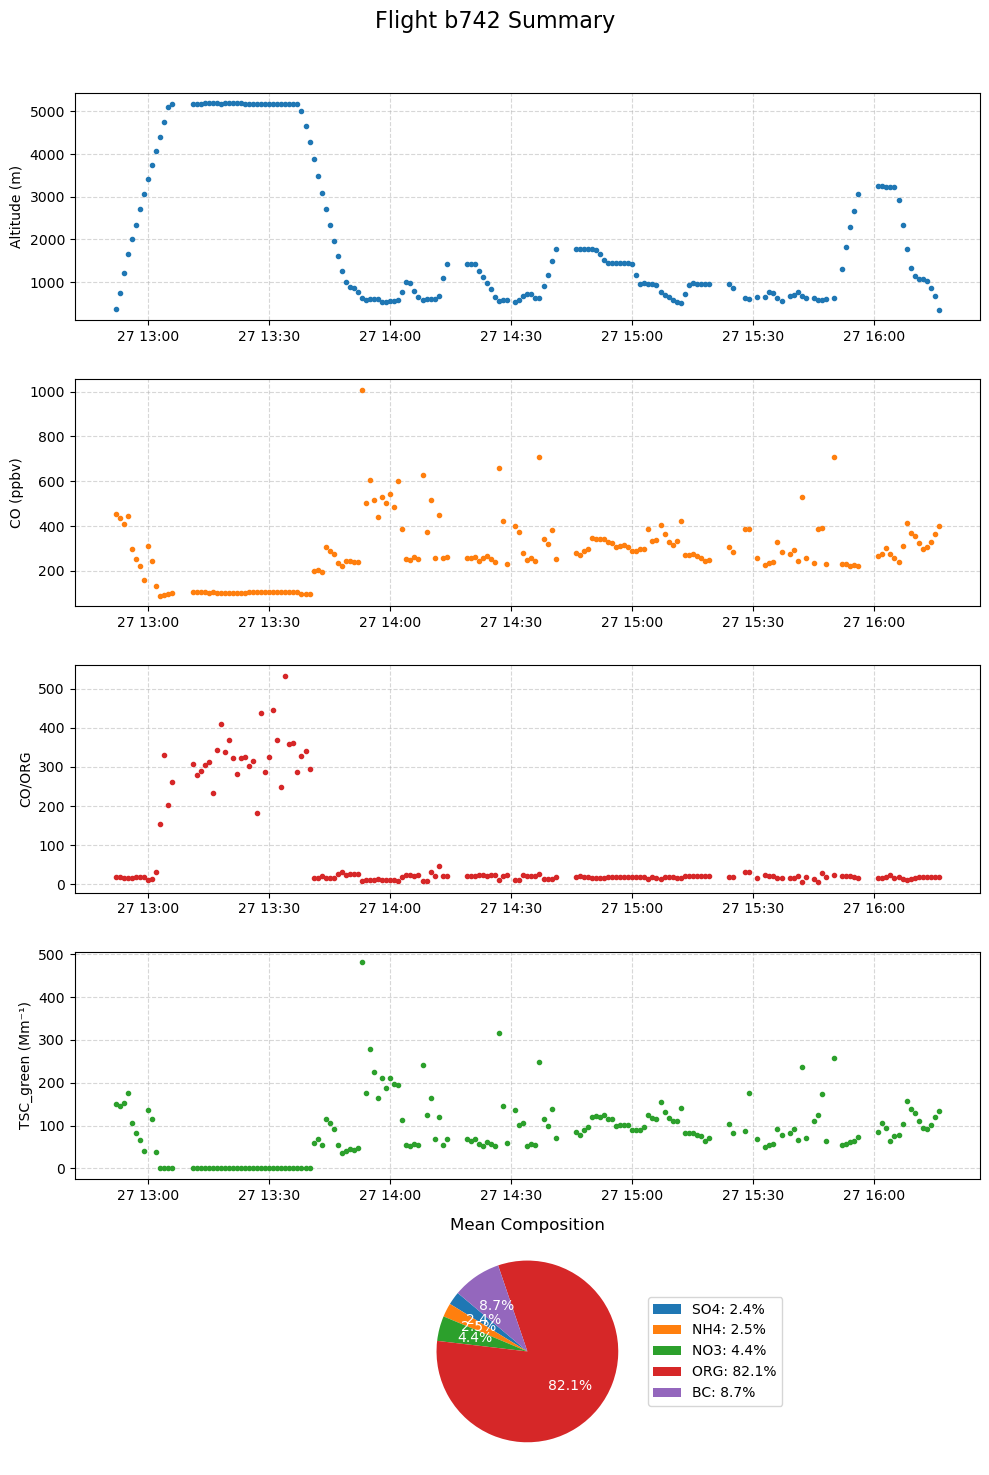

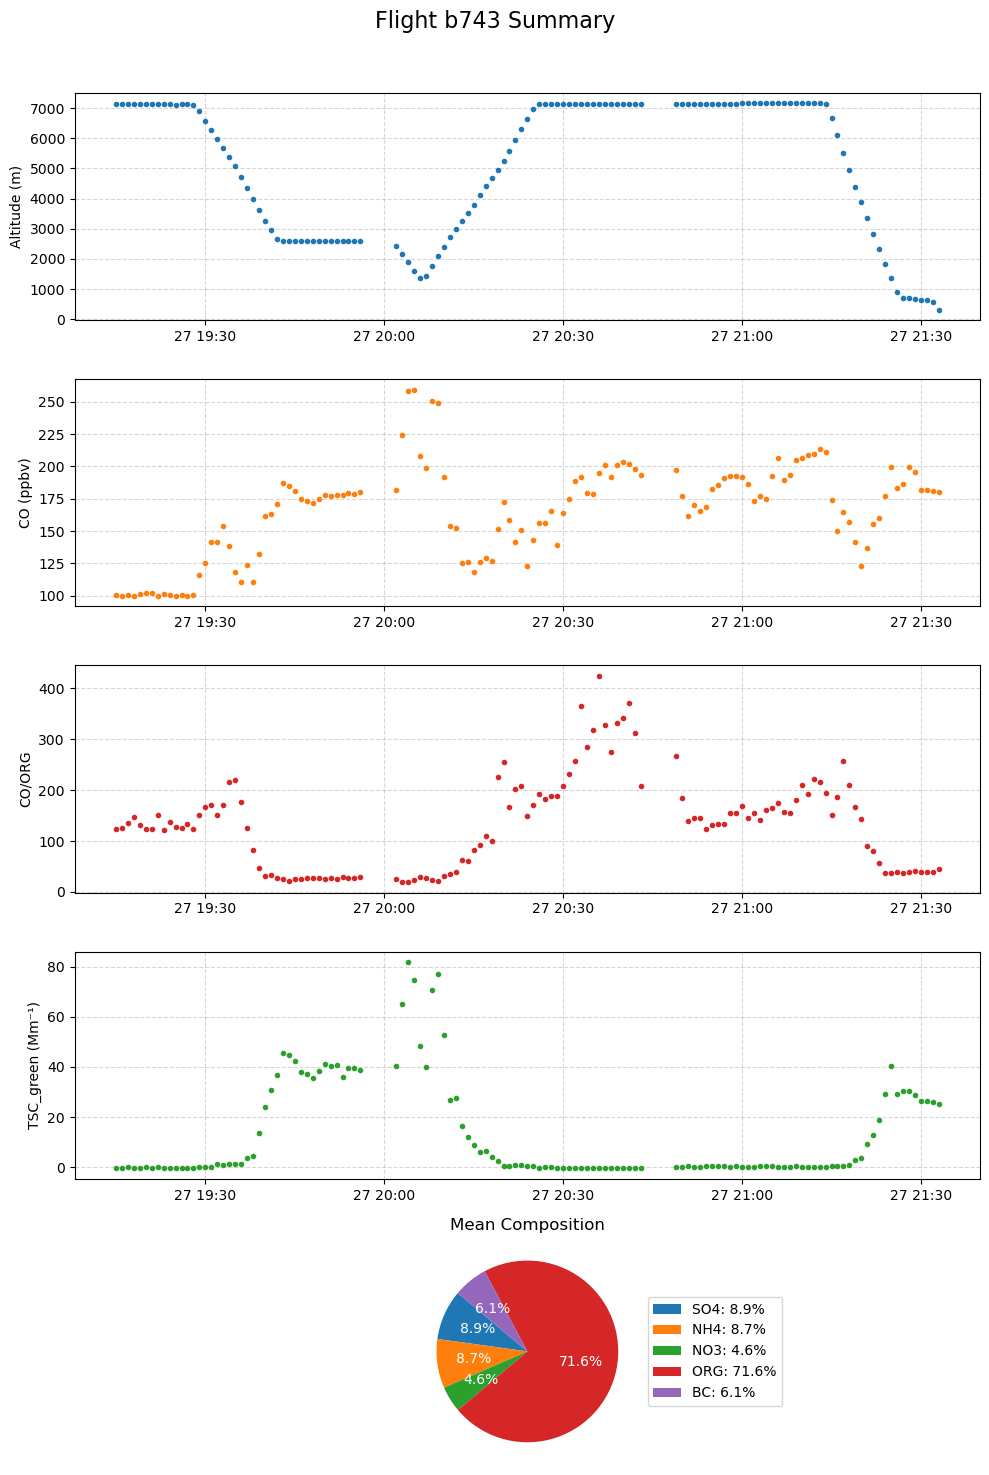

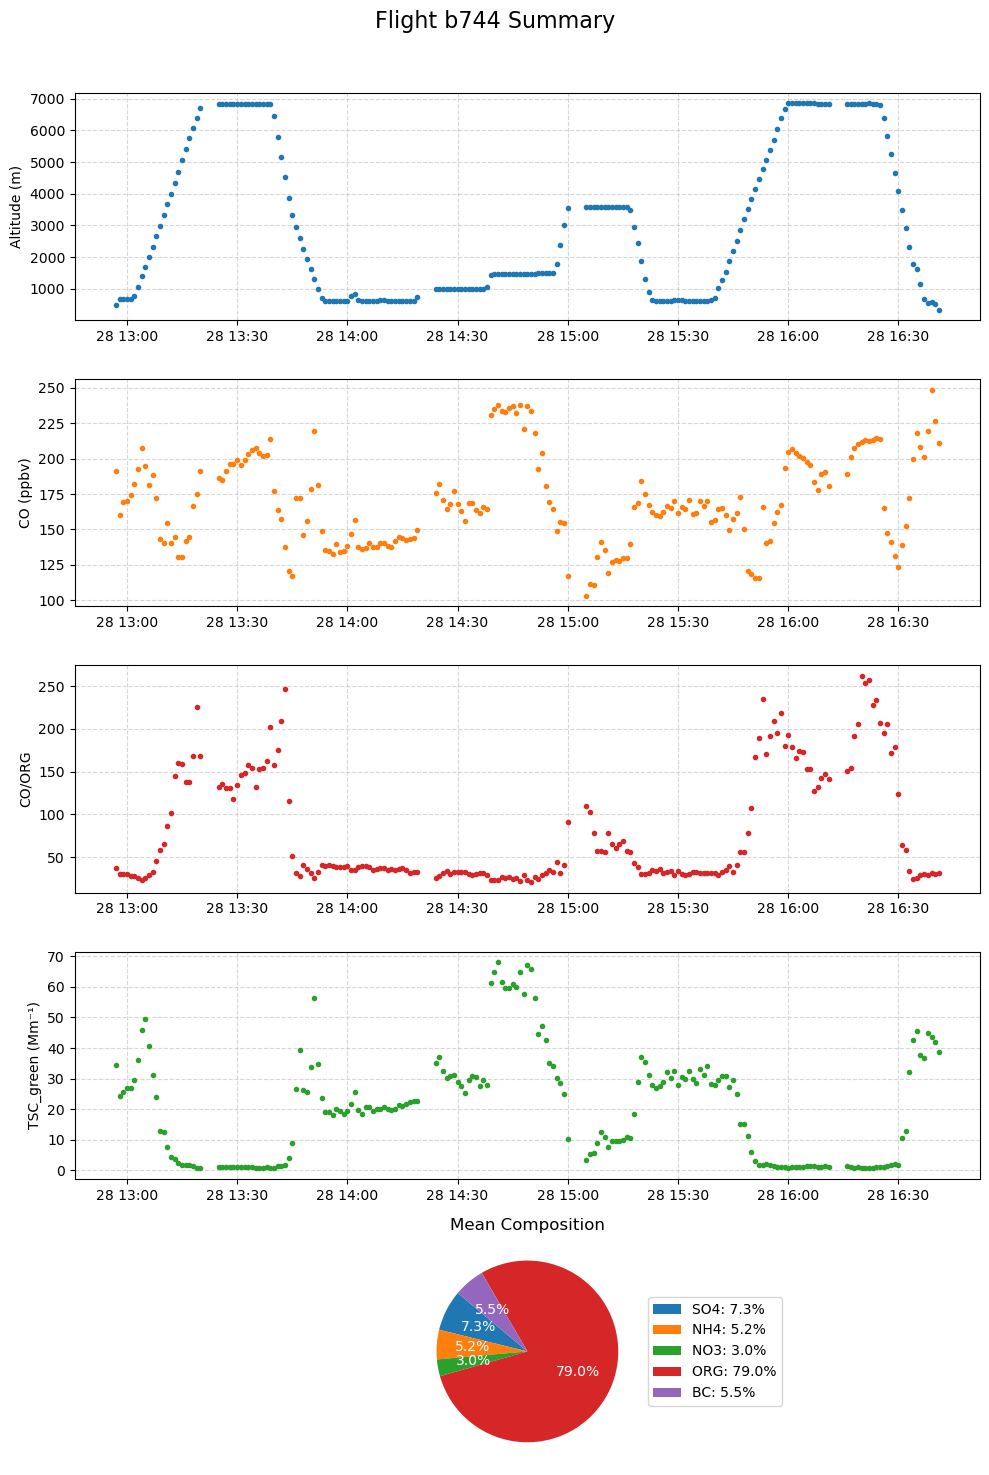

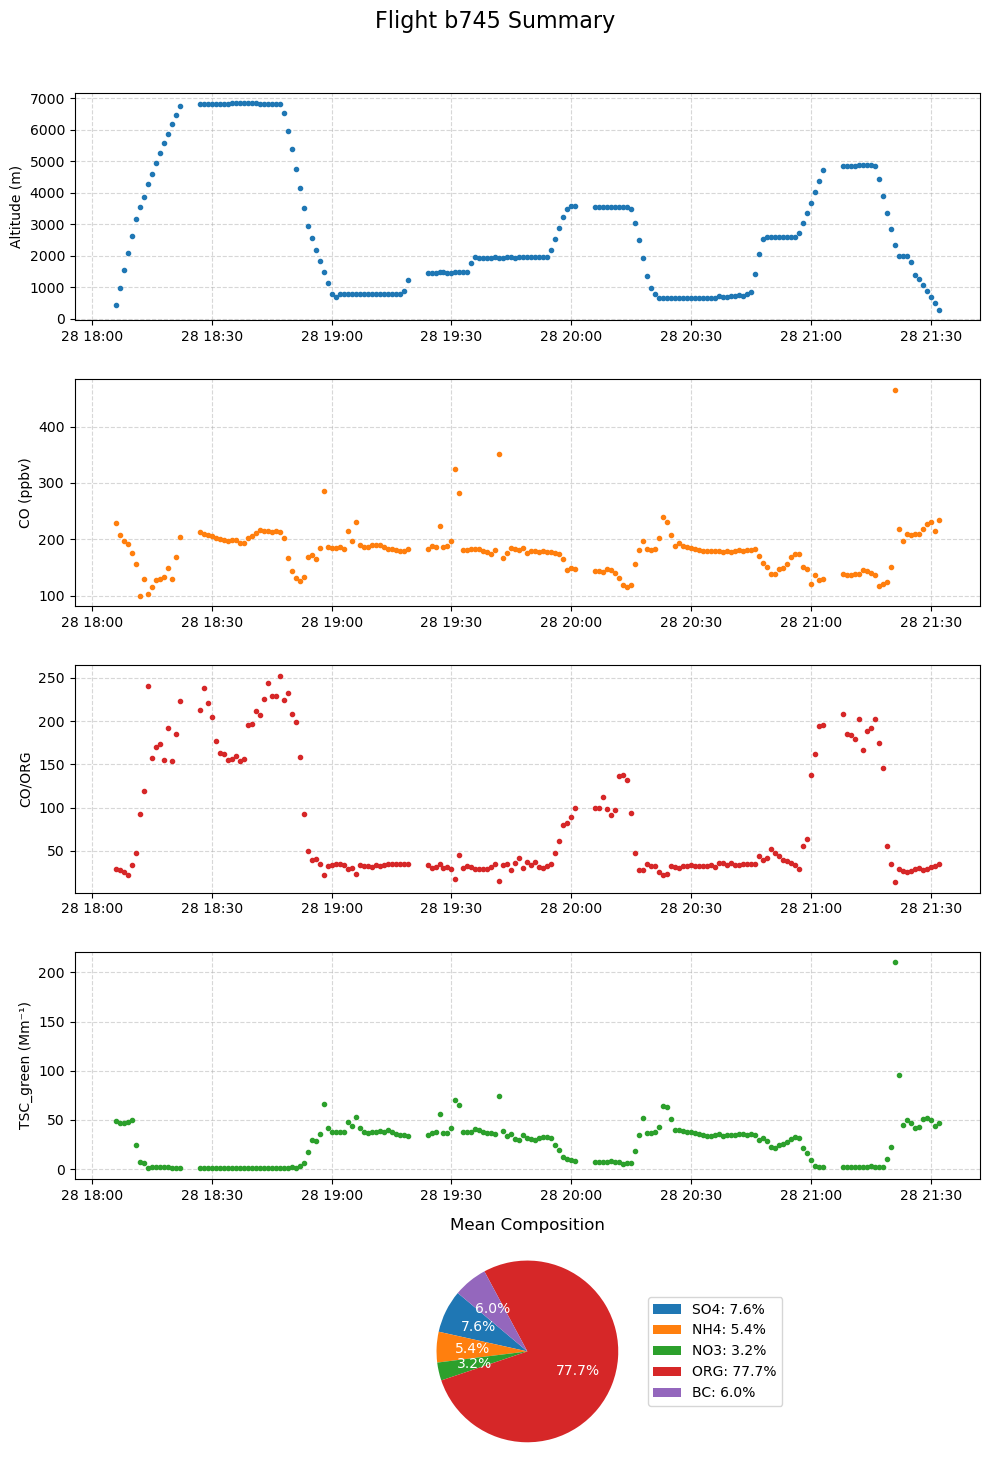

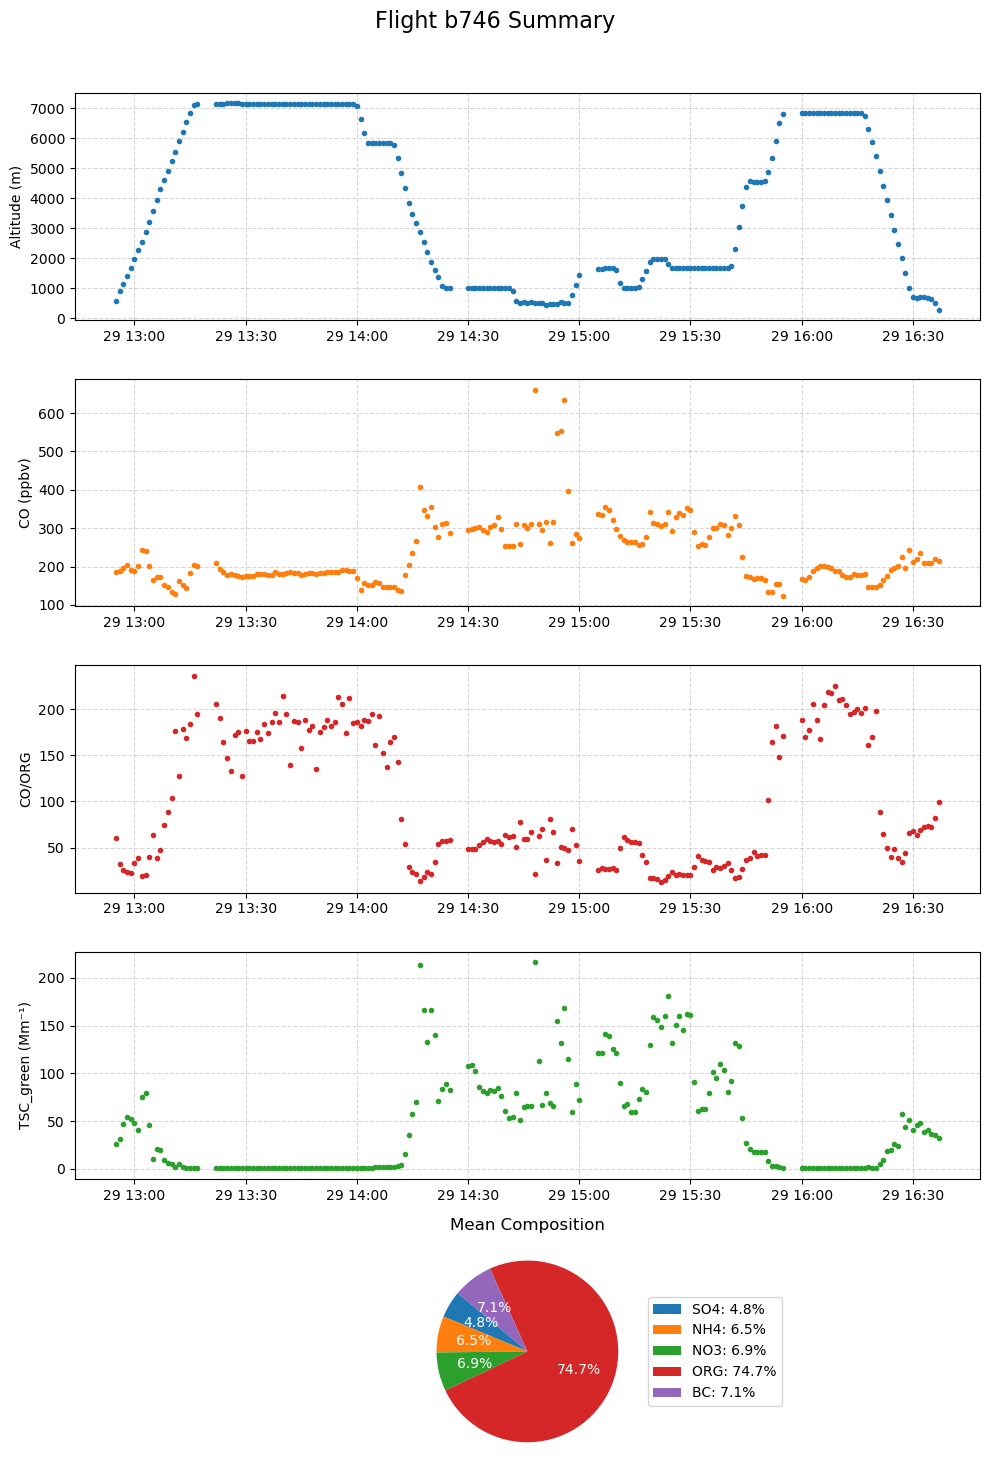

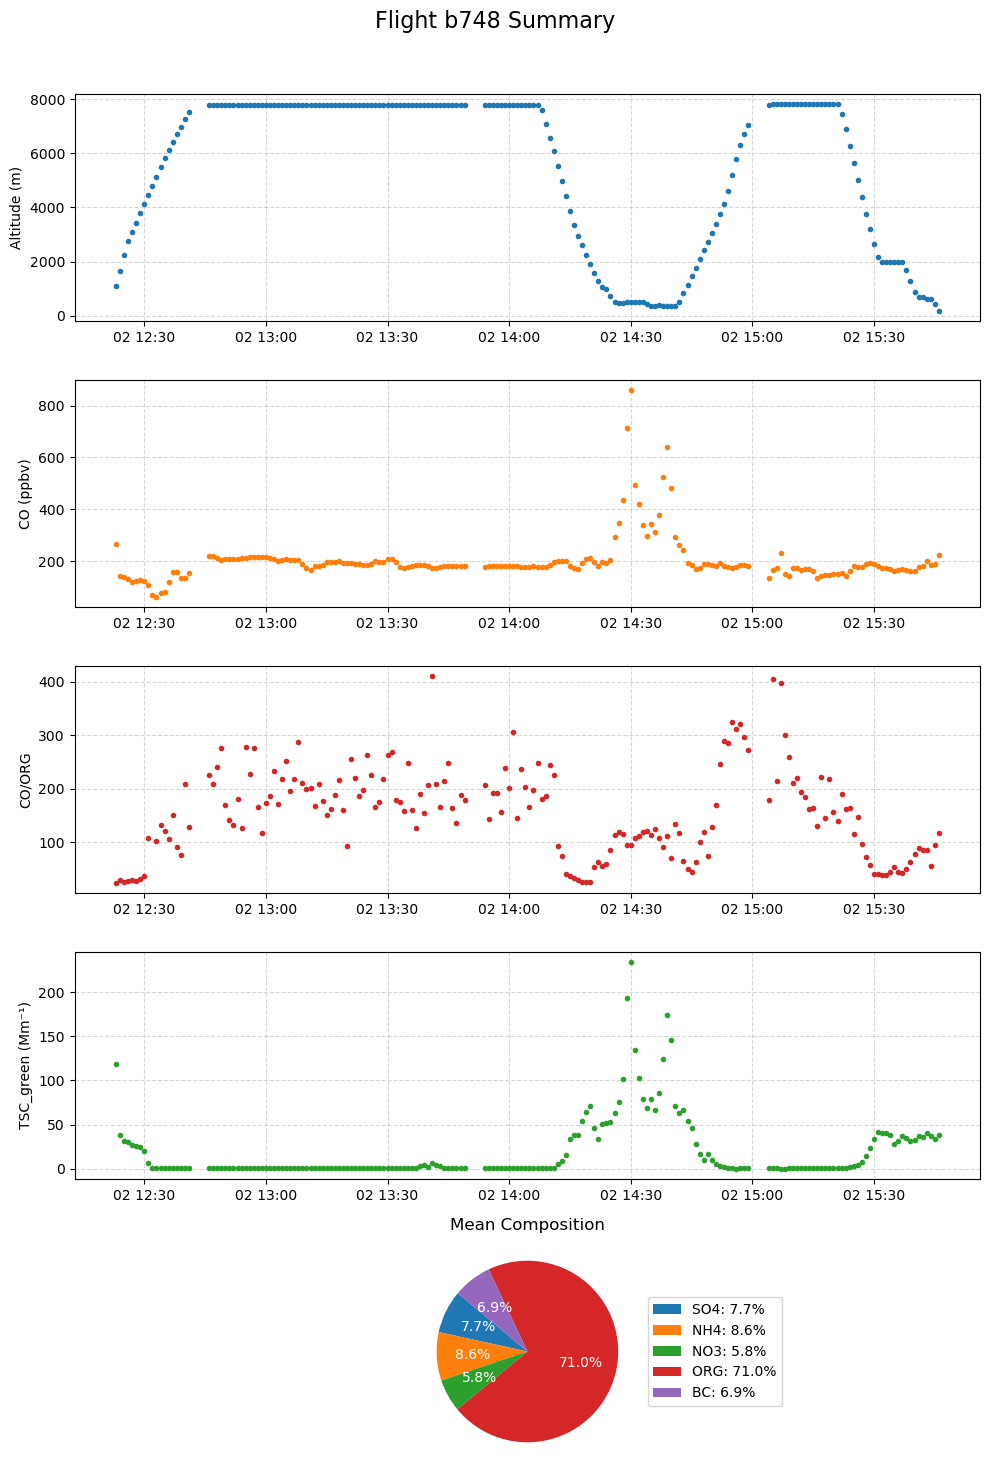

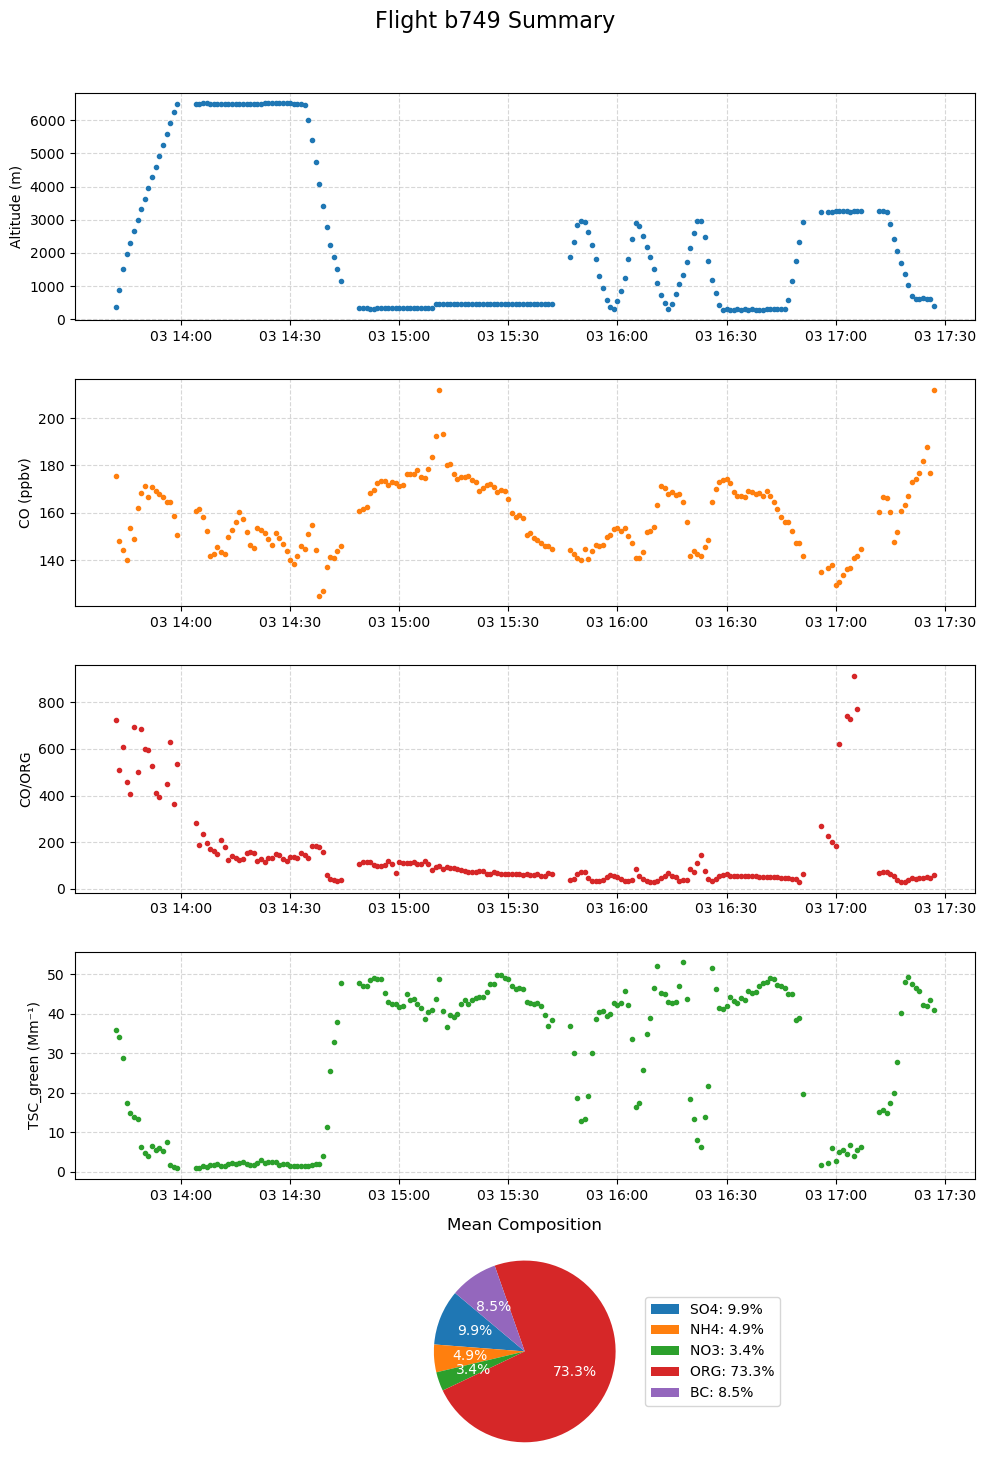

In [102]:
plot_flight_summary_and_regressions(df_all_one_file)

In [27]:
def plot_pcasp_concentration_v3(ax, pcasp_time, pcasp_channels, D_mid, density=1.8,vmin=0,vmax=1000):

    # --- Particle volume (µm³) per particle (assuming spheres) ---
    V_particle = (np.pi / 6.0) * (D_mid ** 3)

    # --- Convert to xarray aligned on PCAS2CH ---
    da_V_particle = xr.DataArray(
        V_particle, dims=["PCAS2CH"], coords={"PCAS2CH": pcasp_channels}
    )

    # --- Volume and mass concentration per bin ---
    vol_conc_bins = da_pcasp * da_V_particle  # µm³/cm³
    mass_conc_bins = vol_conc_bins * density  # µg/m³ per bin

    # --- Prepare plot data ---
    Z = mass_conc_bins  # shape: (channels, time)
    time_pcasp = pcasp_time

    # --- Create plot ---
    fig, ax = plt.subplots(figsize=(10, 5))

    cs = ax.contourf(
        time_pcasp,
        D_mid,
        Z,
        levels=100,
        cmap="viridis",
        extend='both',
        norm=LogNorm()
    )

    # --- Formatting ---
    ax.set_xlabel("Time (UTC)")
    ax.set_ylabel("Dmid (µm)")
    ax.set_title("PCASP Number Concentration (#/cm³)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.autofmt_xdate()

    # Colorbar
    cbar = plt.colorbar(cs, ax=ax, label="Volume Concentration (µg/m³)")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    return ax


def plot_flight_summary_and_regressions_v2(df_all_one_file, ds_core_cloud):
    """
    Plot for each flight:
      - altitude vs. index
      - CO vs. index
      - PCASP number concentration (replaces CO/ORG)
      - TSC_green vs. index
      - pie chart of average composition (SO4, NH4, NO3, ORG, BC)
    """
    flights = df_all_one_file['Flight'].unique()

    for flight in flights:
        df_flight = df_all_one_file[df_all_one_file['Flight'] == flight]

        # --- Composition for pie
        species = ['SO4', 'NH4', 'NO3', 'ORG', 'BC']
        avg_composition = df_flight[species].mean()
        total_mass = avg_composition.sum()
        percentages = 100 * avg_composition / total_mass

        # --- Figure layout
        fig, axes = plt.subplots(5, 1, figsize=(10, 15))
        fig.suptitle(f"Flight {flight} Summary", fontsize=16)

        # --- Altitude
        axes[0].plot(df_flight.index, df_flight['ALT'], '.', color='tab:blue')
        axes[0].set_ylabel("Altitude (m)")
        axes[0].grid(True, linestyle='--', alpha=0.5)

        # --- CO
        axes[1].plot(df_flight.index, df_flight['CO'], '.', color='tab:orange')
        axes[1].set_ylabel("CO (ppbv)")
        axes[1].grid(True, linestyle='--', alpha=0.5)

        # --- Replace CO/ORG with PCASP Number Concentration ---
        plot_pcasp_concentration_v3(axes[2], ds_core_cloud)
        
        # --- Scattering
        axes[3].plot(df_flight.index, df_flight['TSC_green'] * 1e6, '.', color='tab:green')
        axes[3].set_ylabel("TSC_green (Mm⁻¹)")
        axes[3].grid(True, linestyle='--', alpha=0.5)

        # --- Pie chart
        wedges, texts, autotexts = axes[4].pie(
            avg_composition,
            labels=species,
            autopct=lambda p: f"{p:.1f}%",
            startangle=140,
            textprops={'color': "w"}
        )
        axes[4].set_title("Mean Composition")
        axes[4].legend(
            [f"{sp}: {pct:.1f}%" for sp, pct in zip(species, percentages)],
            loc="center left",
            bbox_to_anchor=(1, 0.5),
        )

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    return

TypeError: 'Axes' object is not subscriptable

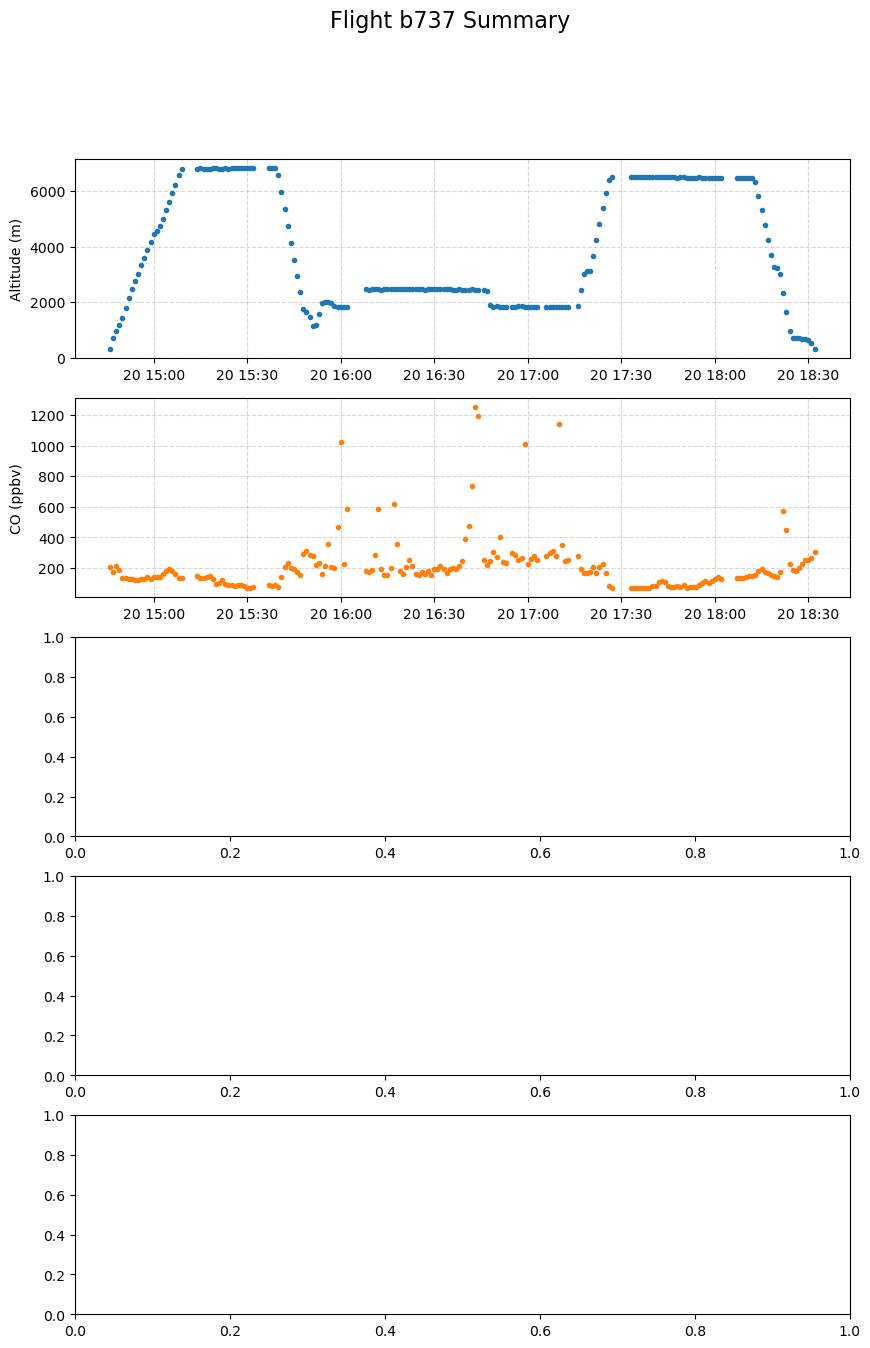

In [28]:
plot_flight_summary_and_regressions_v2(df_all_one_file,ds_core_cloud)

In [103]:
# Collect all datasets per flight
datasets = []

for entry in results_sct_all:
    try:
        # Extract PCASP data and channel/time information
        da_pcasp = entry["PCASP"]
        if isinstance(da_pcasp, xr.DataArray):
            pcasp_data = da_pcasp.values
            pcasp_channels = da_pcasp.coords.get("PCAS2CH", np.arange(da_pcasp.shape[0])).values
        else:
            pcasp_data = np.array(entry["PCASP"])
            pcasp_channels = np.arange(pcasp_data.shape[0])

        # --- Create dataset ---
        ds = xr.Dataset(
            {
                # Scalar/time-varying variables
                "TSC_blue": (["time"], np.atleast_1d(entry["TSC_blue"])),
                "TSC_green": (["time"], np.atleast_1d(entry["TSC_green"])),
                "TSC_red": (["time"], np.atleast_1d(entry["TSC_red"])),
                "BC": (["time"], np.atleast_1d(entry["BC"])),
                "ORG": (["time"], np.atleast_1d(entry["ORG"])),
                "SO4": (["time"], np.atleast_1d(entry["SO4"])),
                "NH4": (["time"], np.atleast_1d(entry["NH4"])),
                "NO3": (["time"], np.atleast_1d(entry["NO3"])),
                "AS": (["time"], np.atleast_1d(entry["AS"])),
                "AN": (["time"], np.atleast_1d(entry["AN"])),
                "DG": (["time"], np.atleast_1d(entry["DG_aligned"])),
                "ALT": (["time"], np.atleast_1d(entry["ALT"])),
                "LON": (["time"], np.atleast_1d(entry["LON"])),
                "LAT": (["time"], np.atleast_1d(entry["LAT"])),
                "CO": (["time"], np.atleast_1d(entry["CO"])),

                # 2D variable (channel × time)
                "PCASP": (["channel", "time"], pcasp_data),
            },
            coords={
                "time": entry["Time"],
                "channel": pcasp_channels,
                "flight": entry["flight"],
            },
            attrs={
                "flight_number": entry["flight"],
            }
        )

        datasets.append(ds)

    except Exception as e:
        print(f"⚠️ Skipping flight {entry['flight']} due to error: {e}")

# --- Combine all flights into one dataset
ds_all_flights = xr.concat(datasets, dim="flight")

In [104]:
print(ds_all_flights)

<xarray.Dataset> Size: 4MB
Dimensions:    (flight: 10, time: 1903, channel: 30)
Coordinates:
  * time       (time) datetime64[ns] 15kB 2012-09-18T12:41:00 ... 2012-10-03T...
  * channel    (channel) int64 240B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28 29
  * flight     (flight) <U4 160B 'b734' 'b737' 'b739' ... 'b746' 'b748' 'b749'
Data variables: (12/16)
    TSC_blue   (flight, time) float64 152kB 2.302e-06 2.285e-06 ... 5.807e-05
    TSC_green  (flight, time) float64 152kB 1.995e-06 1.661e-06 ... 4.083e-05
    TSC_red    (flight, time) float64 152kB 1.277e-06 1.126e-06 ... 2.677e-05
    BC         (flight, time) float64 152kB 0.03267 0.03136 ... 0.4279 0.6538
    ORG        (flight, time) float64 152kB 0.7897 1.233 1.314 ... 3.603 3.552
    SO4        (flight, time) float64 152kB 0.5045 0.4782 ... 0.4701 0.3915
    ...         ...
    DG         (flight, time) float64 152kB 0.2321 0.2366 0.2542 ... nan nan nan
    ALT        (flight, time) float32 76kB 7.798e+03 7.8e+03 ... 601.6 384.

In [105]:
def plot_flight_summary_and_regressions_xr(ds_all):
    """
    Plot for each flight:
      - Altitude vs. time
      - CO vs. time
      - CO/ORG vs. time
      - TSC_green vs. time
      - PCASP contour (channel vs. time)
      - Pie chart of average composition (SO4, NH4, NO3, ORG, BC)
    """
    flights = ds_all.flight.values

    for flight in flights:
        ds_flight = ds_all.sel(flight=flight)

        # Extract 1D arrays (ignoring NaNs)
        time = ds_flight.time.values
        ALT = ds_flight.ALT.values
        CO = ds_flight.CO.values
        ORG = ds_flight.ORG.values
        TSC_green = ds_flight.TSC_green.values

        # Composition means
        species = ['SO4', 'NH4', 'NO3', 'ORG', 'BC']
        avg_composition = [float(ds_flight[var].mean().values) for var in species]
        total_mass = np.nansum(avg_composition)
        percentages = 100 * np.array(avg_composition) / total_mass

        # --- Figure layout
        fig = plt.figure(figsize=(12, 16))
        gs = fig.add_gridspec(4, 1, height_ratios=[1, 1, 1, 1])
        fig.suptitle(f"Flight {flight} Summary", fontsize=16)

        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1])
        ax3 = fig.add_subplot(gs[2])
        ax4 = fig.add_subplot(gs[3])

        # --- Altitude
        ax1.plot(time, ALT, '.', color='tab:blue')
        ax1.set_ylabel("Altitude (m)")
        ax1.grid(True, linestyle='--', alpha=0.5)

        # --- CO
        ax2.plot(time, CO, '.', color='tab:orange')
        ax2.set_ylabel("CO (ppbv)")
        ax2.grid(True, linestyle='--', alpha=0.5)

        # --- CO/ORG
        ratio = np.divide(CO, ORG, out=np.full_like(CO, np.nan), where=ORG != 0)
        ax3.plot(time, ratio, '.', color='tab:red')
        ax3.set_ylabel("CO/ORG")
        ax3.grid(True, linestyle='--', alpha=0.5)

        # --- Scattering
        ax4.plot(time, TSC_green * 1e6, '.', color='tab:green')
        ax4.set_ylabel("TSC_green (Mm⁻¹)")
        ax4.grid(True, linestyle='--', alpha=0.5)


        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

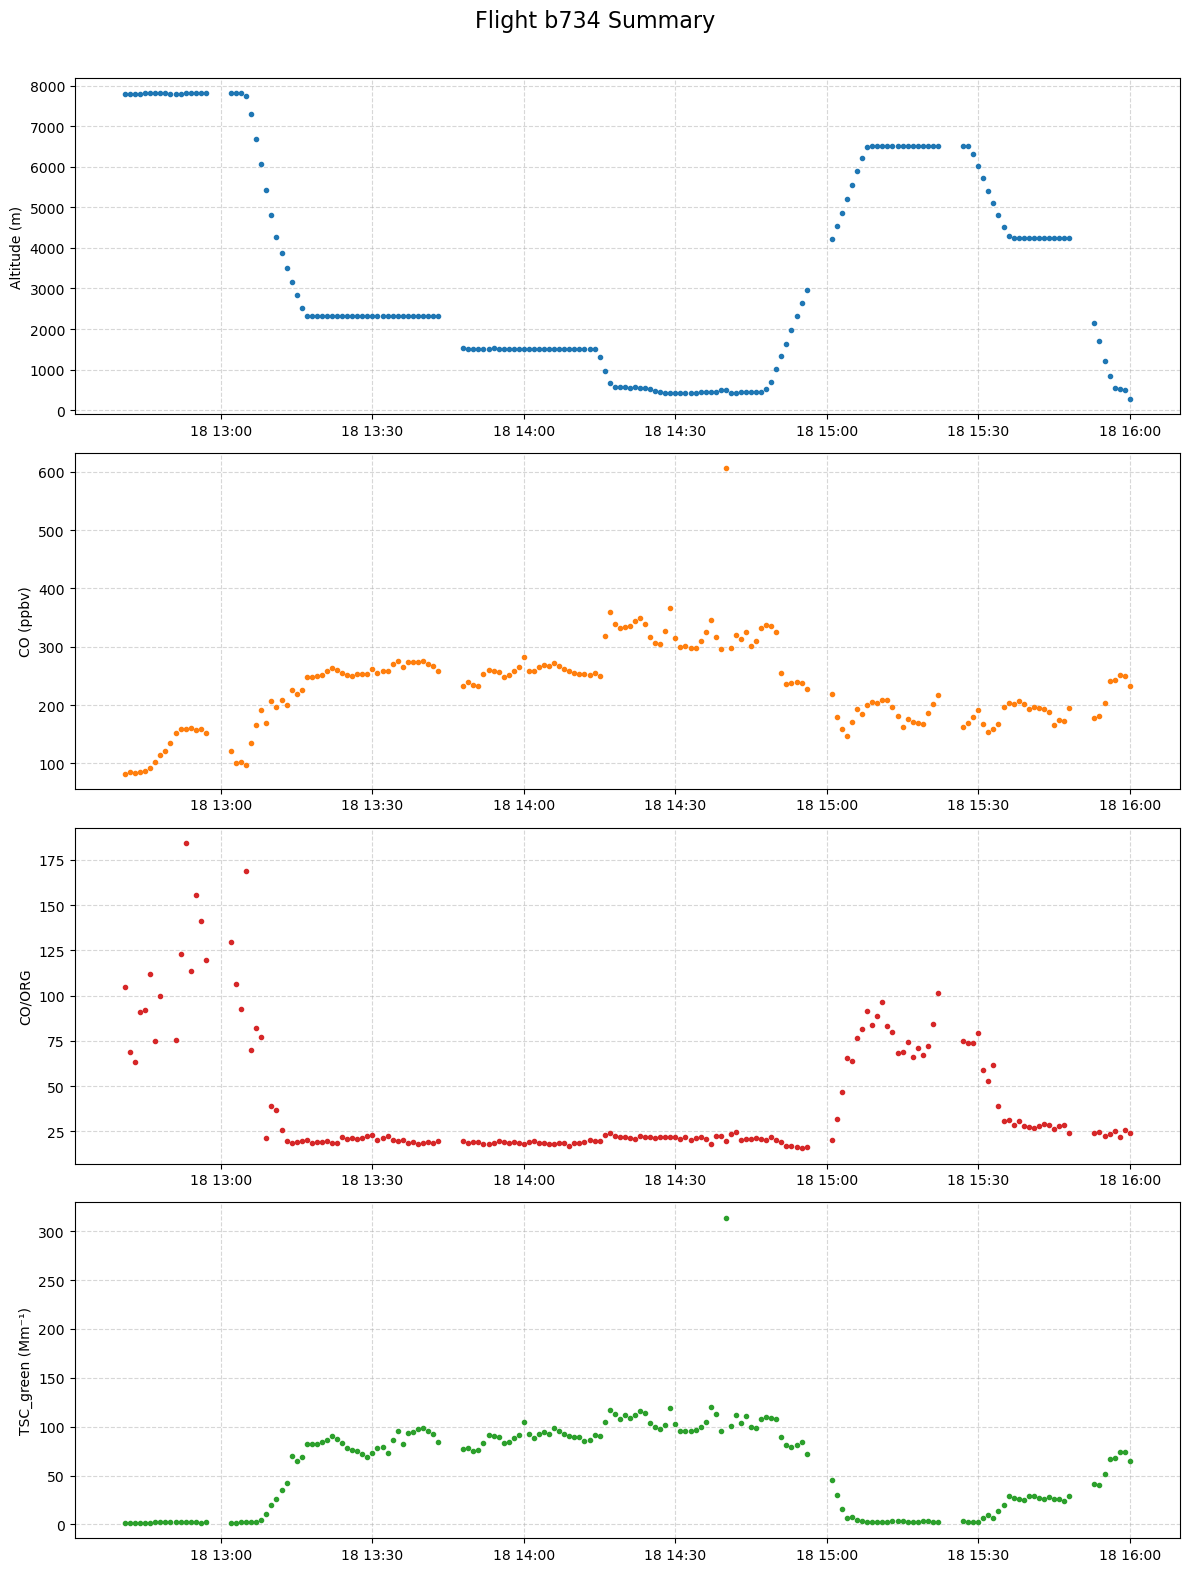

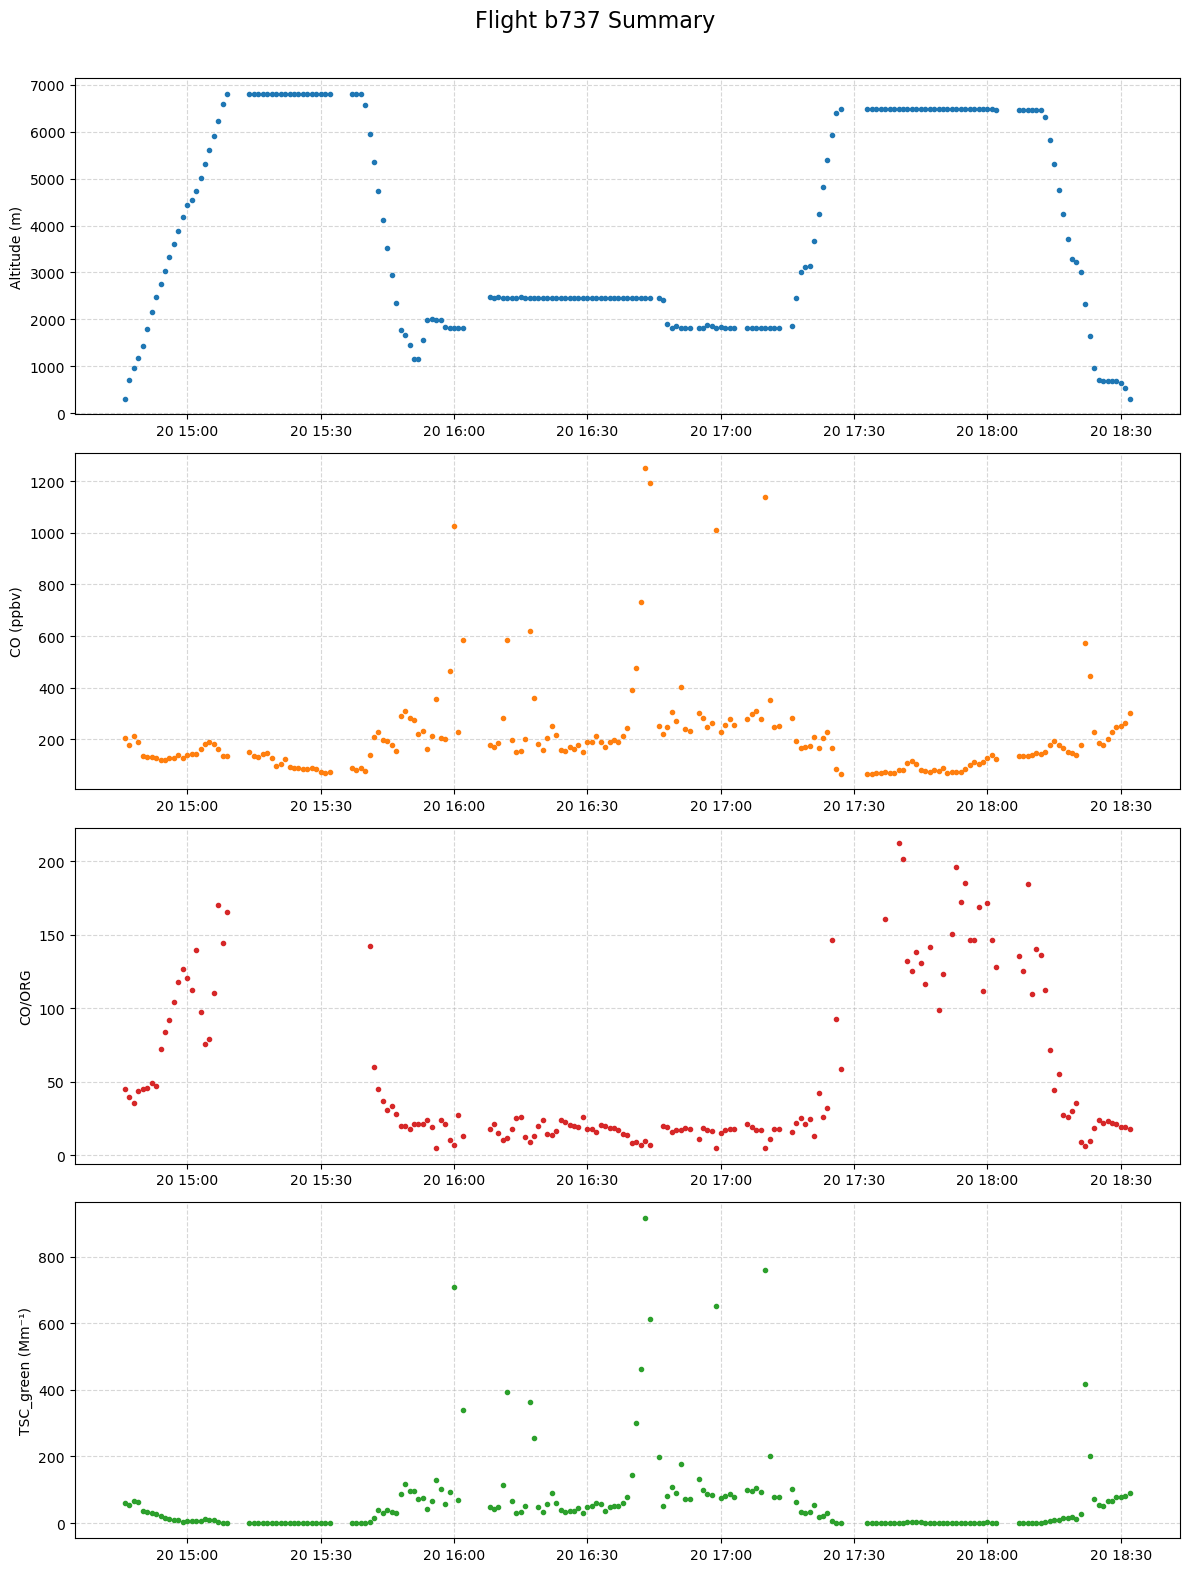

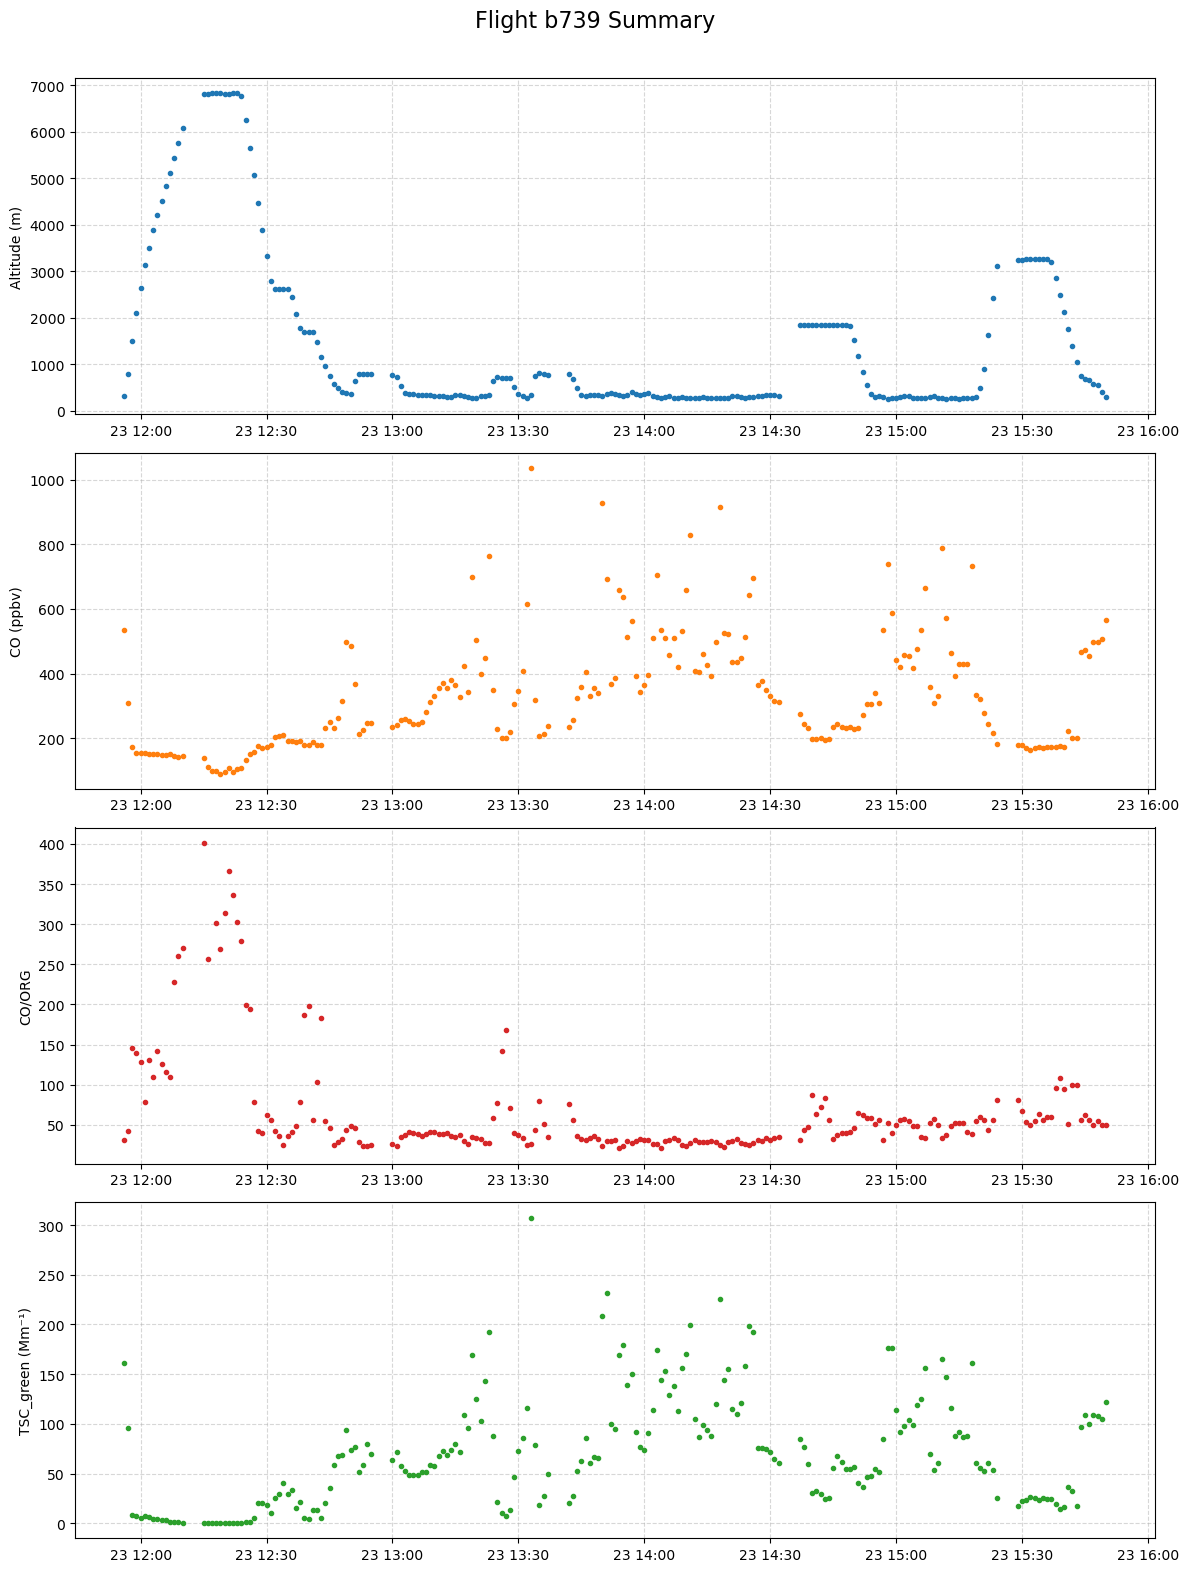

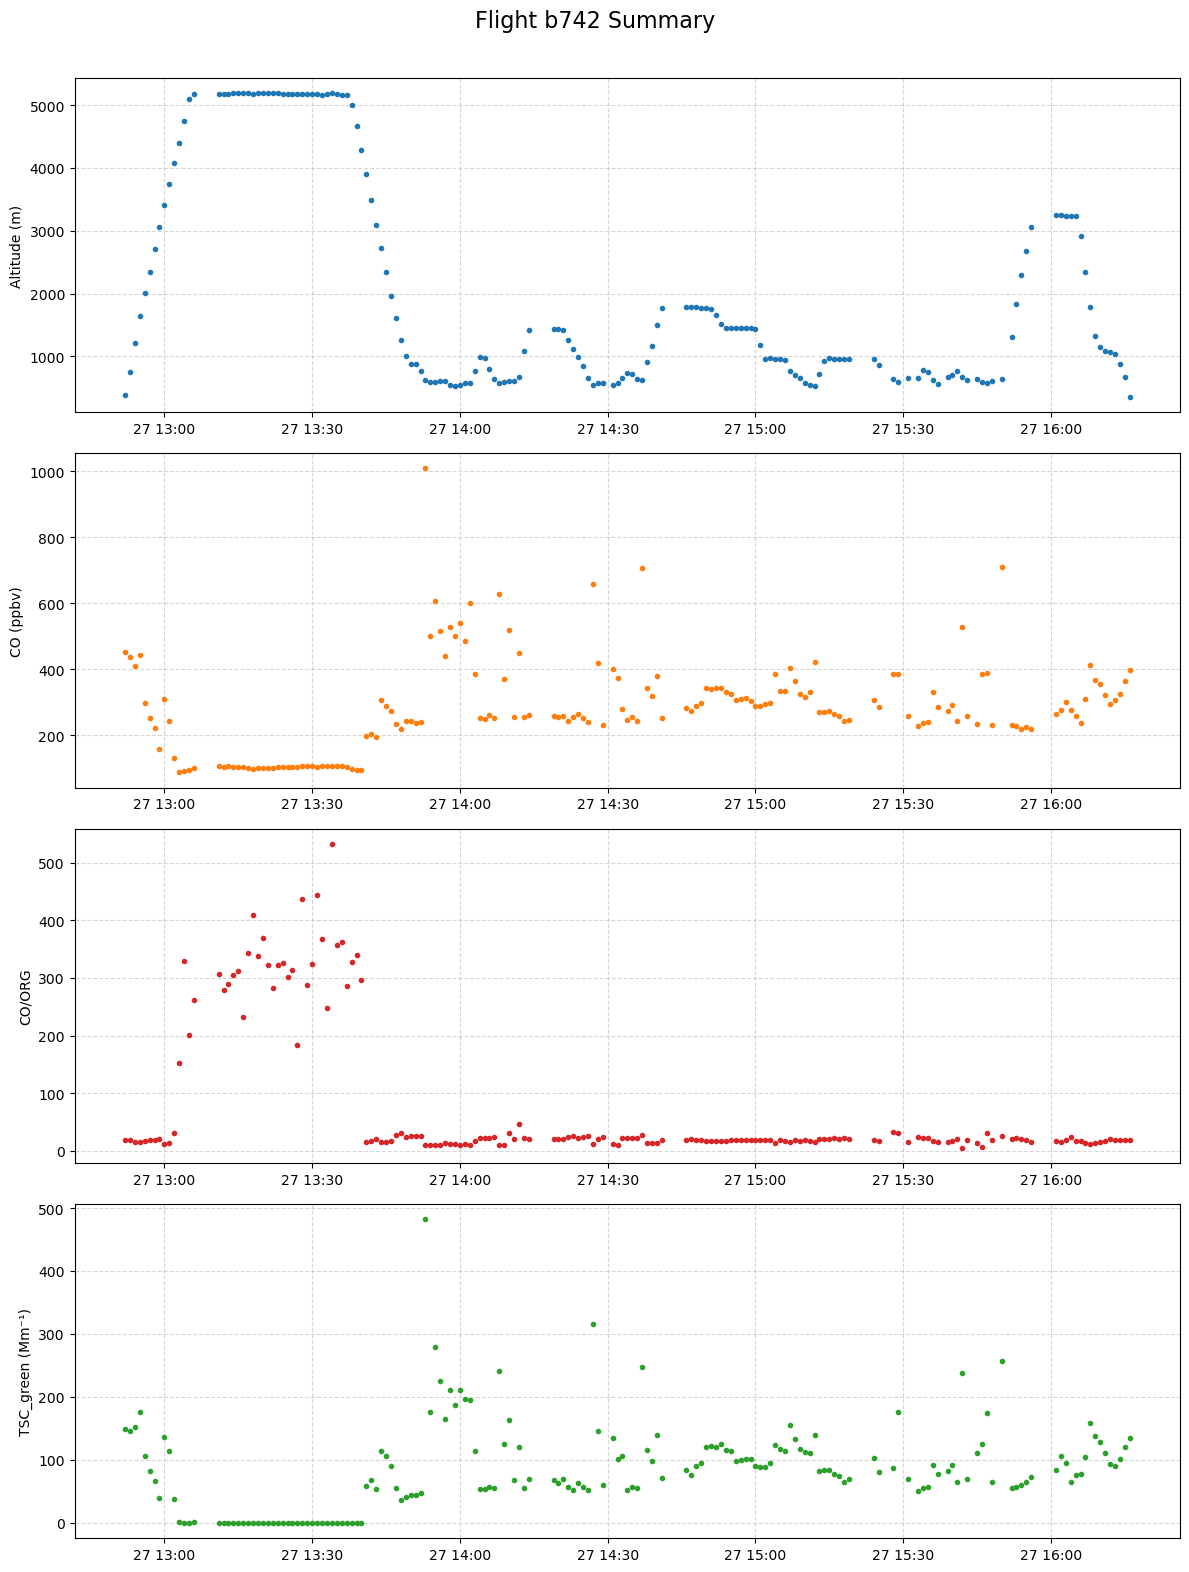

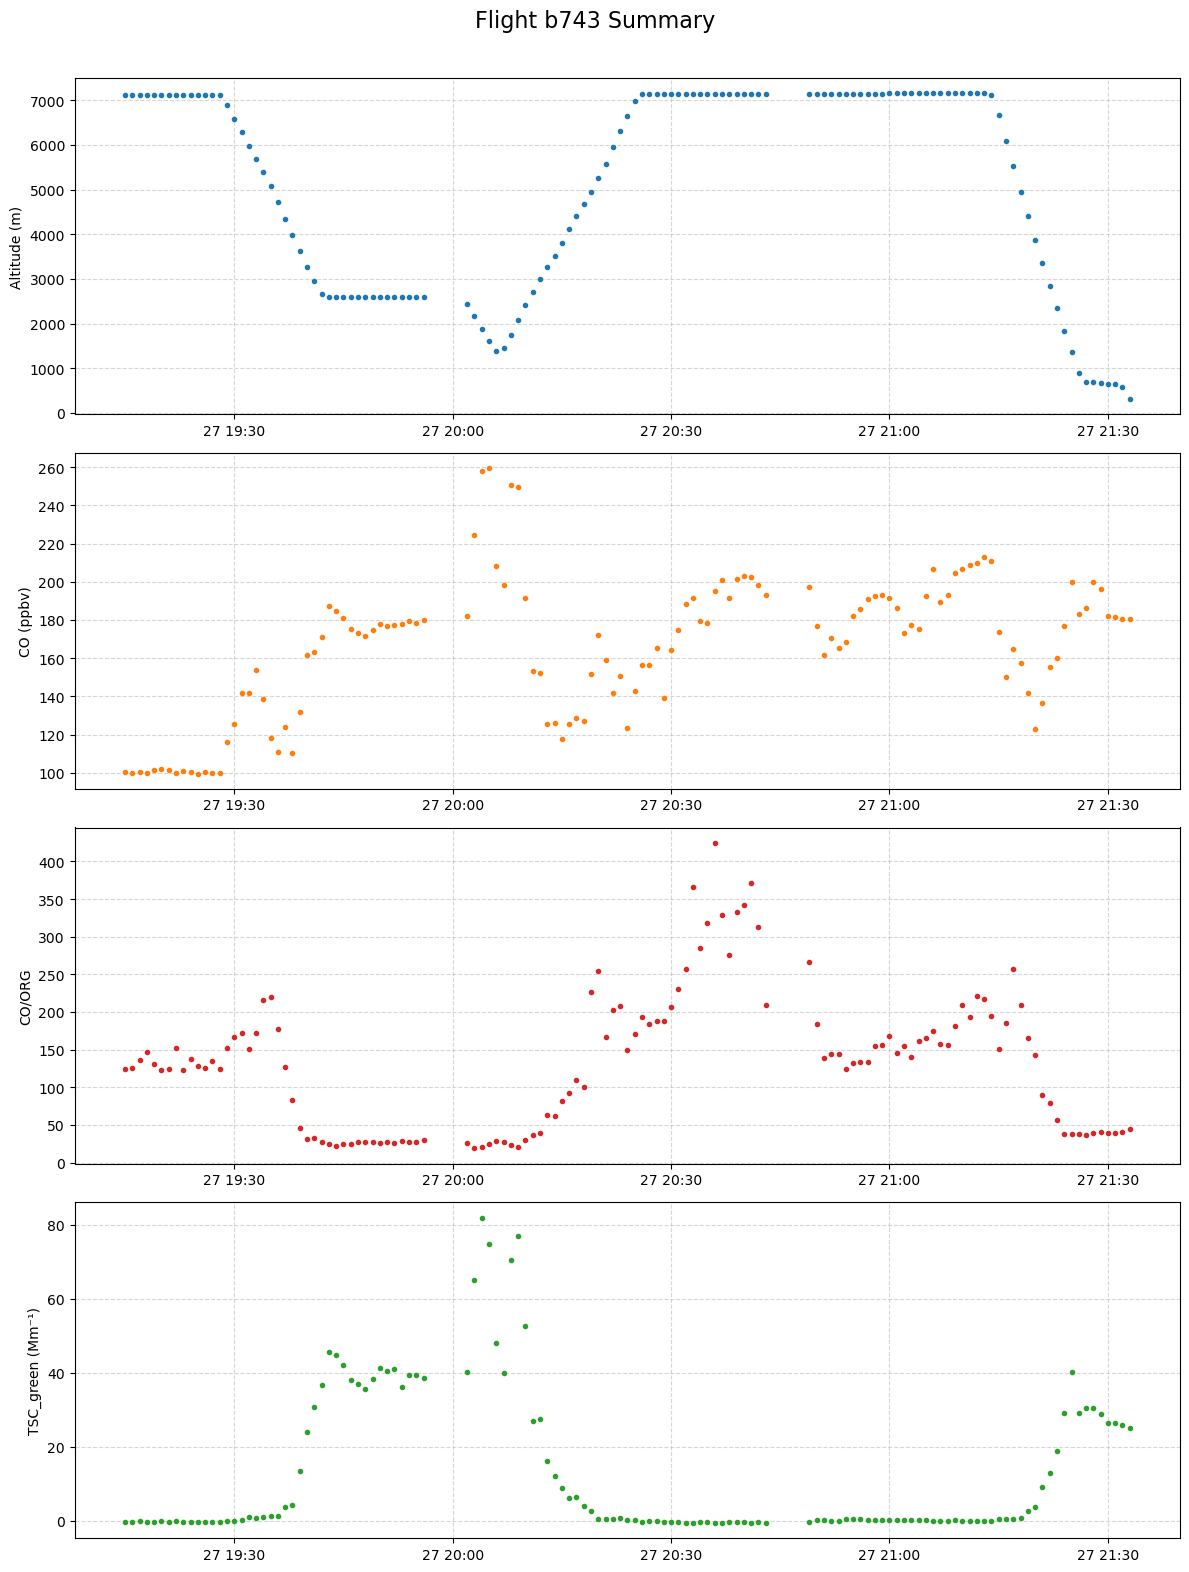

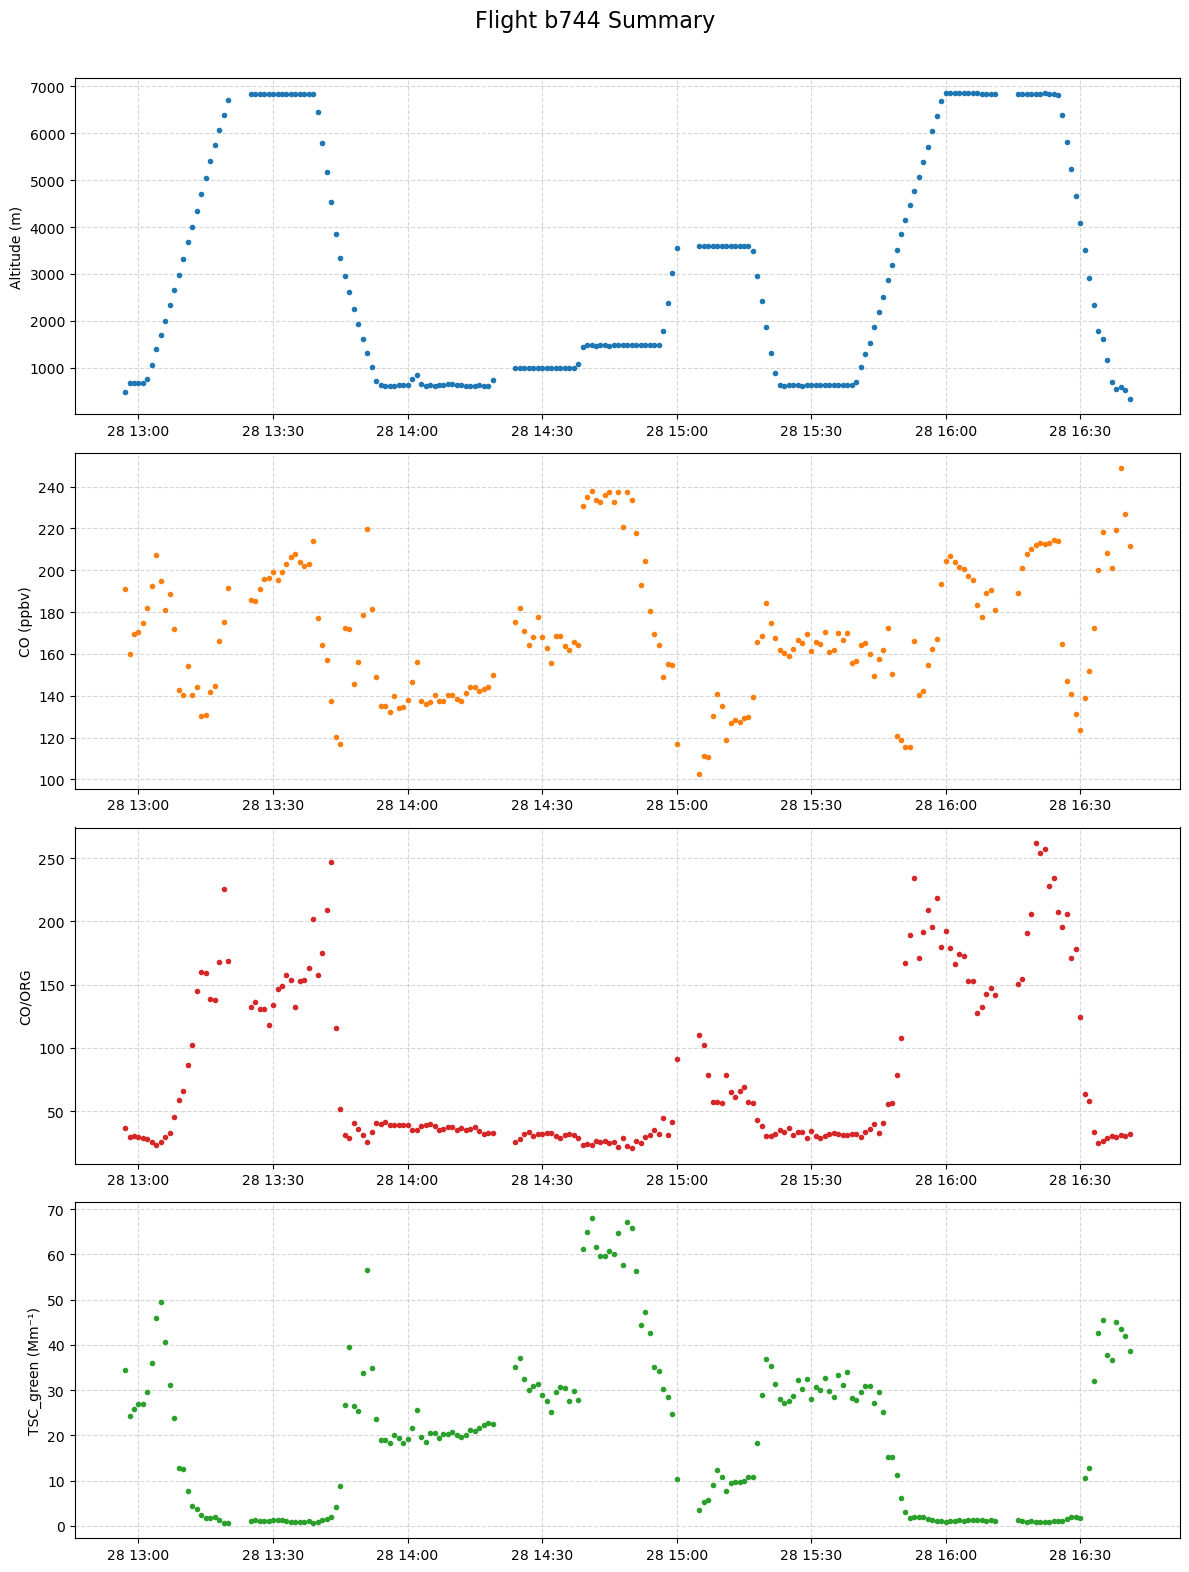

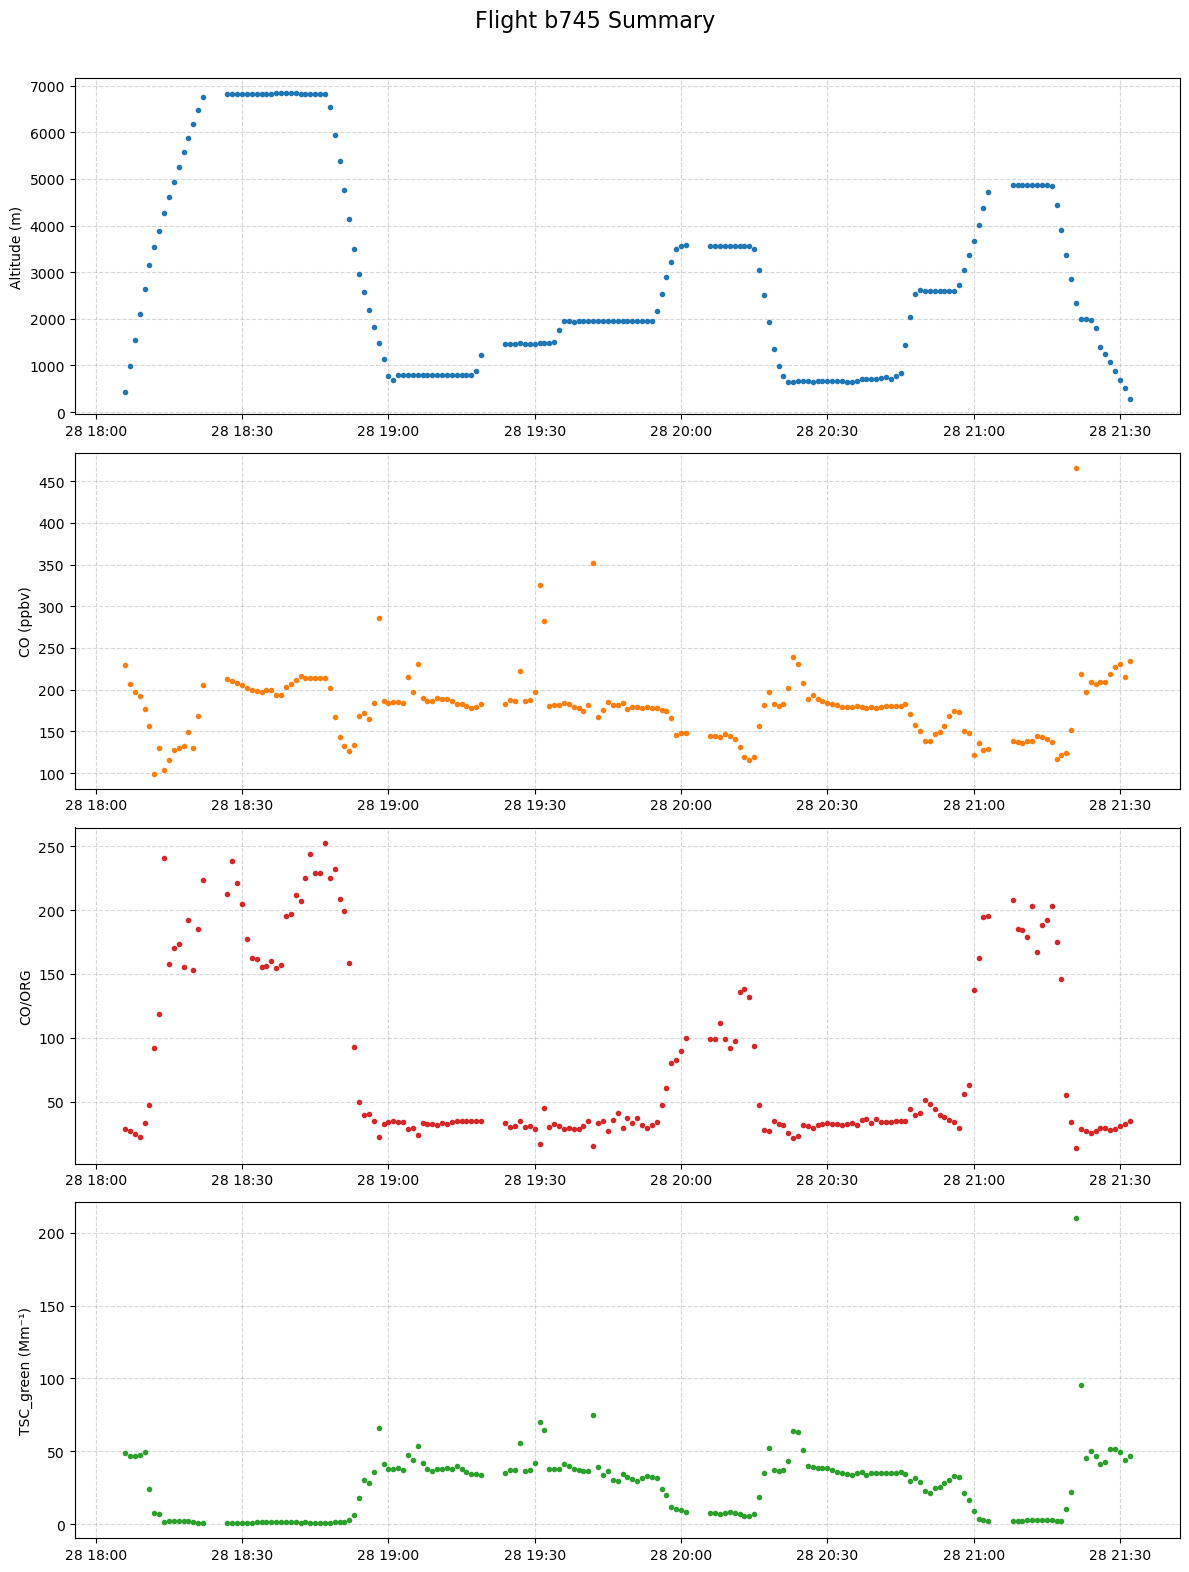

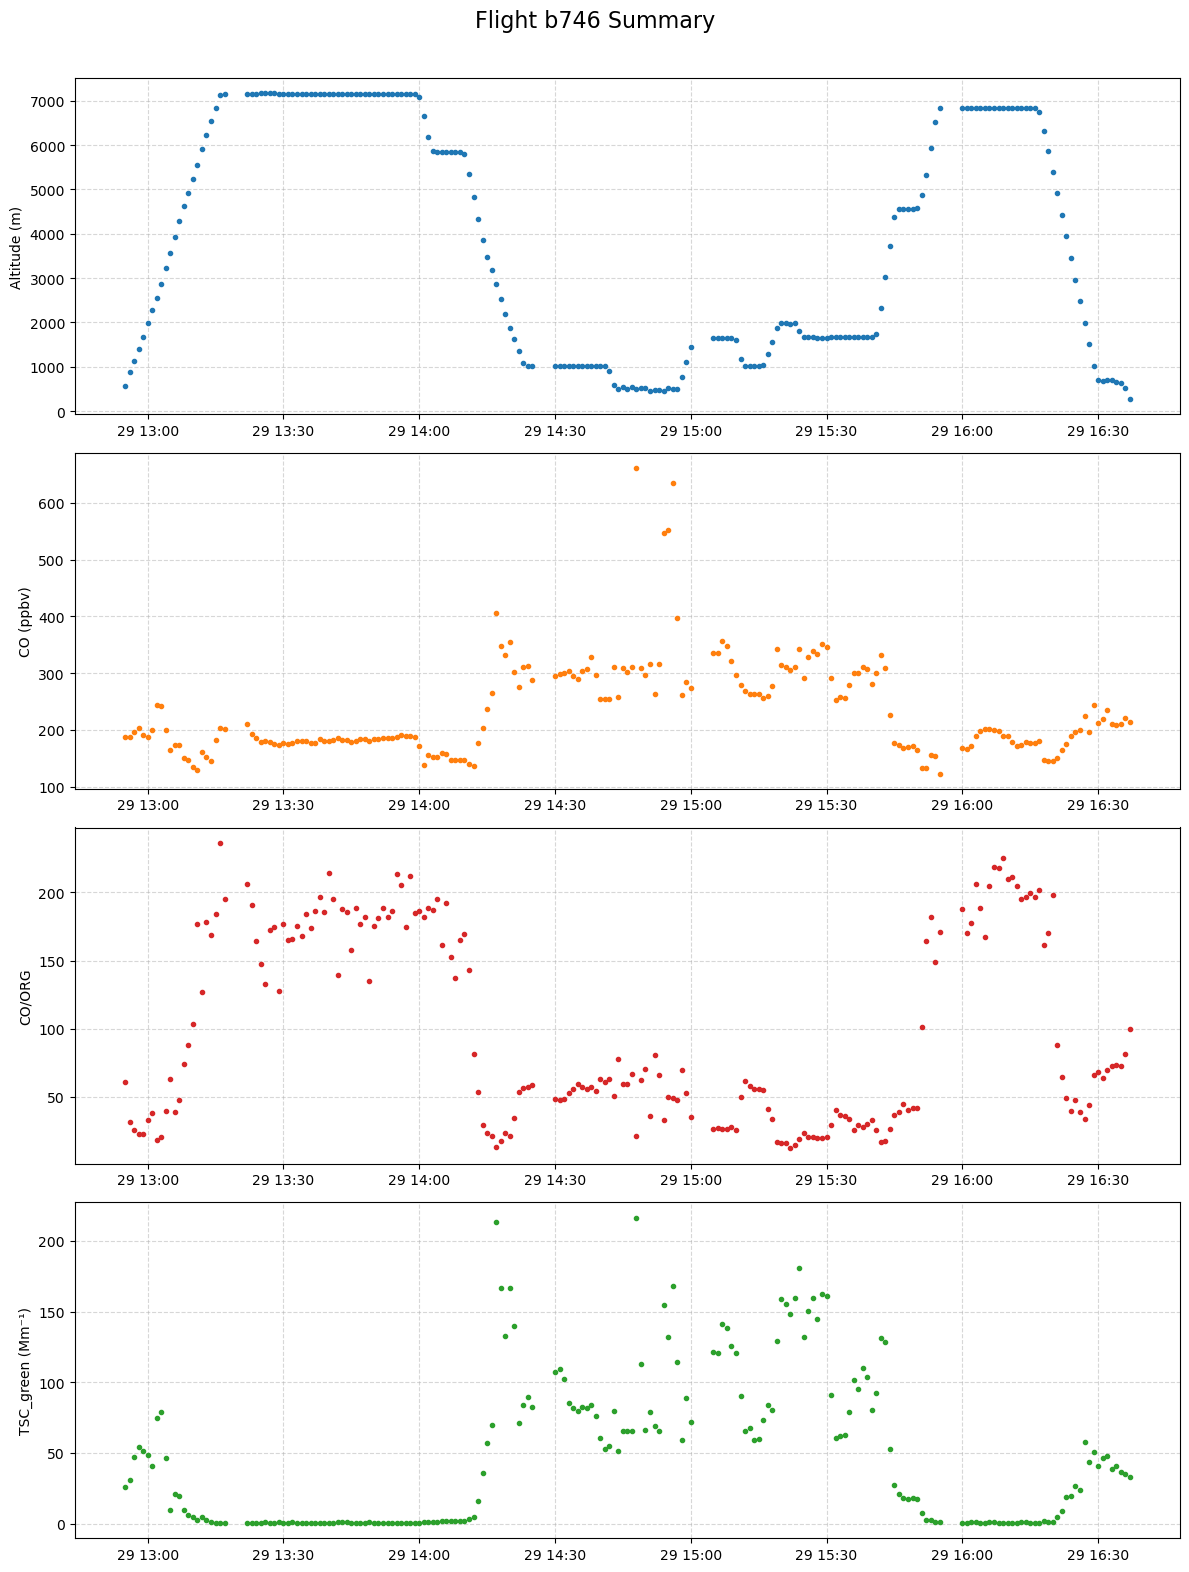

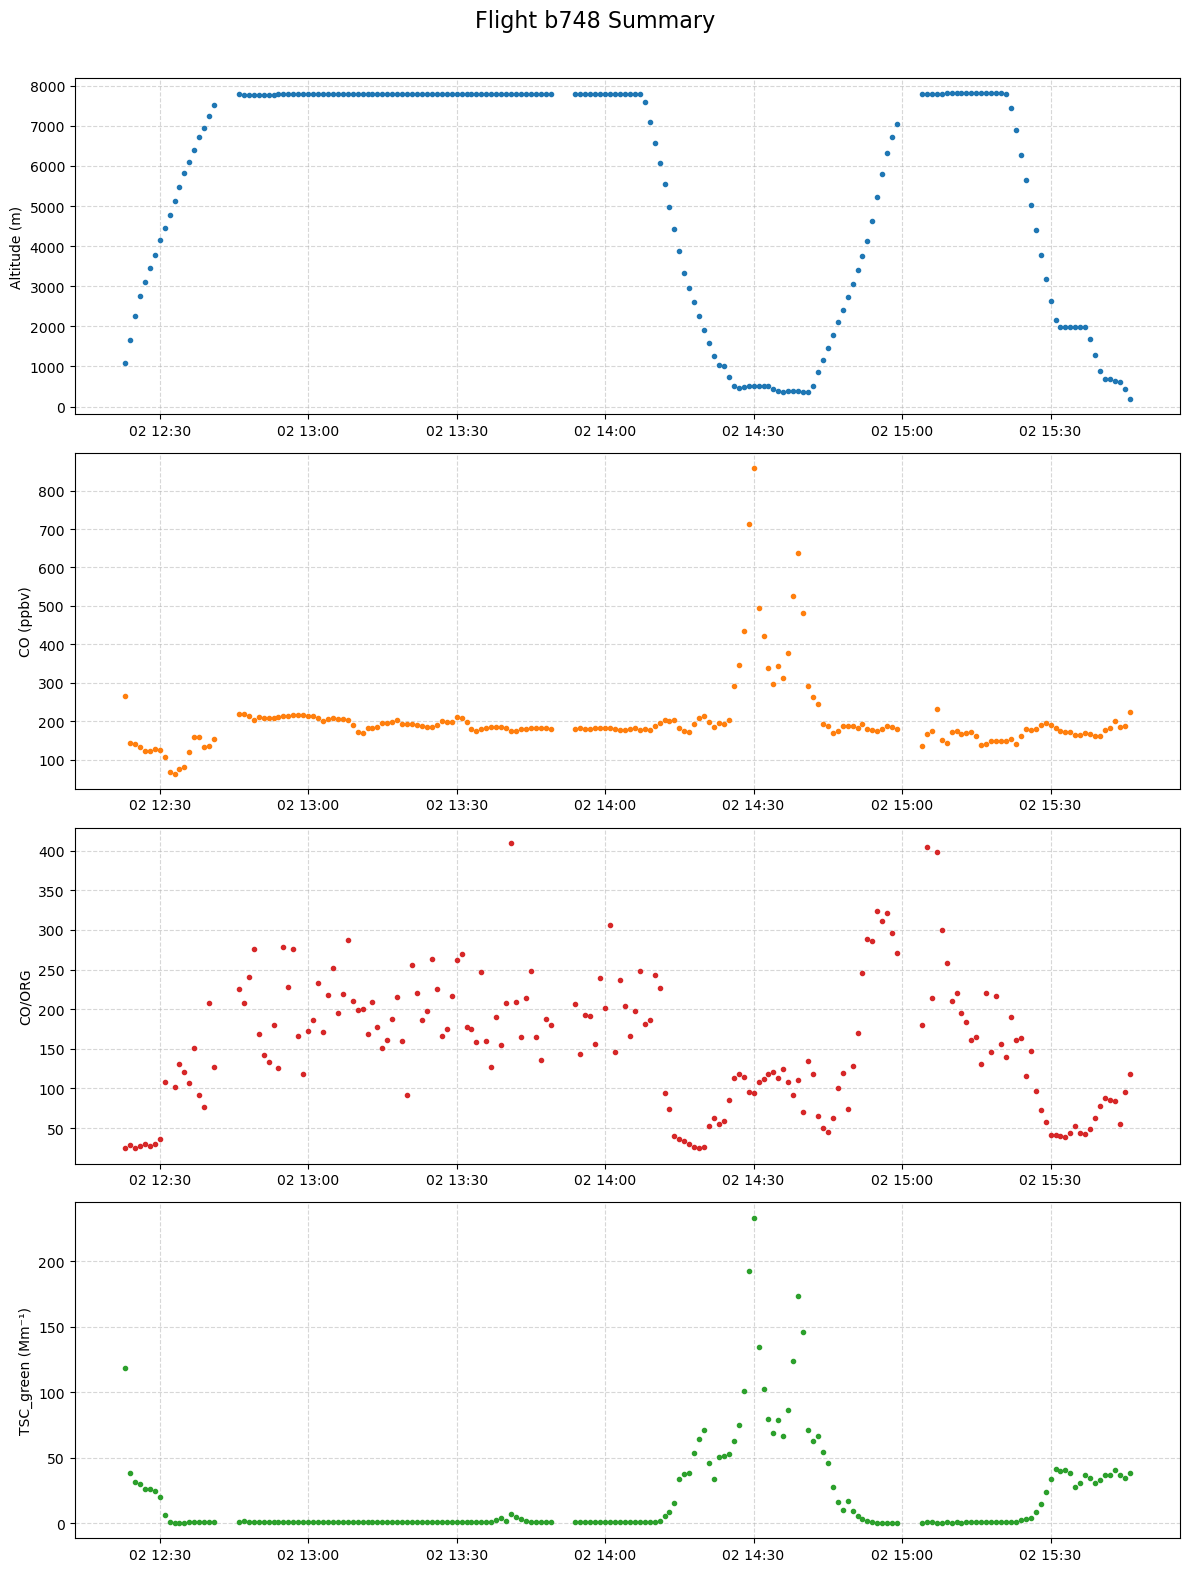

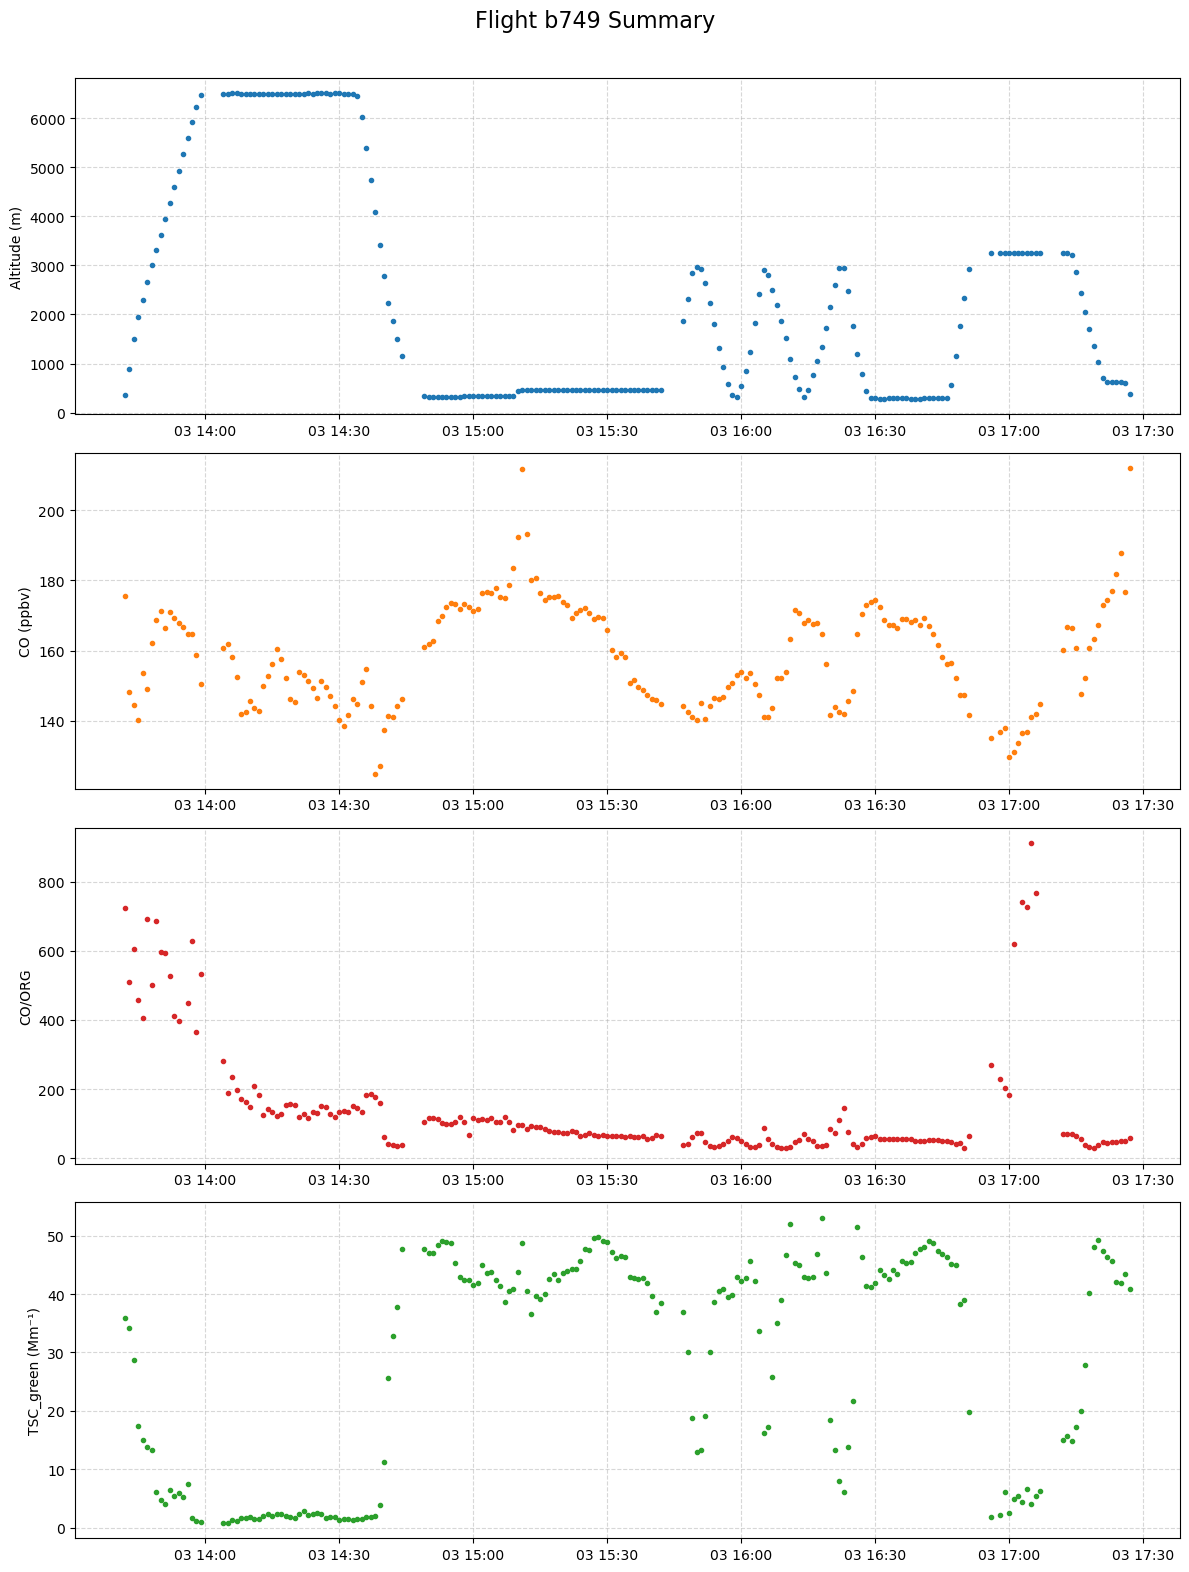

In [106]:
plot_flight_summary_and_regressions_xr(ds_all_flights)

In [107]:
def plot_flight_summary_and_regressions_xr_v2(ds_all):
    """
    Plot for each flight:
      - Altitude vs. time
      - CO vs. time
      - CO/ORG vs. time
      - TSC_green vs. time
      - PCASP contour (channel vs. time)
      - Pie chart of average composition (SO4, NH4, NO3, ORG, BC)
    """
    for flight in ds_all.flight.values:
        ds_f = ds_all.sel(flight=flight)

        time = ds_f.time.values
        ch   = ds_f.channel.values
        pcasp = ds_f.PCASP.values        # (channel, time)
        alt   = ds_f.ALT.values
        co    = ds_f.CO.values
        org   = ds_f.ORG.values
        tsc_g = ds_f.TSC_green.values

        species = ['SO4','NH4','NO3','ORG','BC']
        avg_comp = np.array([float(ds_f[v].mean()) for v in species])
        pct = 100*avg_comp/np.nansum(avg_comp)

        fig = plt.figure(figsize=(12,16))
        gs = fig.add_gridspec(6,1,height_ratios=[1,1,1,1,2,1])
        fig.suptitle(f"Flight {flight} Summary",fontsize=16)

        ax1 = fig.add_subplot(gs[0]); ax1.plot(time,alt,'.',color='tab:blue')
        ax1.set_ylabel('Altitude (m)'); ax1.grid(True,ls='--',alpha=0.5)

        ax2 = fig.add_subplot(gs[1]); ax2.plot(time,co,'.',color='tab:orange')
        ax2.set_ylabel('CO (ppbv)'); ax2.grid(True,ls='--',alpha=0.5)

        ratio = np.divide(co,org,out=np.full_like(co,np.nan),where=org!=0)
        ax3 = fig.add_subplot(gs[2]); ax3.plot(time,ratio,'.',color='tab:red')
        ax3.set_ylabel('CO/ORG'); ax3.grid(True,ls='--',alpha=0.5)

        ax4 = fig.add_subplot(gs[3]); ax4.plot(time,tsc_g*1e6,'.',color='tab:green')
        ax4.set_ylabel('TSC_green (Mm⁻¹)'); ax4.grid(True,ls='--',alpha=0.5)

        ax5 = fig.add_subplot(gs[4])
        pcm = ax5.contourf(time,ch,pcasp,levels=50,cmap='viridis')
        fig.colorbar(pcm,ax=ax5,label='PCASP (counts)')
        ax5.set_ylabel('Channel'); ax5.set_xlabel('Time')
        ax5.set_title('PCASP Size Distribution')

        ax6 = fig.add_subplot(gs[5])
        ax6.pie(avg_comp,labels=species,autopct=lambda p:f"{p:.1f}%",startangle=140,
                textprops={'color':"w"})
        ax6.set_title('Mean Composition')
        ax6.legend([f"{s}: {p:.1f}%" for s,p in zip(species,pct)],
                   loc='center left',bbox_to_anchor=(1,0.5))

        plt.tight_layout(rect=[0,0,1,0.97])
        plt.show()

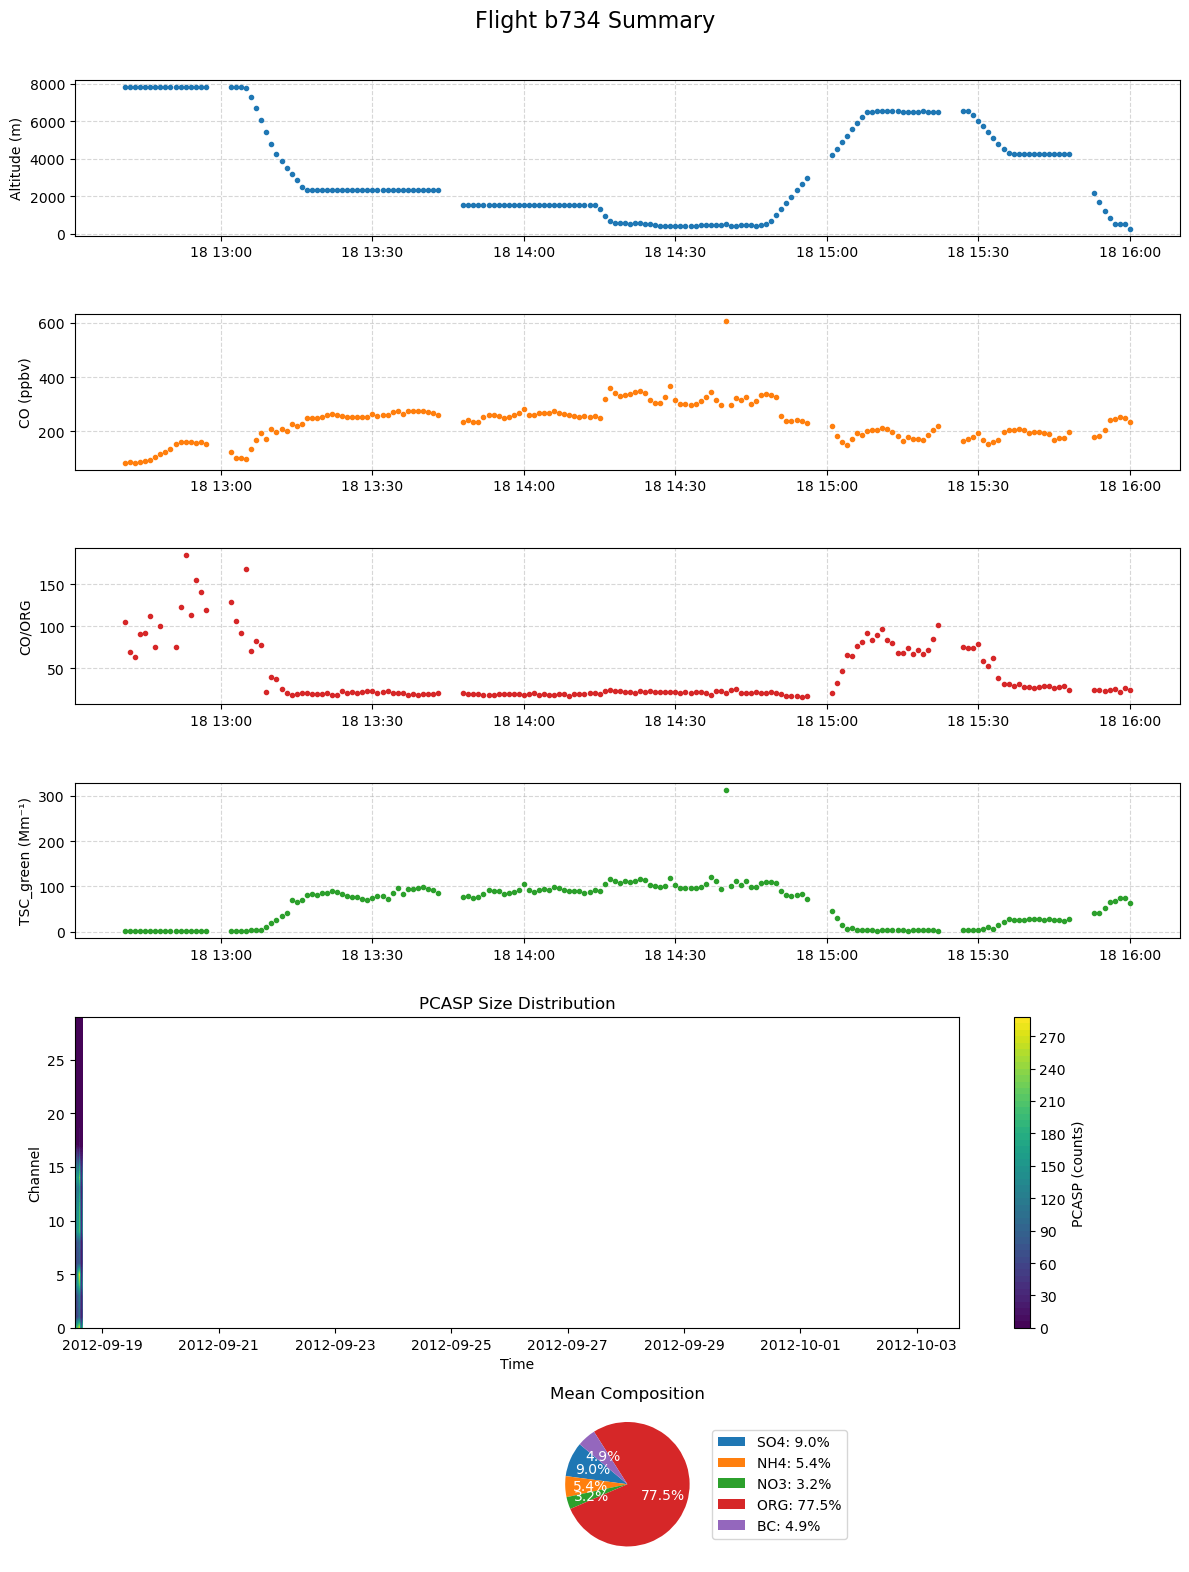

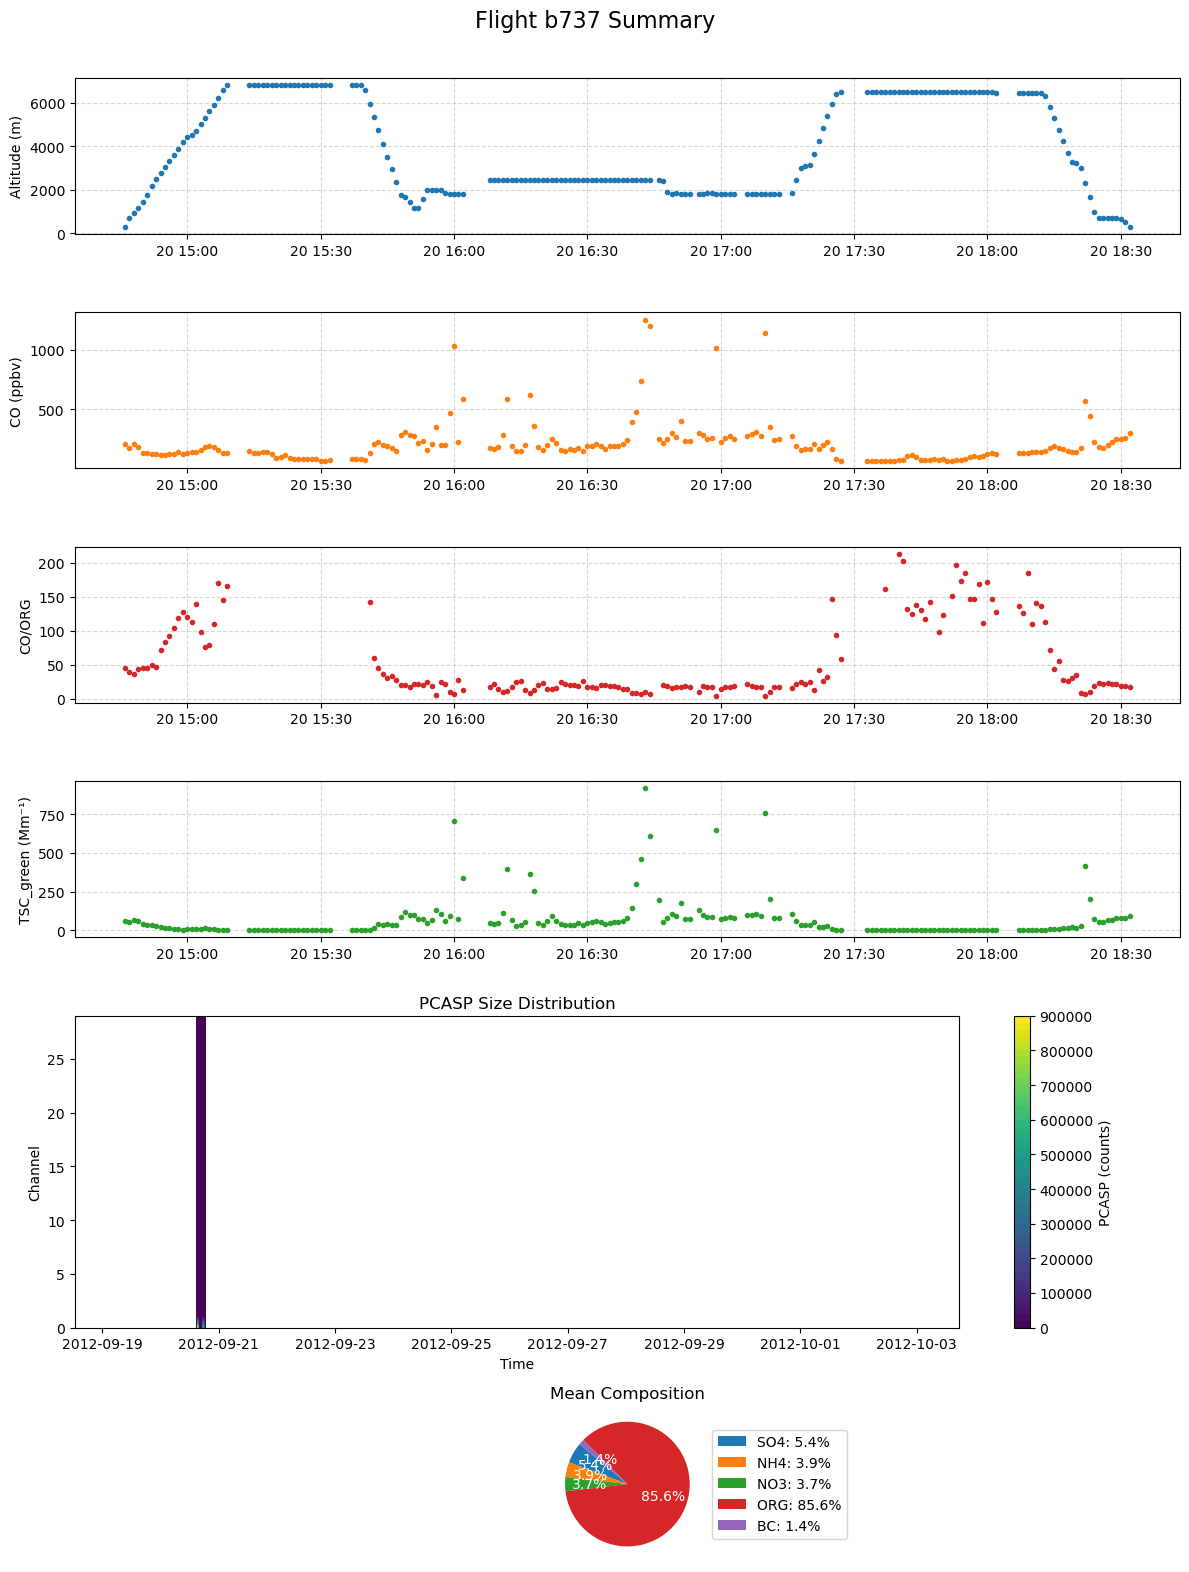

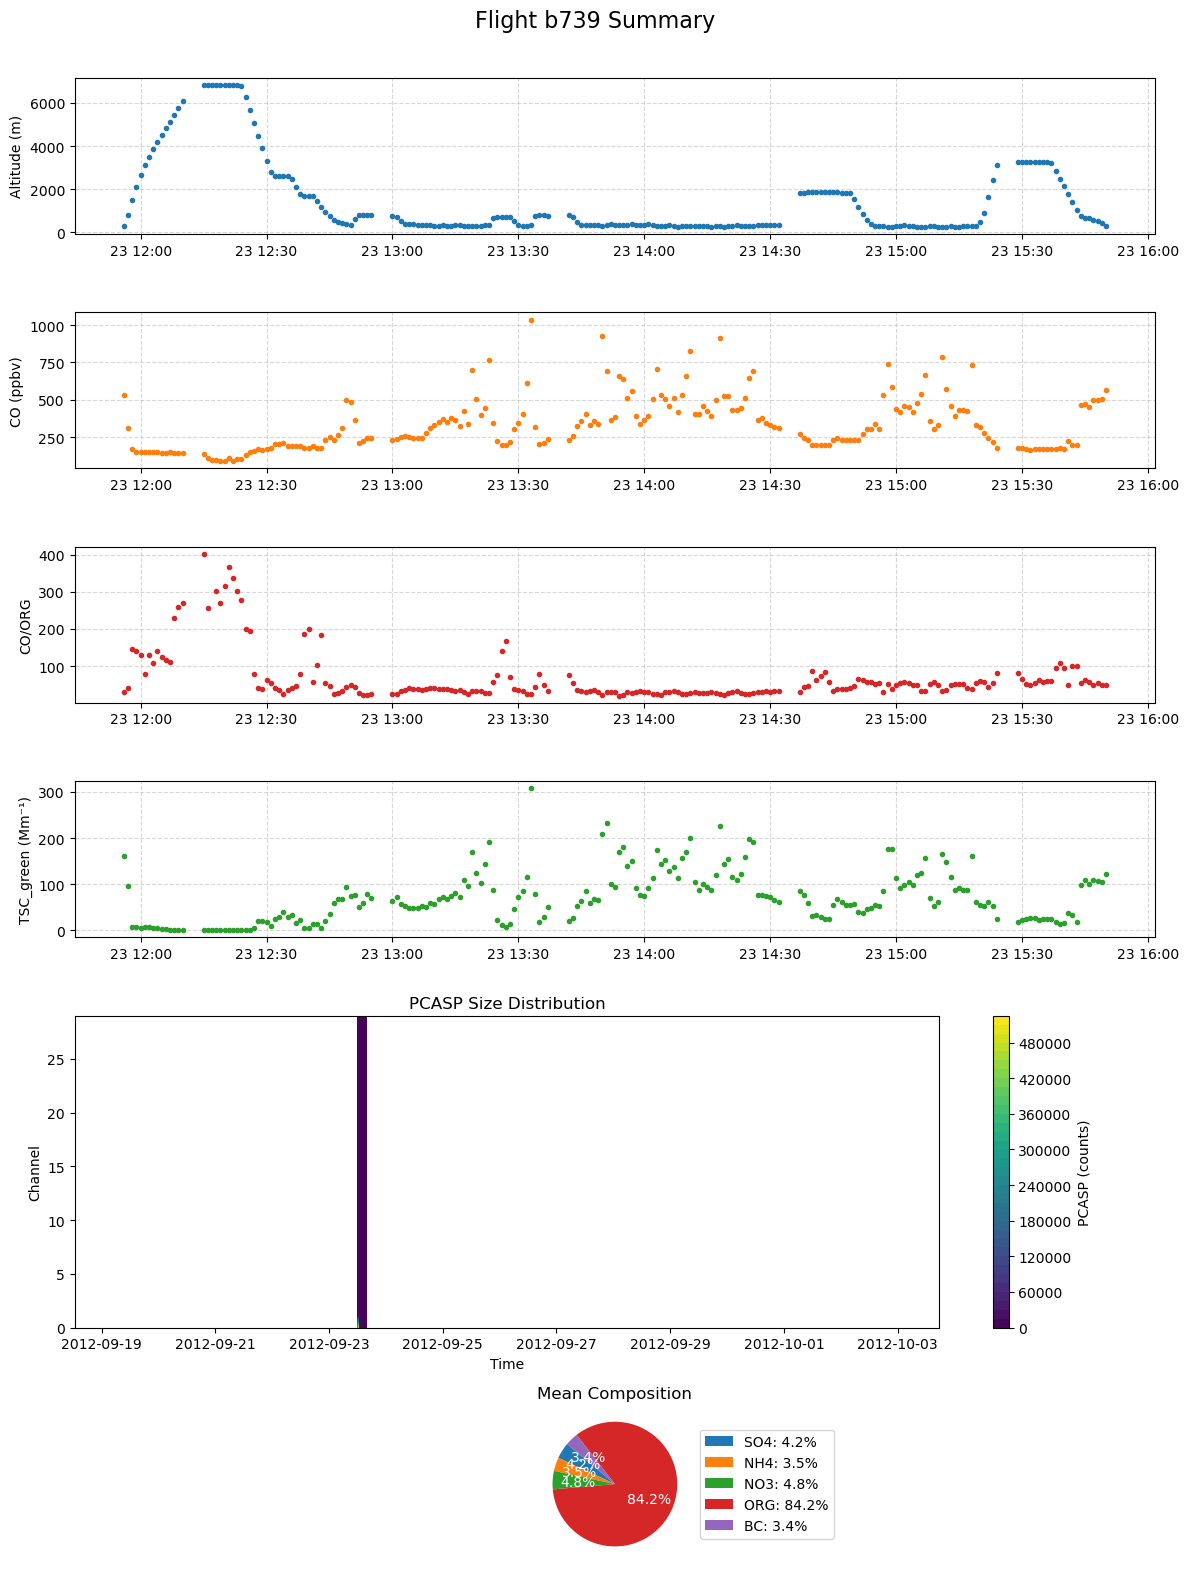

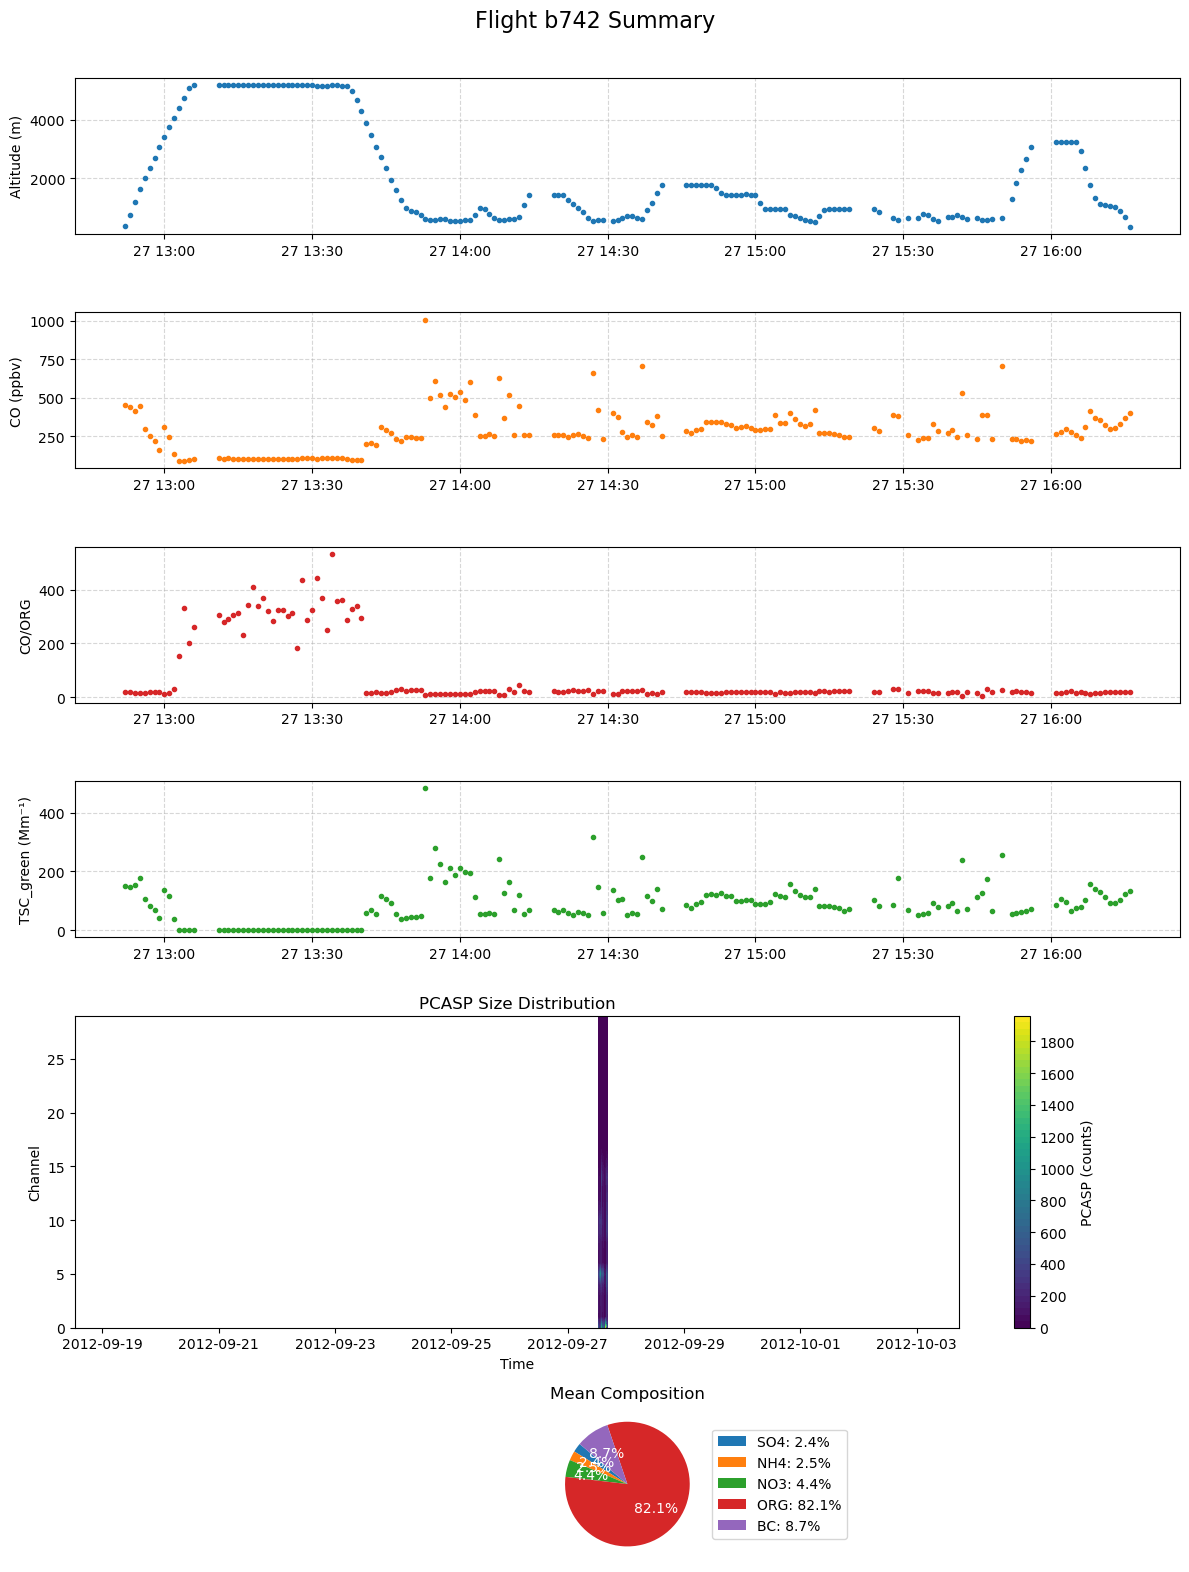

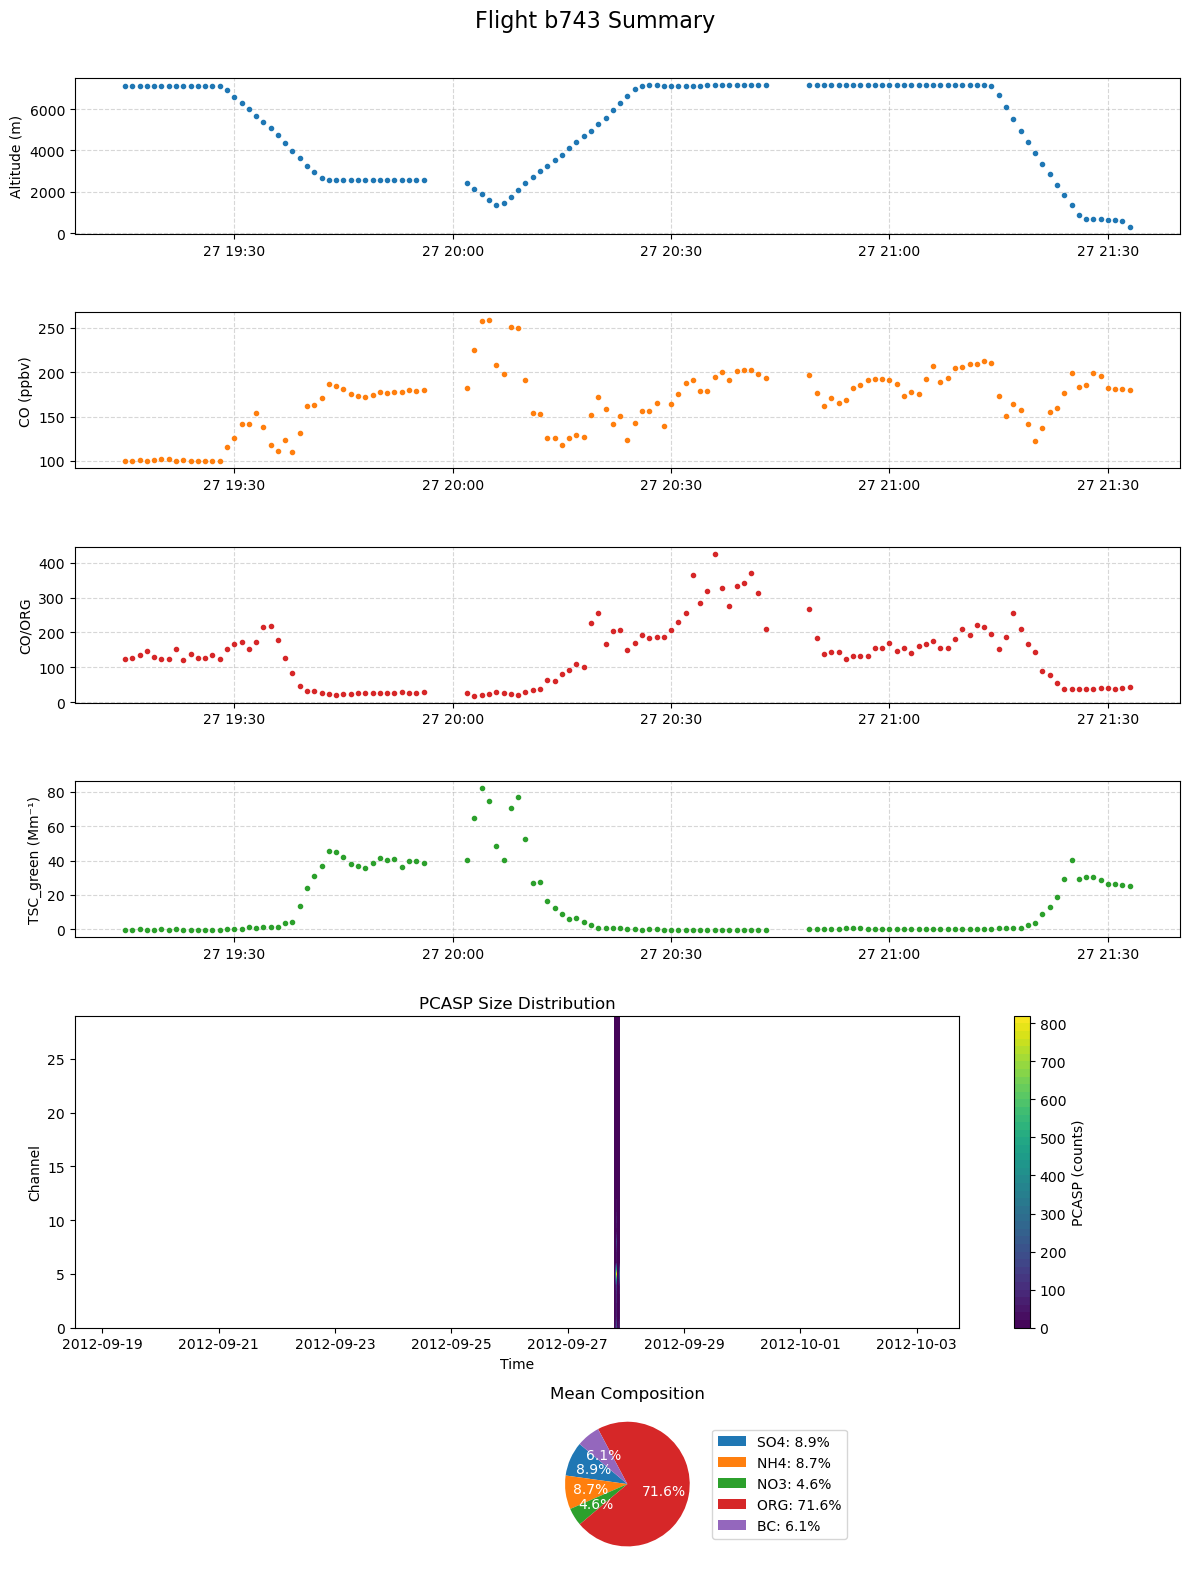

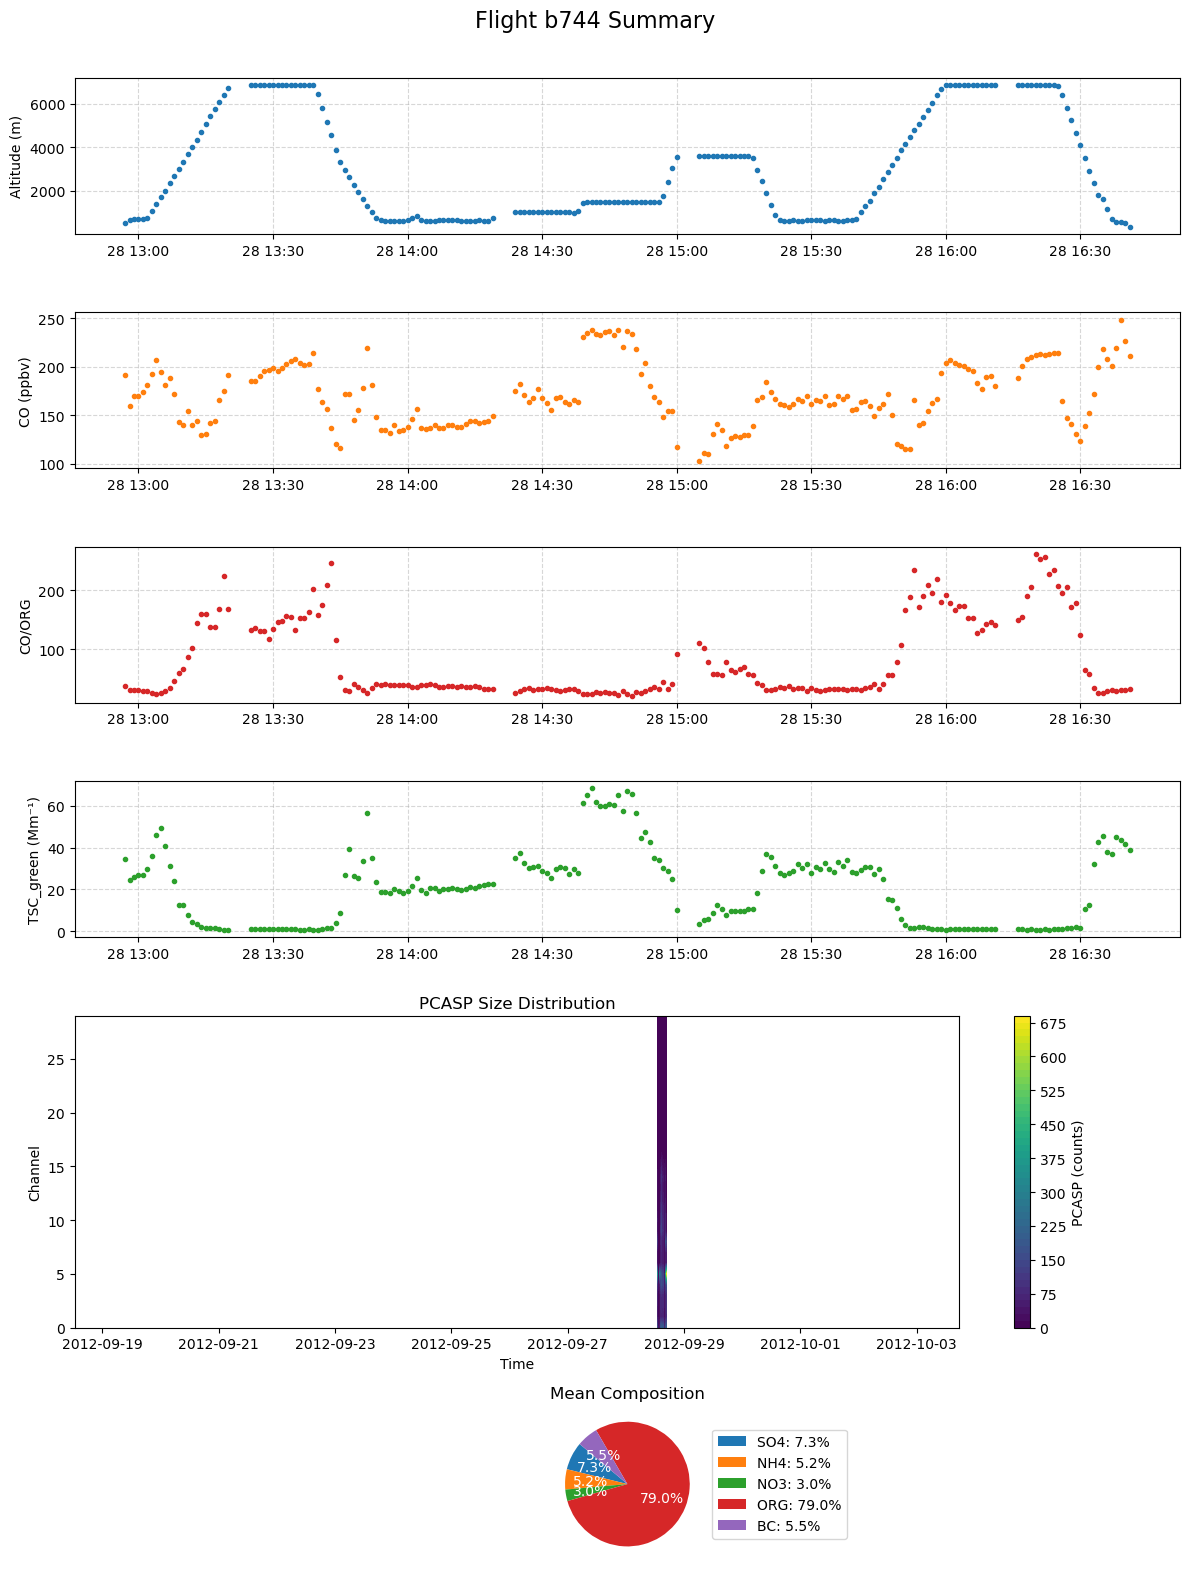

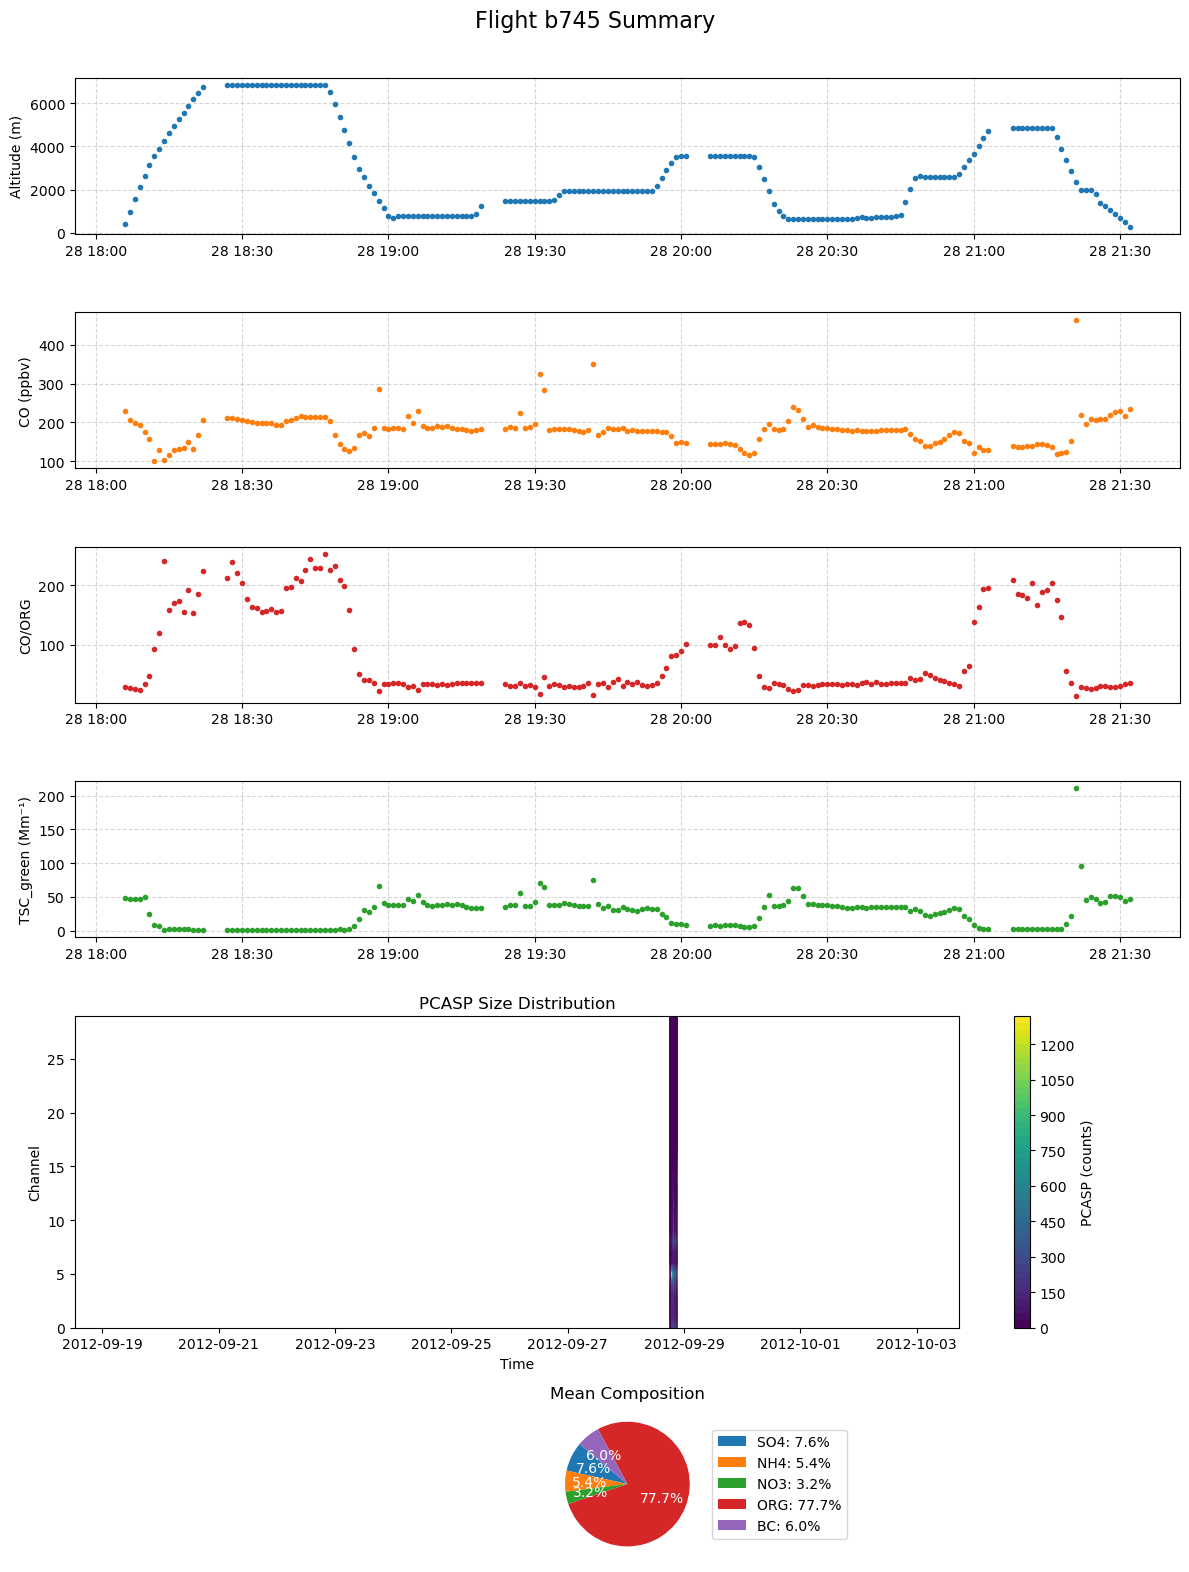

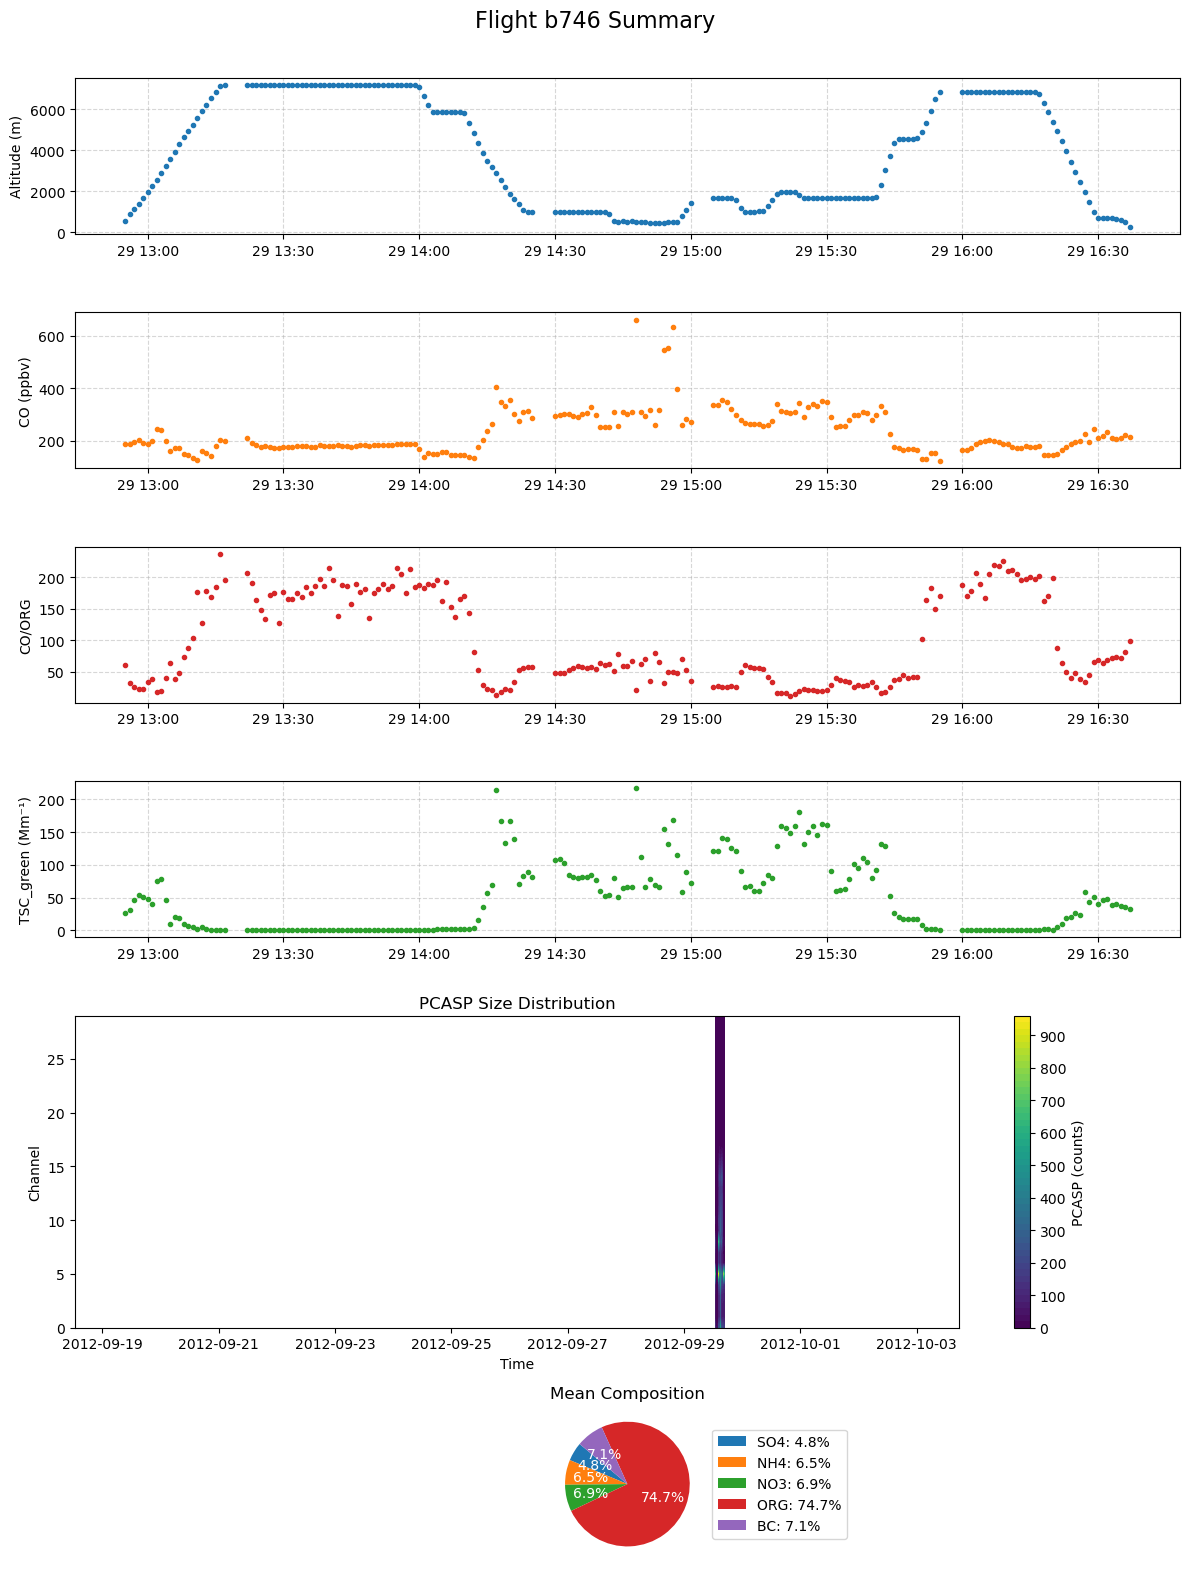

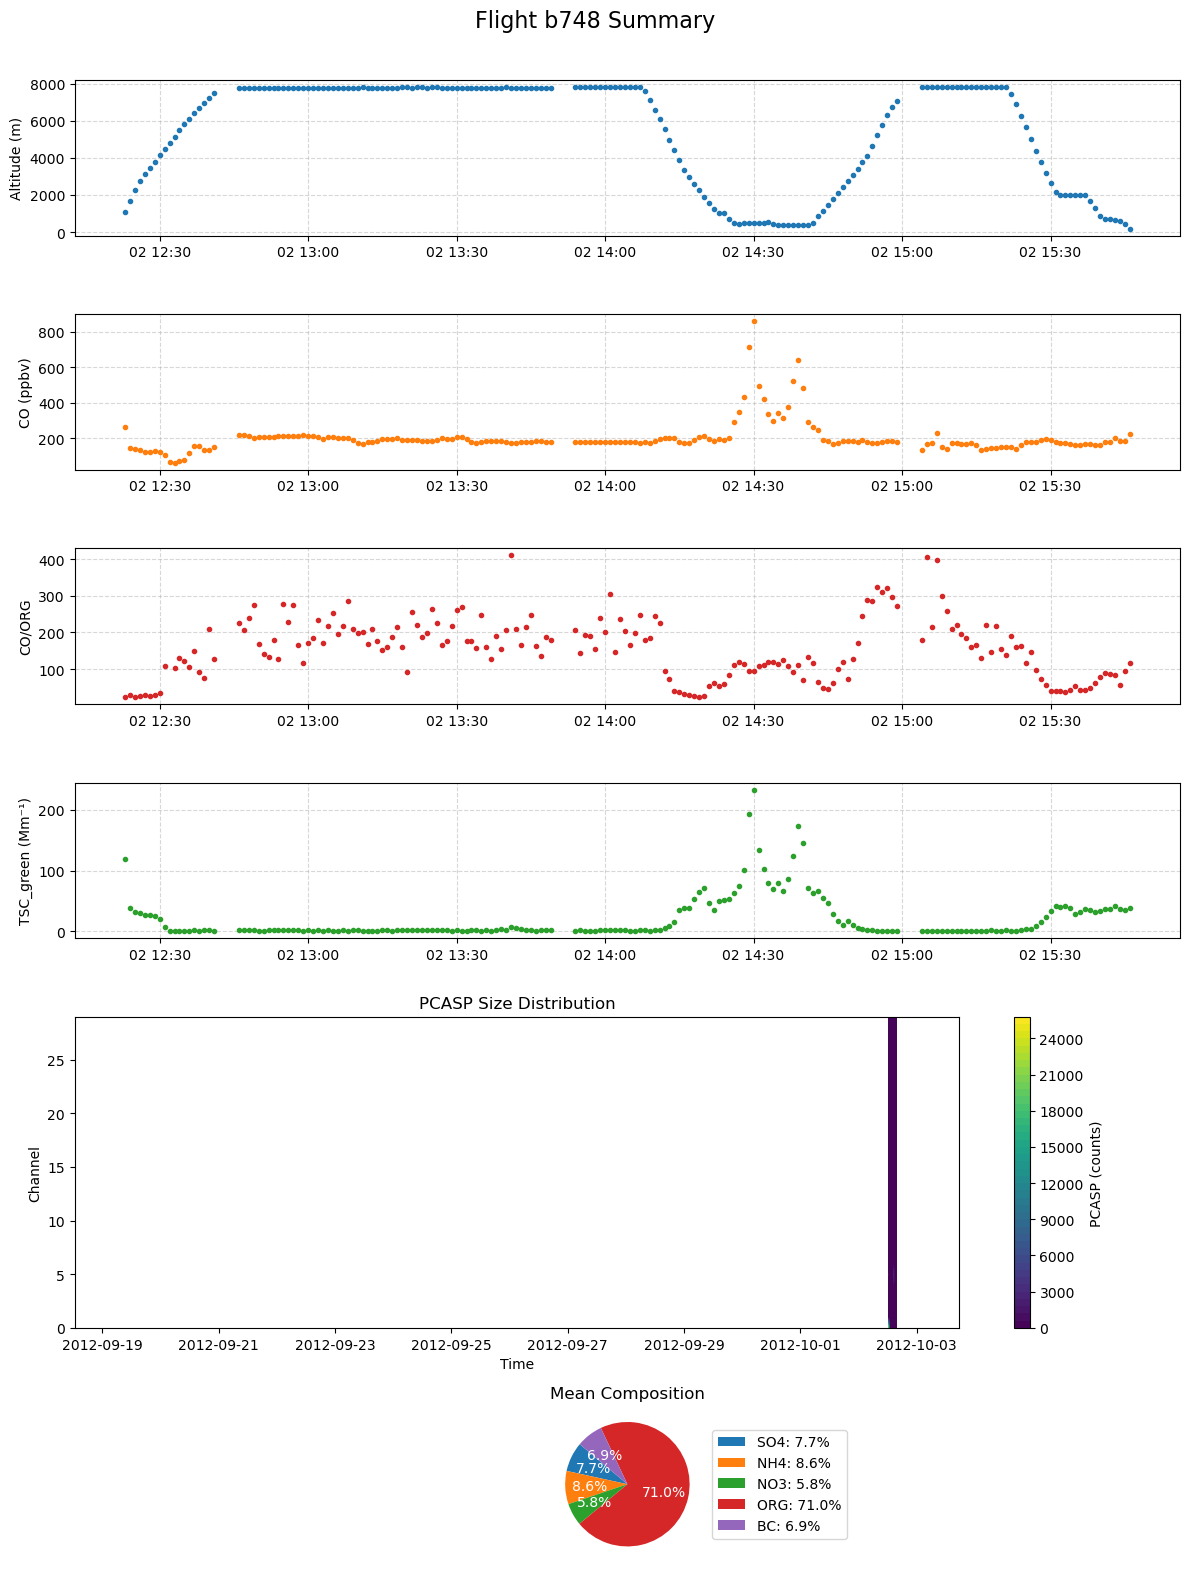

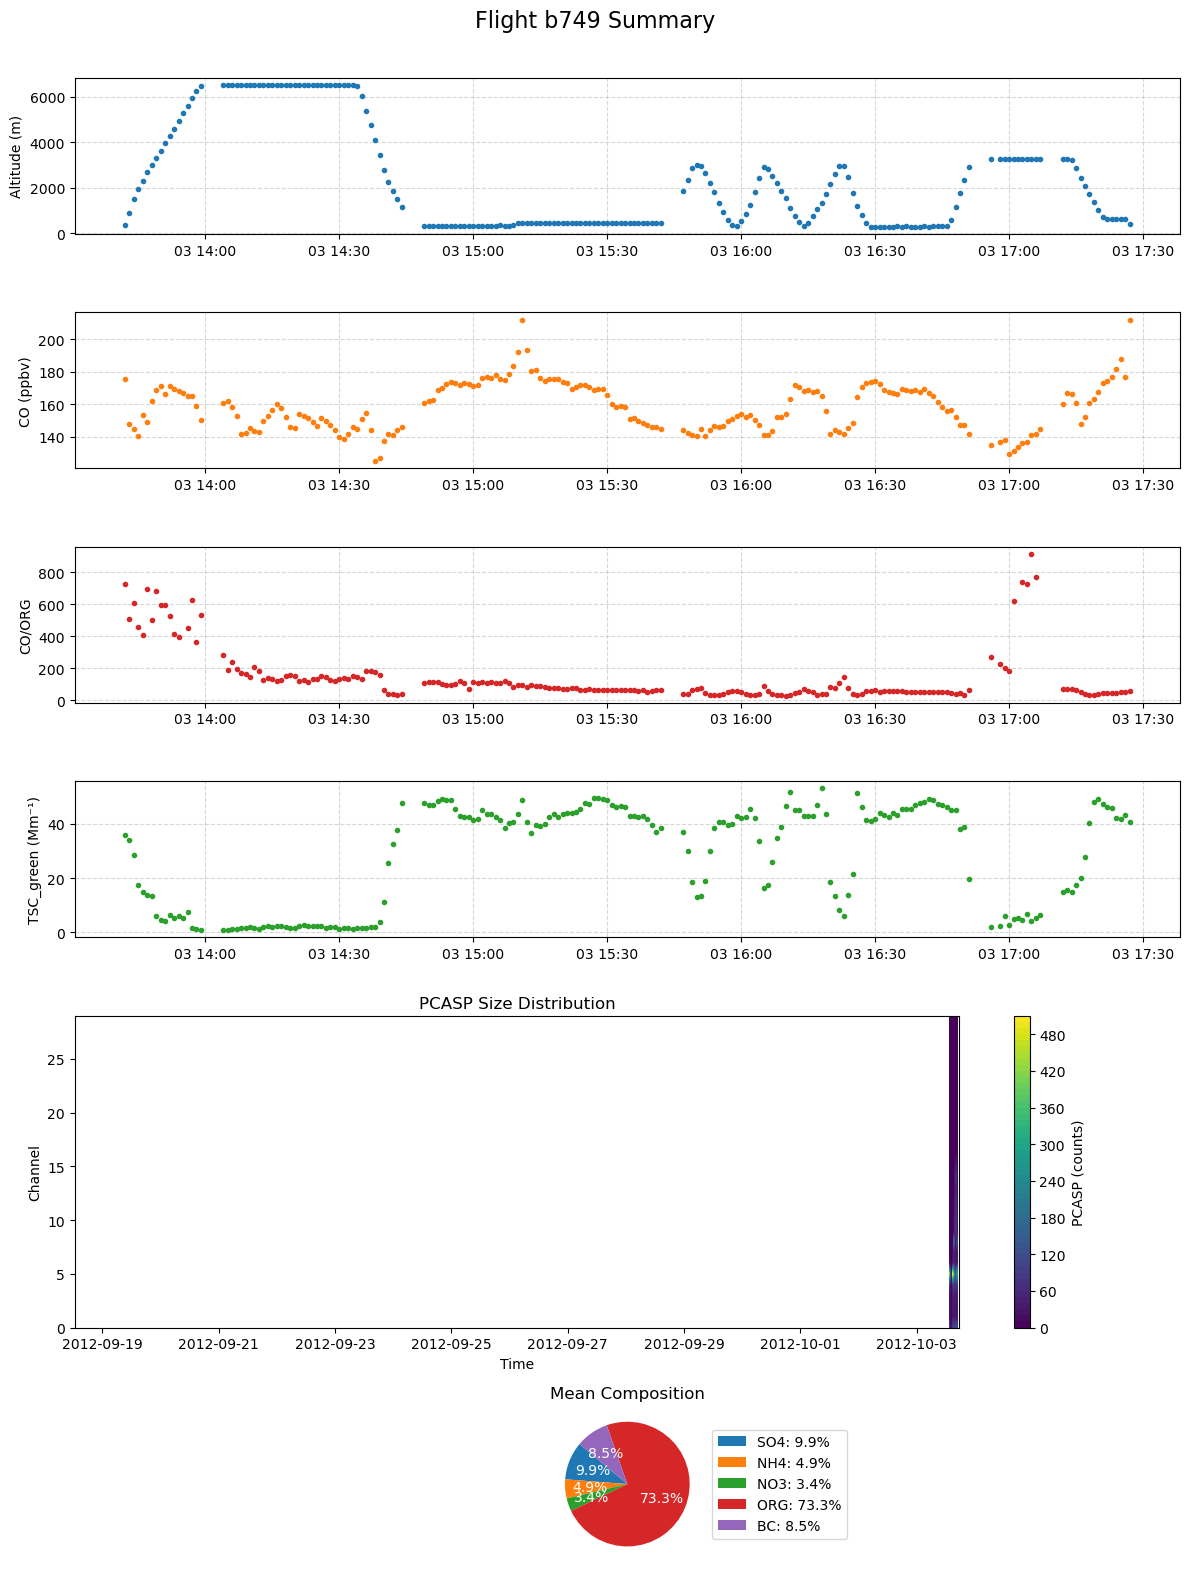

In [108]:
plot_flight_summary_and_regressions_xr_v2(ds_all_flights)

In [151]:
def plot_pcasp_concentration_flight(ds_all, flight_id, D_lower_limits, D_upper_limits,
                                    density=1.8):
    """
    Plot PCASP mass concentration as a contour plot vs. time and D_mid for a single flight.

    Parameters
    ----------
    ds_all : xarray.Dataset
        Dataset containing 'PCASP' with dims (flight, channel, time).
    flight_id : str
        Flight identifier to plot (must exist in ds_all.flight).
    D_lower_limits, D_upper_limits : array-like
        Lower and upper diameter limits of PCASP bins (µm).
    density : float, optional
        Particle density in g/cm³ (default = 1.8).
    vmin, vmax : float, optional
        Limits for color scaling (default = 0.1 to 1e3 µg/m³).
    """

    # --- Select flight ---
    ds_f = ds_all.sel(flight=flight_id)

    # --- Extract PCASP data ---
    da_pcasp = ds_f["PCASP"]  # (channel, time)
    print(da_pcasp)
    # --- Keep only valid times (non-NaN data) ---
    valid_mask = da_pcasp.notnull().any(dim="channel")
    da_pcasp = da_pcasp.sel(time=da_pcasp.time[valid_mask])

    # --- Compute mid diameters (µm) ---
    D_mid = (np.array(D_lower_limits) + np.array(D_upper_limits)) / 2.0
    D_mid = np.nan_to_num(D_mid, nan=0.0)

    # --- Particle volume (µm³) assuming spheres ---
    V_particle = (np.pi / 6.0) * (D_mid ** 3)

    # --- Convert to xarray with channel coordinate ---
    da_V_particle = xr.DataArray(V_particle, dims=["channel"], coords={"channel": ds_f["channel"]})

    # --- Compute volume and mass concentration ---
    vol_conc_bins = da_pcasp * da_V_particle  # µm³/cm³
    mass_conc_bins = vol_conc_bins * density  # µg/m³ per bin

    # --- Prepare for plotting ---
    Z = mass_conc_bins.values  # (channel, time)
    time = da_pcasp.time.values
    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 5))

    cs = ax.contourf(
        time,
        D_mid,
        Z,
        levels=100,
        cmap="viridis",
        #norm=LogNorm(),
        extend='neither'
    )

    # --- Formatting ---
    ax.set_xlabel("Time (UTC)")
    ax.set_ylabel("Dmid (µm)")
    ax.set_title(f"PCASP Mass Concentration – Flight {flight_id}")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.autofmt_xdate()

    # --- Colorbar ---
    fig.colorbar(cs, label="Mass concentration (µg/m³)")

    plt.tight_layout()
    plt.show()

<xarray.DataArray 'PCASP' (channel: 30, time: 1903)> Size: 228kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2012-09-18T12:41:00 ... 2012-10-03T17...
  * channel  (channel) int64 240B 0 1 2 3 4 5 6 7 8 ... 22 23 24 25 26 27 28 29
    flight   <U4 16B 'b737'


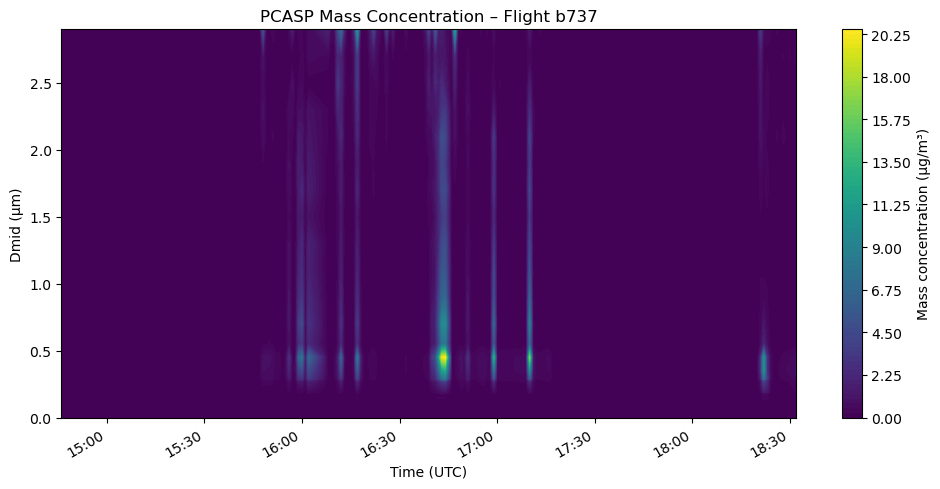

In [152]:
D_lower_limits = ds_core_cloud['PCAS2_D_L_NOM'].values   # shape (30,)
D_upper_limits = ds_core_cloud['PCAS2_D_U_NOM'].values
plot_pcasp_concentration_flight(ds_all_flights,'b737',D_lower_limits,D_upper_limits)

In [175]:
def plot_pcasp_concentration_flight_v2(ax, ds_f, D_lower_limits, D_upper_limits,
                                    density=1.8):
    """
    Plot PCASP mass concentration as a contour plot vs. time and D_mid for a single flight,
    inside a given matplotlib axis (ax). Returns the contour object for colorbar creation.
    """

    da_pcasp = ds_f["PCASP"]  # (channel, time)

    # --- Keep only valid times ---
    valid_mask = da_pcasp.notnull().any(dim="channel")
    da_pcasp = da_pcasp.sel(time=da_pcasp.time[valid_mask])

    # --- Compute D_mid (µm) ---
    D_mid = (np.array(D_lower_limits) + np.array(D_upper_limits)) / 2.0
    D_mid = np.nan_to_num(D_mid, nan=0.0)

    # --- Particle volume (µm³) ---
    V_particle = (np.pi / 6.0) * (D_mid ** 3)
    da_V_particle = xr.DataArray(V_particle, dims=["channel"], coords={"channel": ds_f["channel"]})

    # --- Compute mass concentration ---
    vol_conc_bins = da_pcasp * da_V_particle
    mass_conc_bins = vol_conc_bins * density

    # --- Prepare data ---
    Z = mass_conc_bins.values
    time = da_pcasp["time"].values

    # --- Plot ---
    pcm = ax.contourf(
        time,
        D_mid,
        Z,
        levels=100,
        cmap="viridis",
        #norm=LogNorm(),
        extend='both'
    )

    ax.set_ylabel("Dmid (µm)")
    ax.set_xlabel("Time (UTC)")
    ax.set_title("PCASP Mass Concentration")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

    return pcm  # This is crucial for the colorbar

In [176]:
def plot_flight_summary_and_regressions_xr_v3(ds_all, D_lower_limits, D_upper_limits):
    """
    Plot for each flight:
      - Altitude vs. time
      - CO vs. time
      - TSC_green vs. time
      - PCASP contour (channel vs. time)
      - Pie chart of average composition (SO4, NH4, NO3, ORG, BC)
    """

    for flight in ds_all.flight.values:
        ds_f = ds_all.sel(flight=flight)

        time = ds_f.time.values
        alt   = ds_f.ALT.values
        co    = ds_f.CO.values
        tsc_g = ds_f.TSC_green.values

        species = ['SO4','NH4','NO3','ORG','BC']
        avg_comp = np.array([float(ds_f[v].mean()) for v in species])
        pct = 100*avg_comp/np.nansum(avg_comp)

        # --- Figure layout ---
        fig = plt.figure(figsize=(12, 14))
        gs = fig.add_gridspec(5, 1, height_ratios=[1, 1, 1, 1, 1])
        fig.suptitle(f"Flight {flight} Summary",fontsize=16)

        ax1 = fig.add_subplot(gs[0]); ax1.plot(time,alt,'.',color='tab:blue')
        ax1.set_ylabel('Altitude (m)'); ax1.grid(True,ls='--',alpha=0.5)

        ax2 = fig.add_subplot(gs[1]); ax2.plot(time,co,'.',color='tab:orange')
        ax2.set_ylabel('CO (ppbv)'); ax2.grid(True,ls='--',alpha=0.5)

         # --- Replace CO/ORG with PCASP Number Concentration ---
        ax3 = fig.add_subplot(gs[2]); plot_pcasp_concentration_flight_v2(ax3, ds_f, D_lower_limits, D_upper_limits,)

        ax4 = fig.add_subplot(gs[3]); ax4.plot(time,tsc_g*1e6,'.',color='tab:green')
        ax4.set_ylabel('TSC_green (Mm⁻¹)'); ax4.grid(True,ls='--',alpha=0.5)

        ax6 = fig.add_subplot(gs[4])
        ax6.pie(avg_comp,labels=species,autopct=lambda p:f"{p:.1f}%",startangle=140,
                textprops={'color':"w"})
        ax6.set_title('Mean Composition')
        ax6.legend([f"{s}: {p:.1f}%" for s,p in zip(species,pct)],
                   loc='center left',bbox_to_anchor=(1,0.5))

        plt.tight_layout(rect=[0,0,1,0.97])
        plt.show()


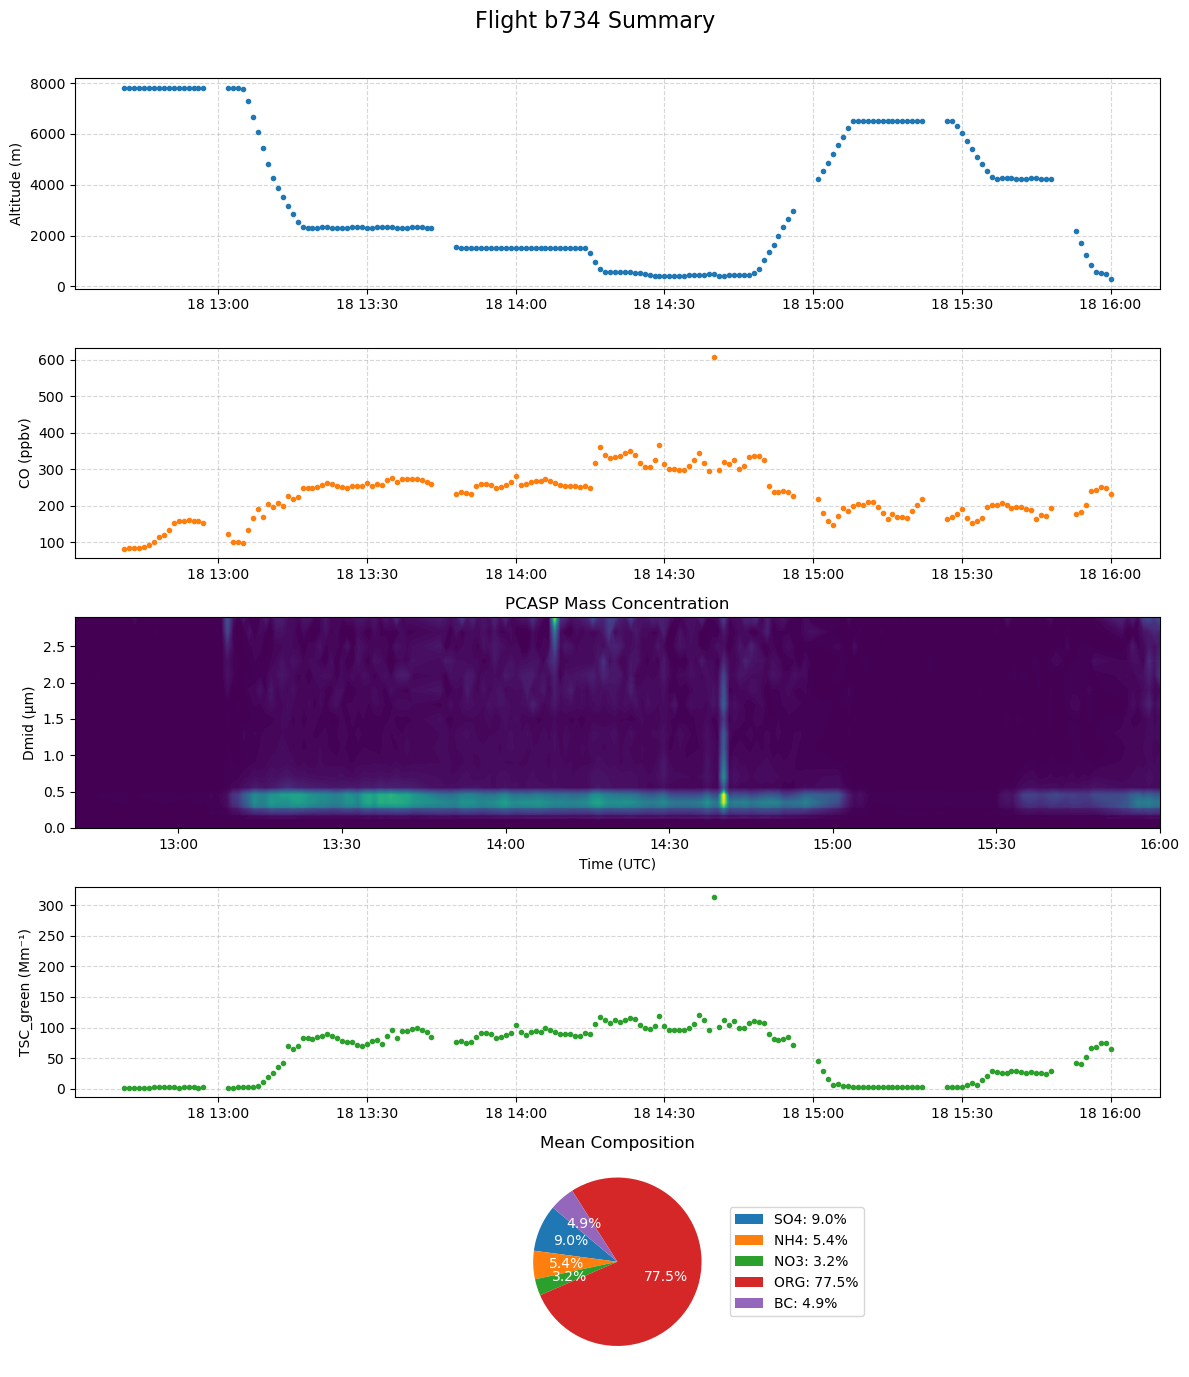

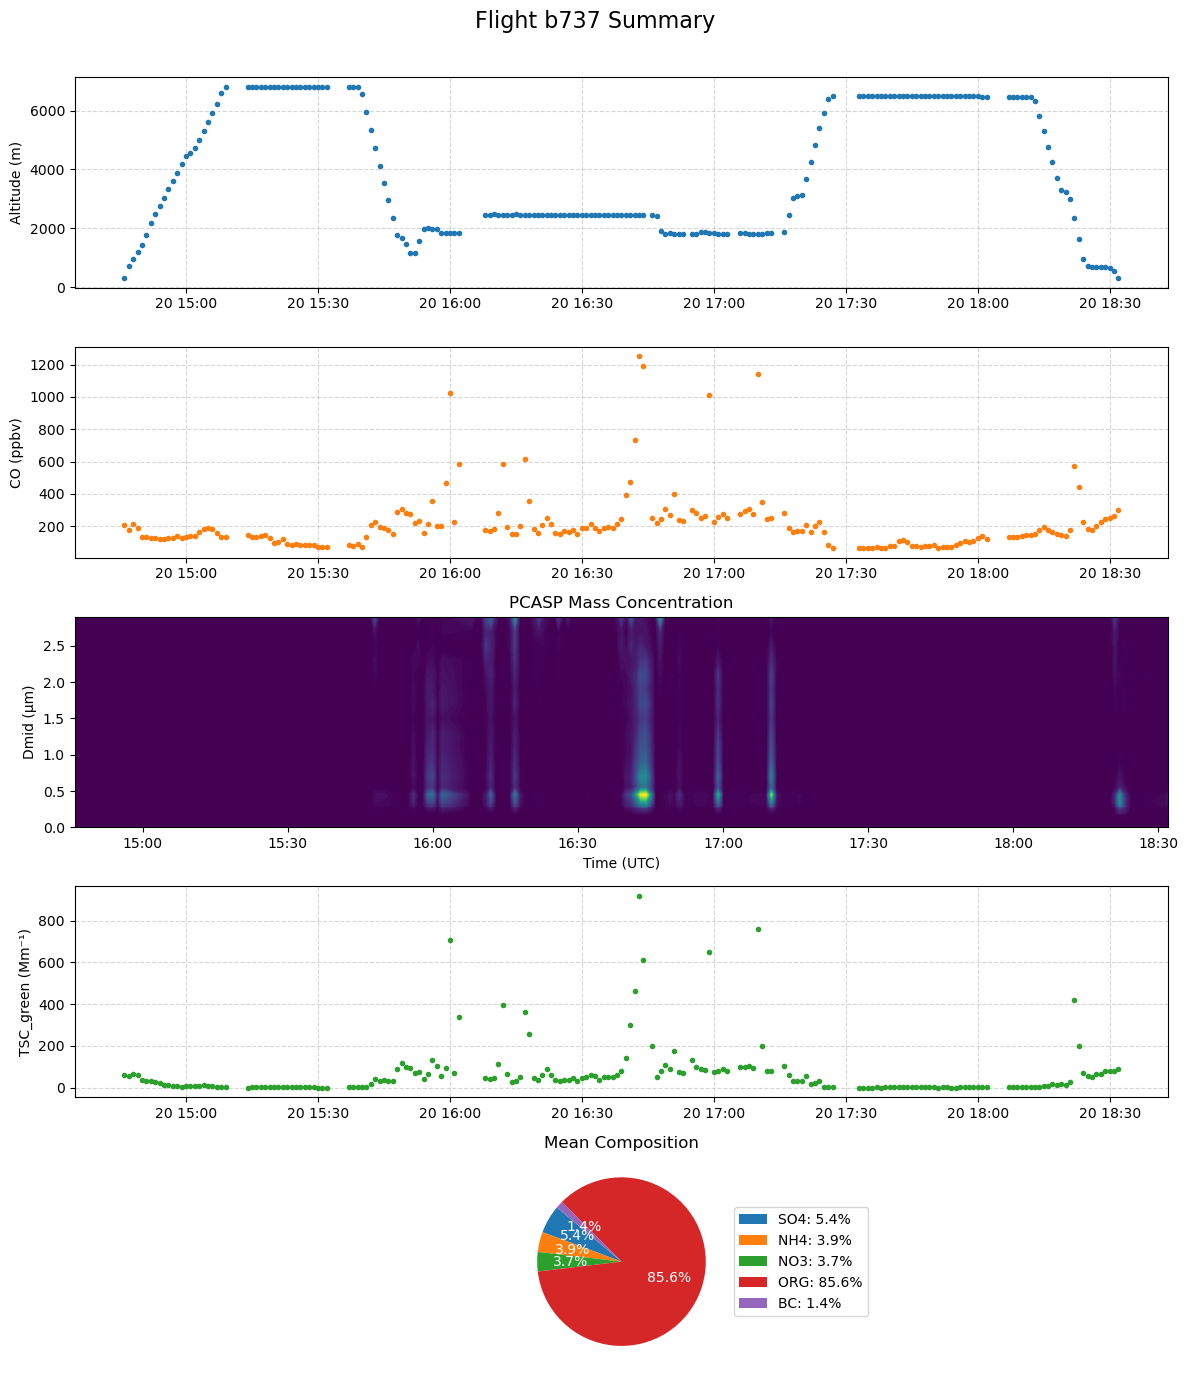

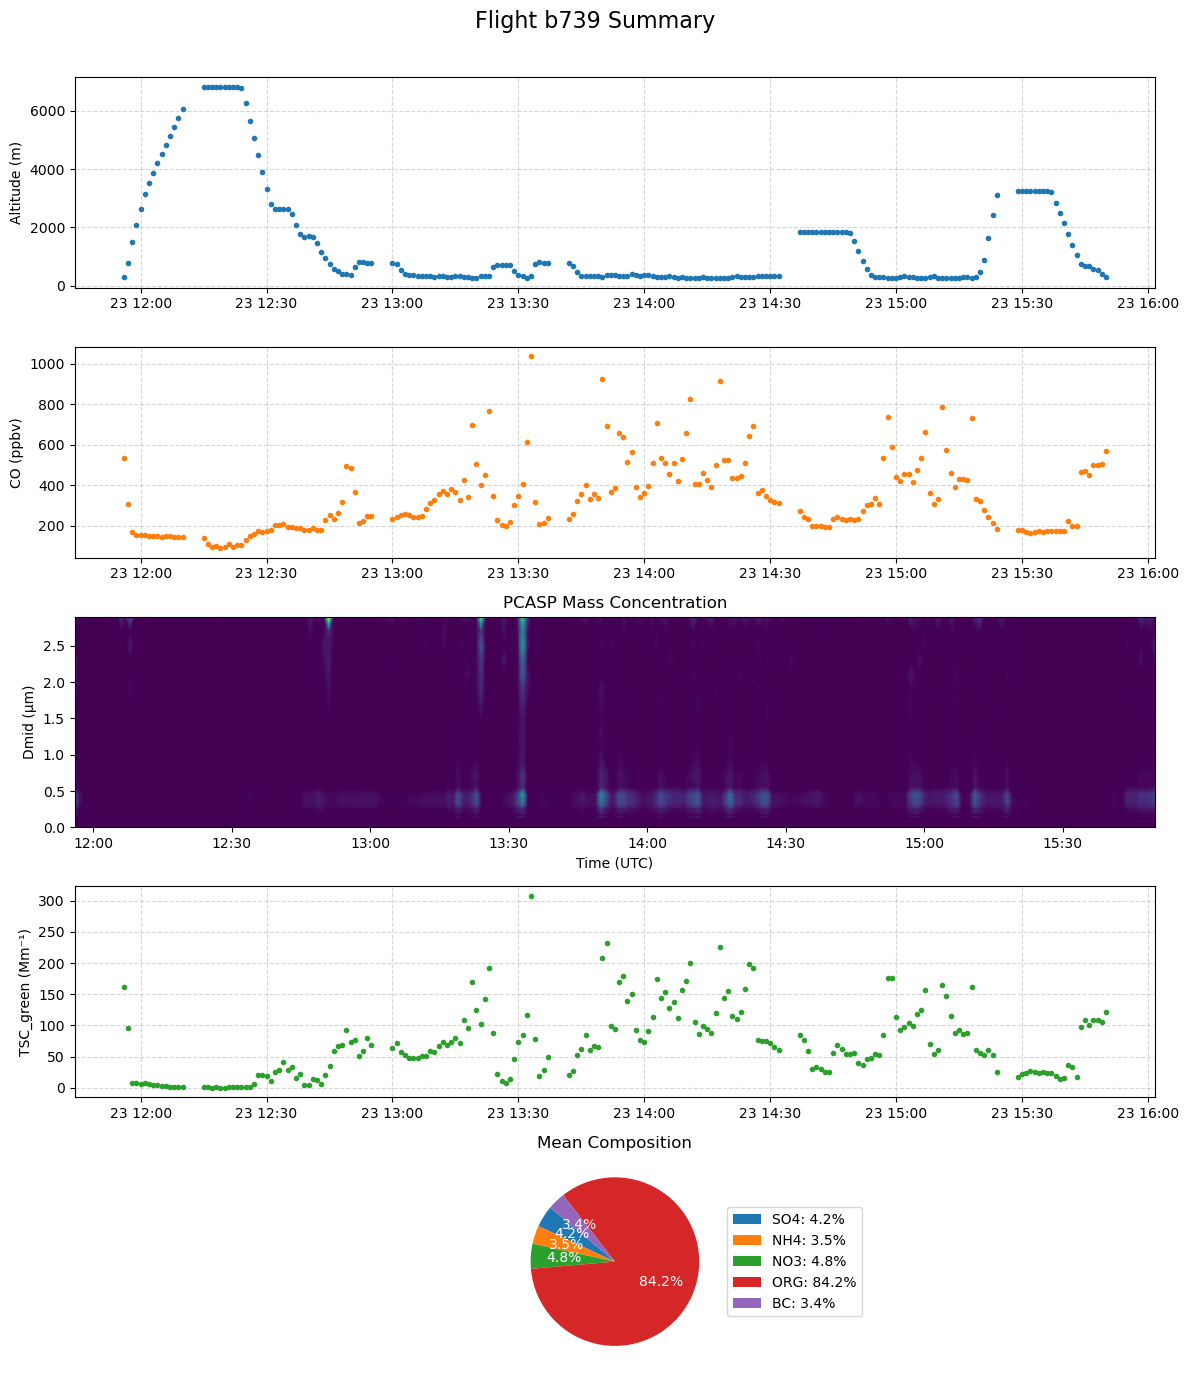

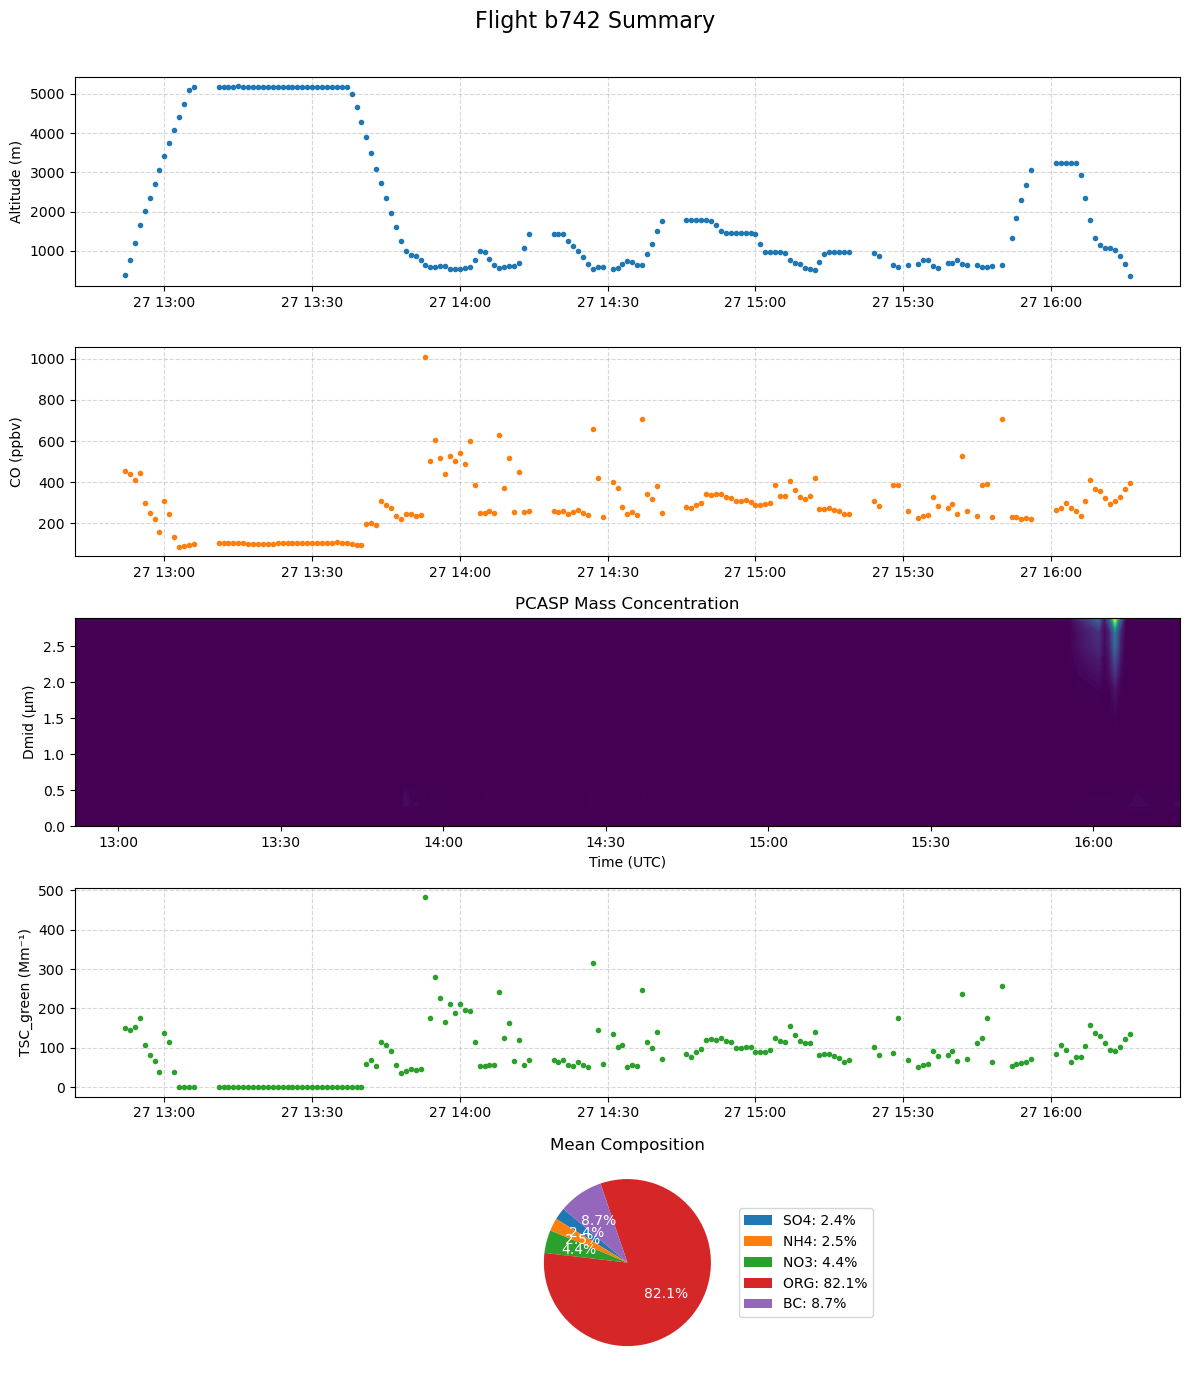

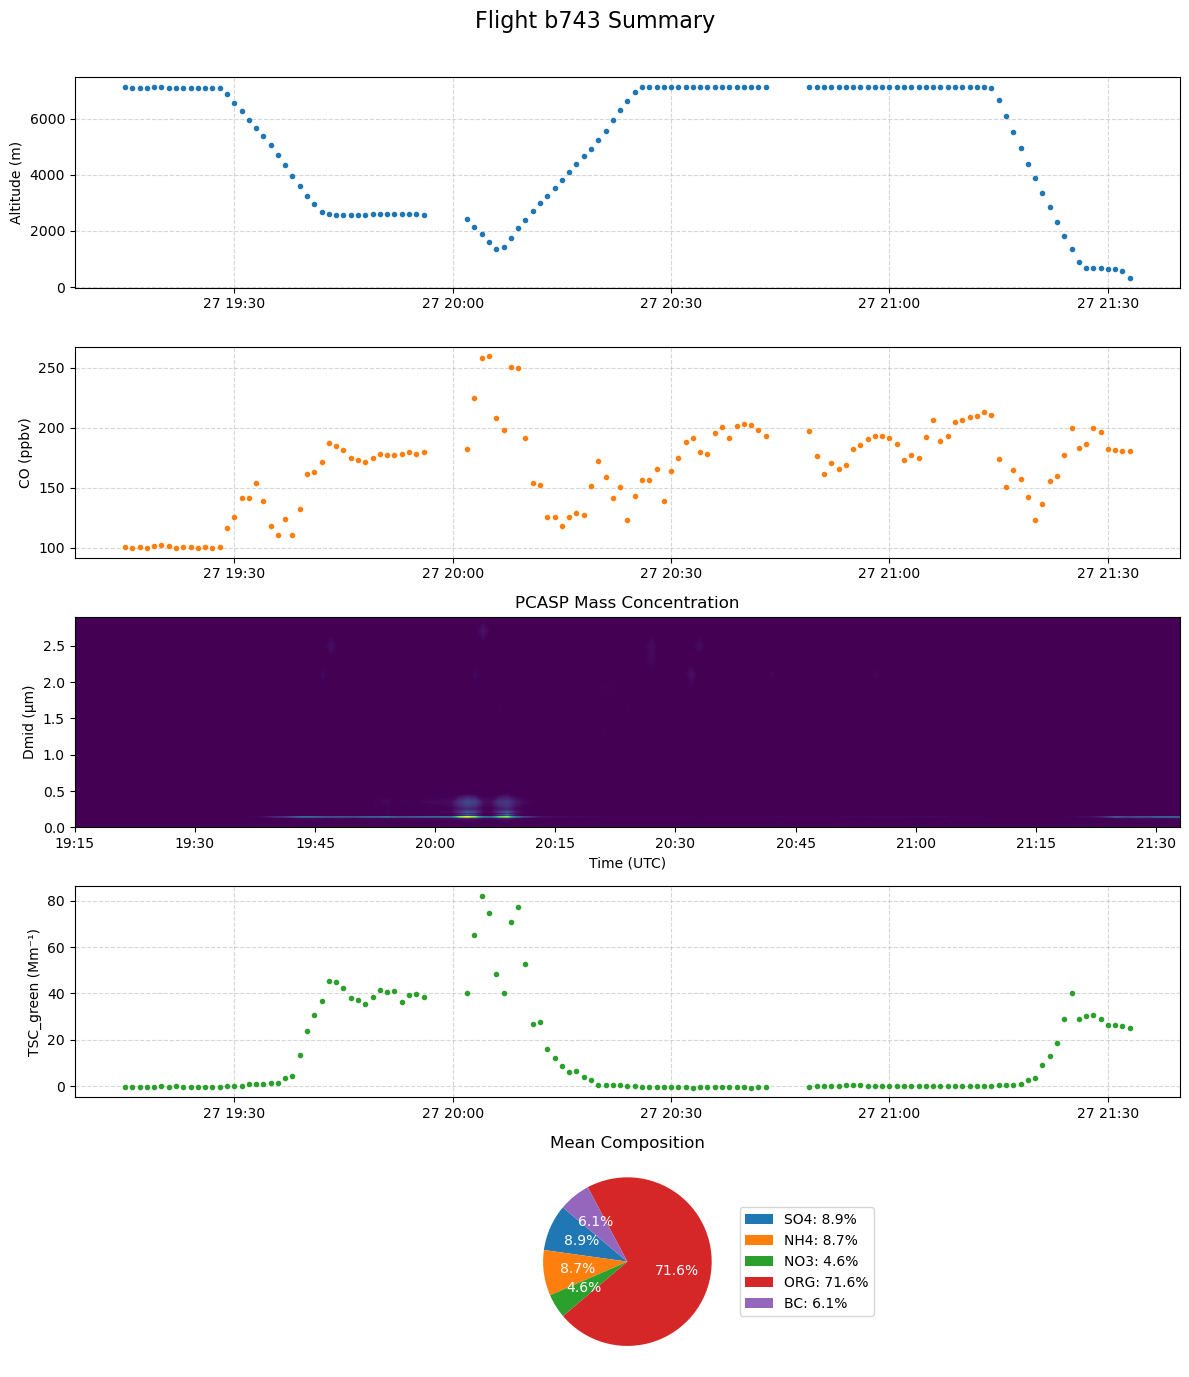

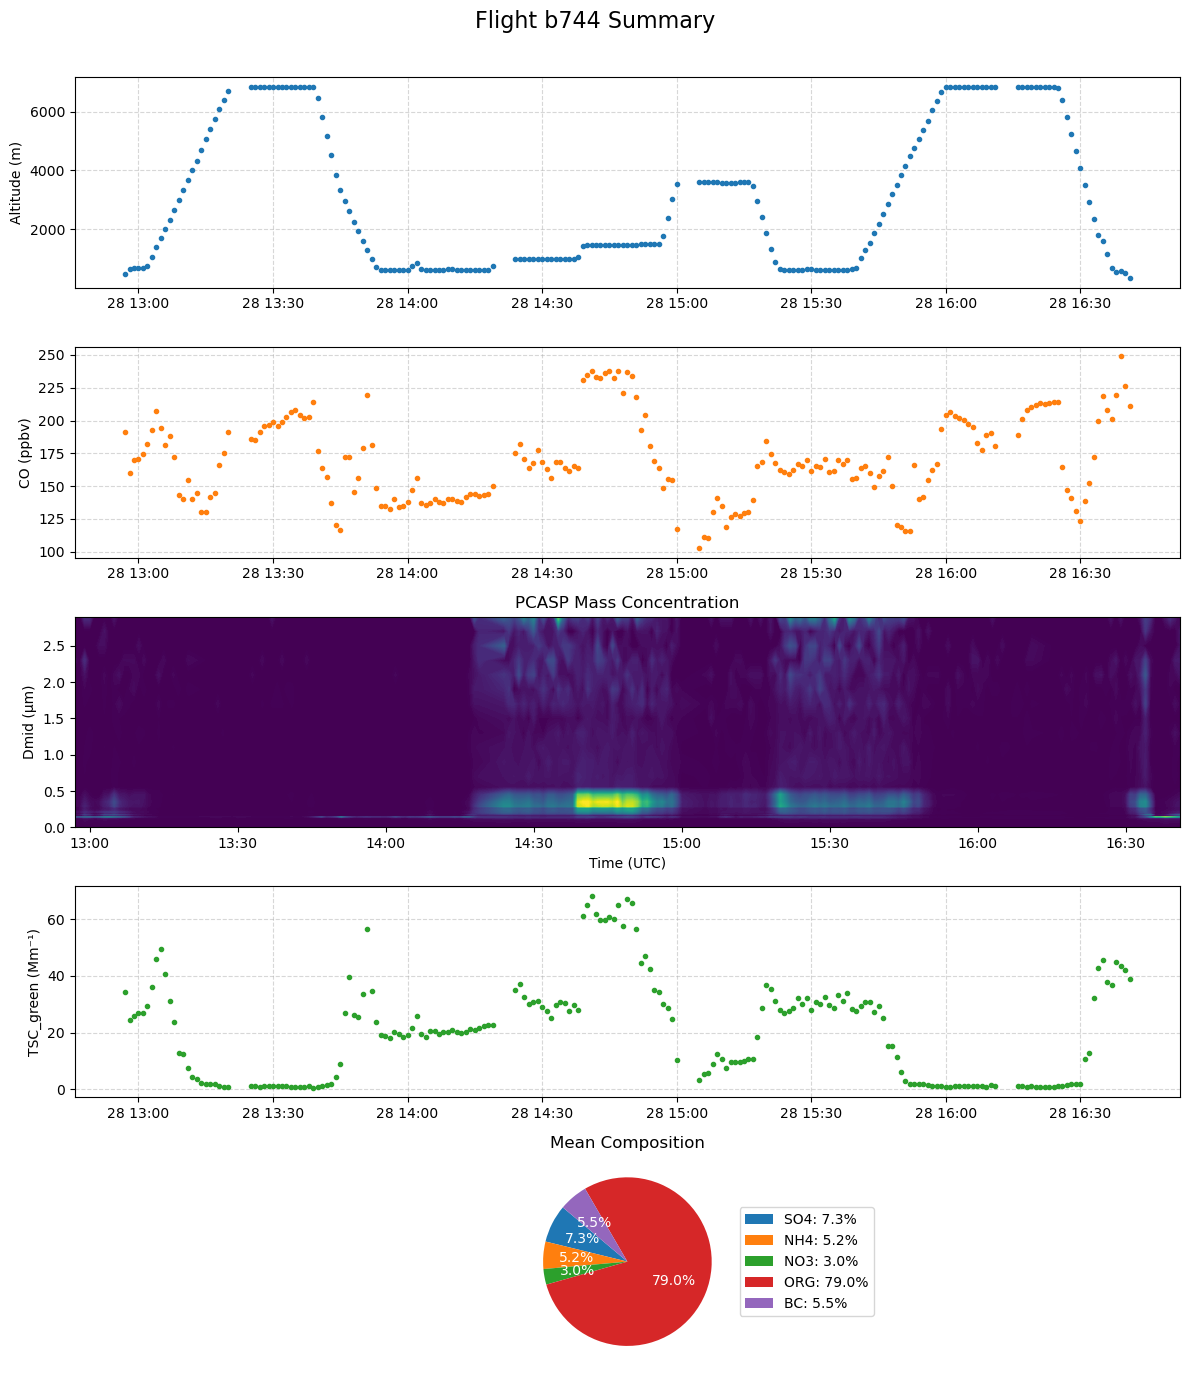

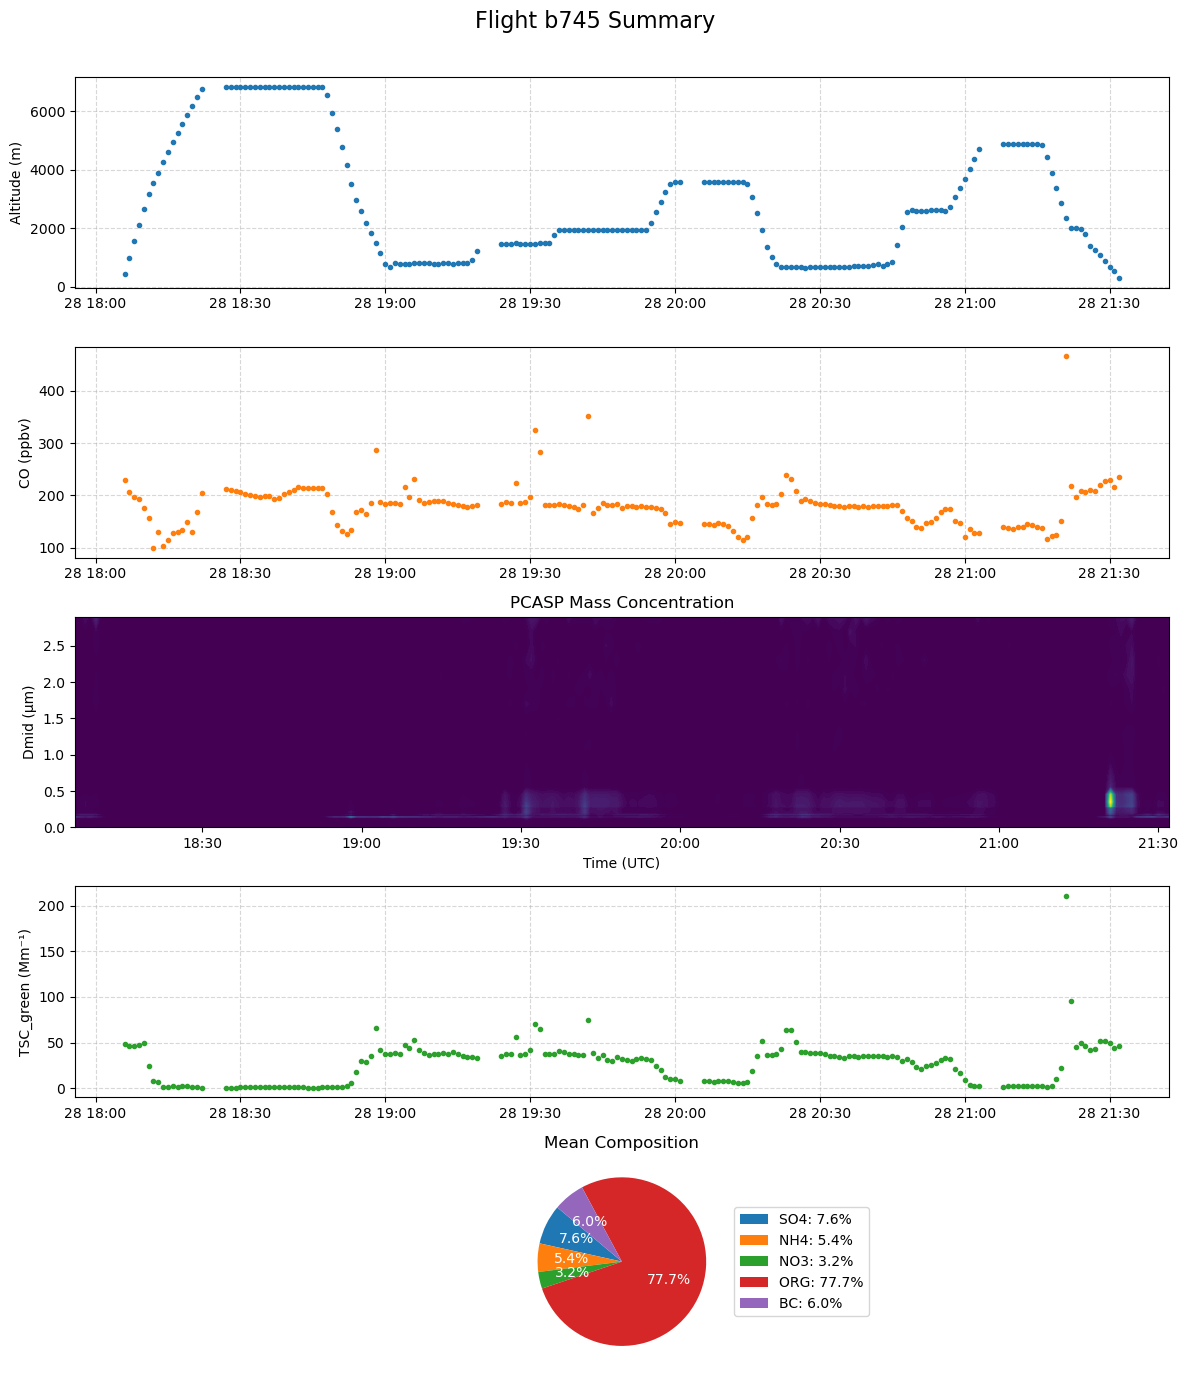

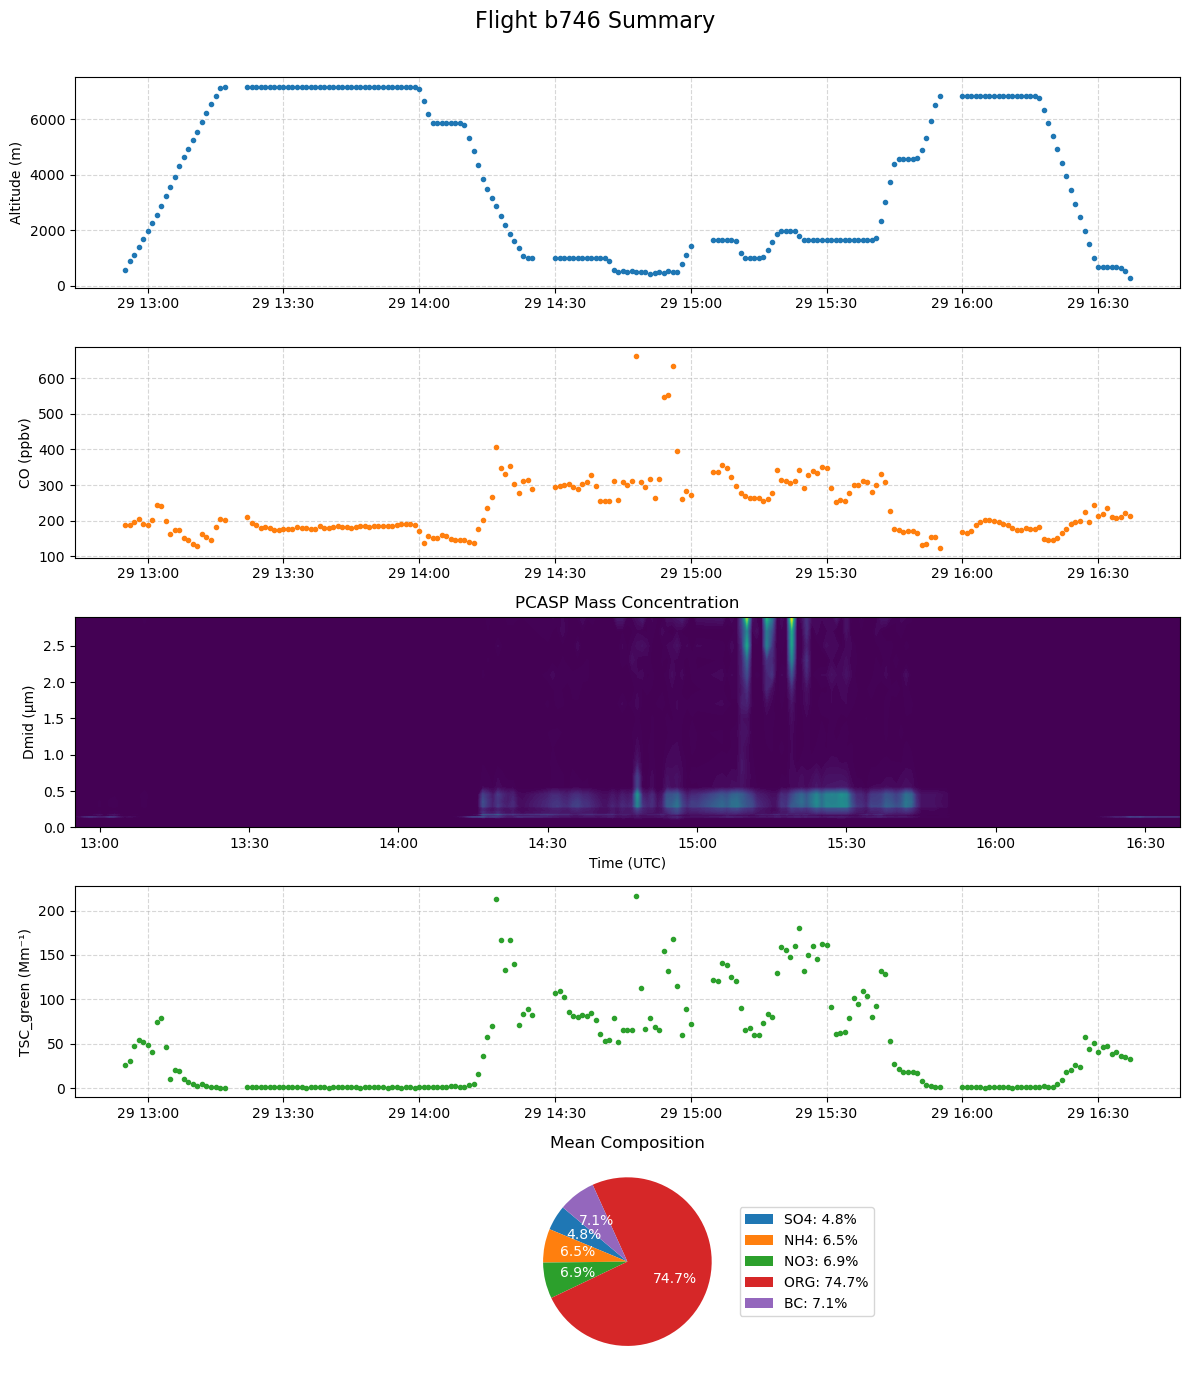

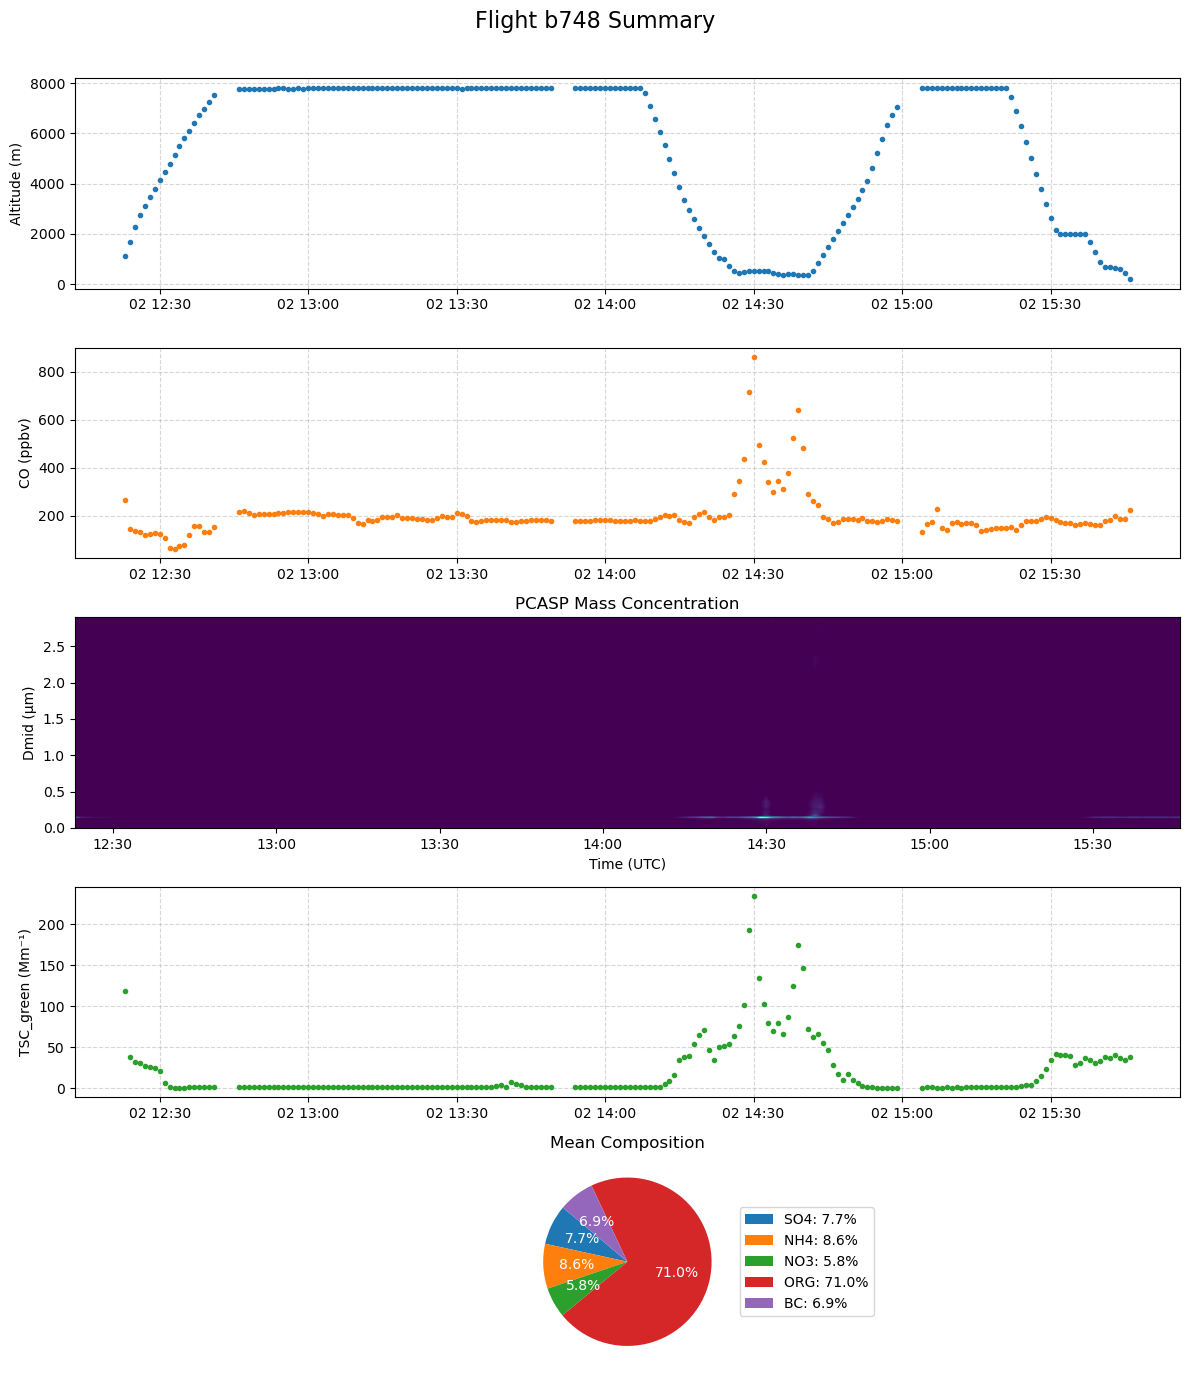

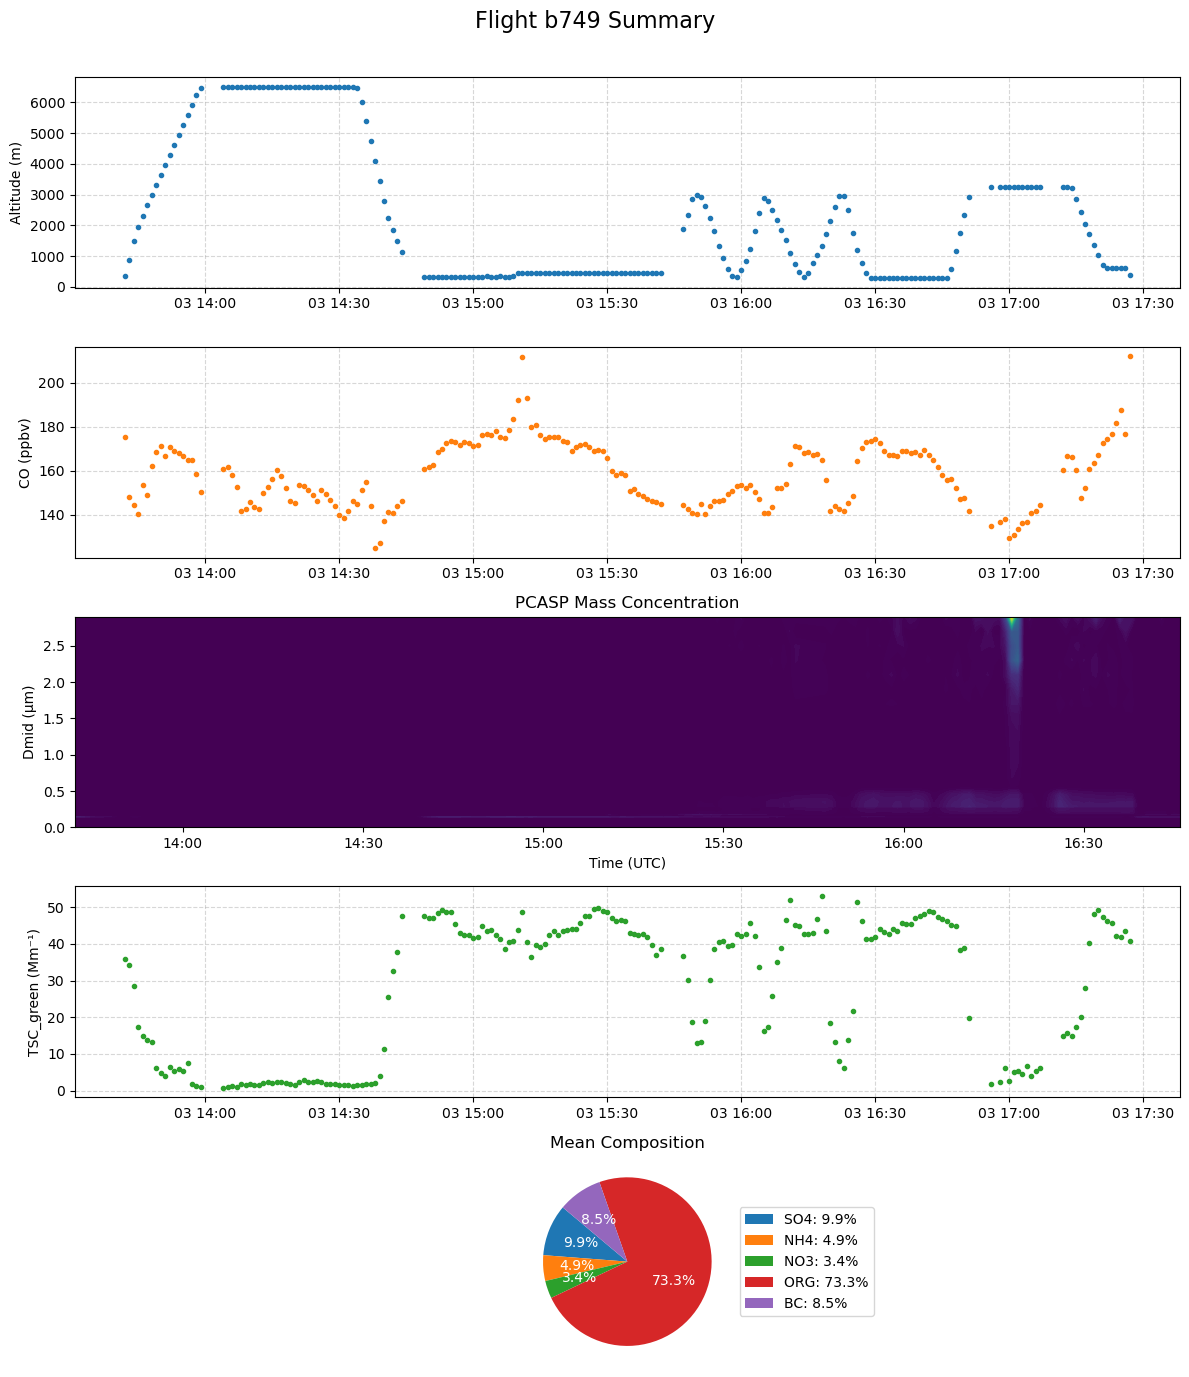

In [177]:
D_lower_limits = ds_core_cloud['PCAS2_D_L_NOM'].values   # shape (30,)
D_upper_limits = ds_core_cloud['PCAS2_D_U_NOM'].values
plot_flight_summary_and_regressions_xr_v3(ds_all_flights,D_lower_limits,D_upper_limits)

In [178]:
def plot_flight_summary_and_regressions_xr_v4(ds_all, D_lower_limits, D_upper_limits):
    """
    Plot for each flight:
      - Altitude vs. time
      - CO vs. time
      - TSC_green vs. time
      - PCASP contour (channel vs. time) with colorbar
    All plots share the same x-axis (time)
    """

    for flight in ds_all.flight.values:
        ds_f = ds_all.sel(flight=flight)

        time = ds_f.time.values
        alt   = ds_f.ALT.values
        co    = ds_f.CO.values
        tsc_g = ds_f.TSC_green.values

        # --- Figure layout ---
        fig = plt.figure(figsize=(13, 12))  # Slightly wider to accommodate colorbar
        # Create grid with 4 main plots and extra space for colorbar
        gs = fig.add_gridspec(4, 2, width_ratios=[20, 1], height_ratios=[1, 1, 1, 1])
        fig.suptitle(f"Flight {flight} Summary", fontsize=16)

        # Create subplots with shared x-axis
        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
        ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
        ax4 = fig.add_subplot(gs[3, 0], sharex=ax1)
        
        # Create axis for colorbar
        cax = fig.add_subplot(gs[2, 1])

        # Plot data
        ax1.plot(time, alt, '.', color='tab:blue')
        ax1.set_ylabel('Altitude (m)')
        ax1.grid(True, ls='--', alpha=0.5)

        ax2.plot(time, co, '.', color='tab:orange')
        ax2.set_ylabel('CO (ppbv)')
        ax2.grid(True, ls='--', alpha=0.5)

        # PCASP concentration plot - now returns pcm for colorbar
        pcm = plot_pcasp_concentration_flight_v2(ax3, ds_f, D_lower_limits, D_upper_limits)
        
        # Add colorbar to the dedicated axis
        cbar = fig.colorbar(pcm, cax=cax)
        cbar.set_label('Mass Concentration')

        ax4.plot(time, tsc_g * 1e6, '.', color='tab:green')
        ax4.set_ylabel('TSC_green (Mm⁻¹)')
        ax4.grid(True, ls='--', alpha=0.5)

        # Set x-axis label on the bottom plot only
        ax4.set_xlabel('Time')

        # Hide x-tick labels on all but the bottom plot for cleaner look
        plt.setp(ax1.get_xticklabels(), visible=False)
        plt.setp(ax2.get_xticklabels(), visible=False)
        plt.setp(ax3.get_xticklabels(), visible=False)

        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

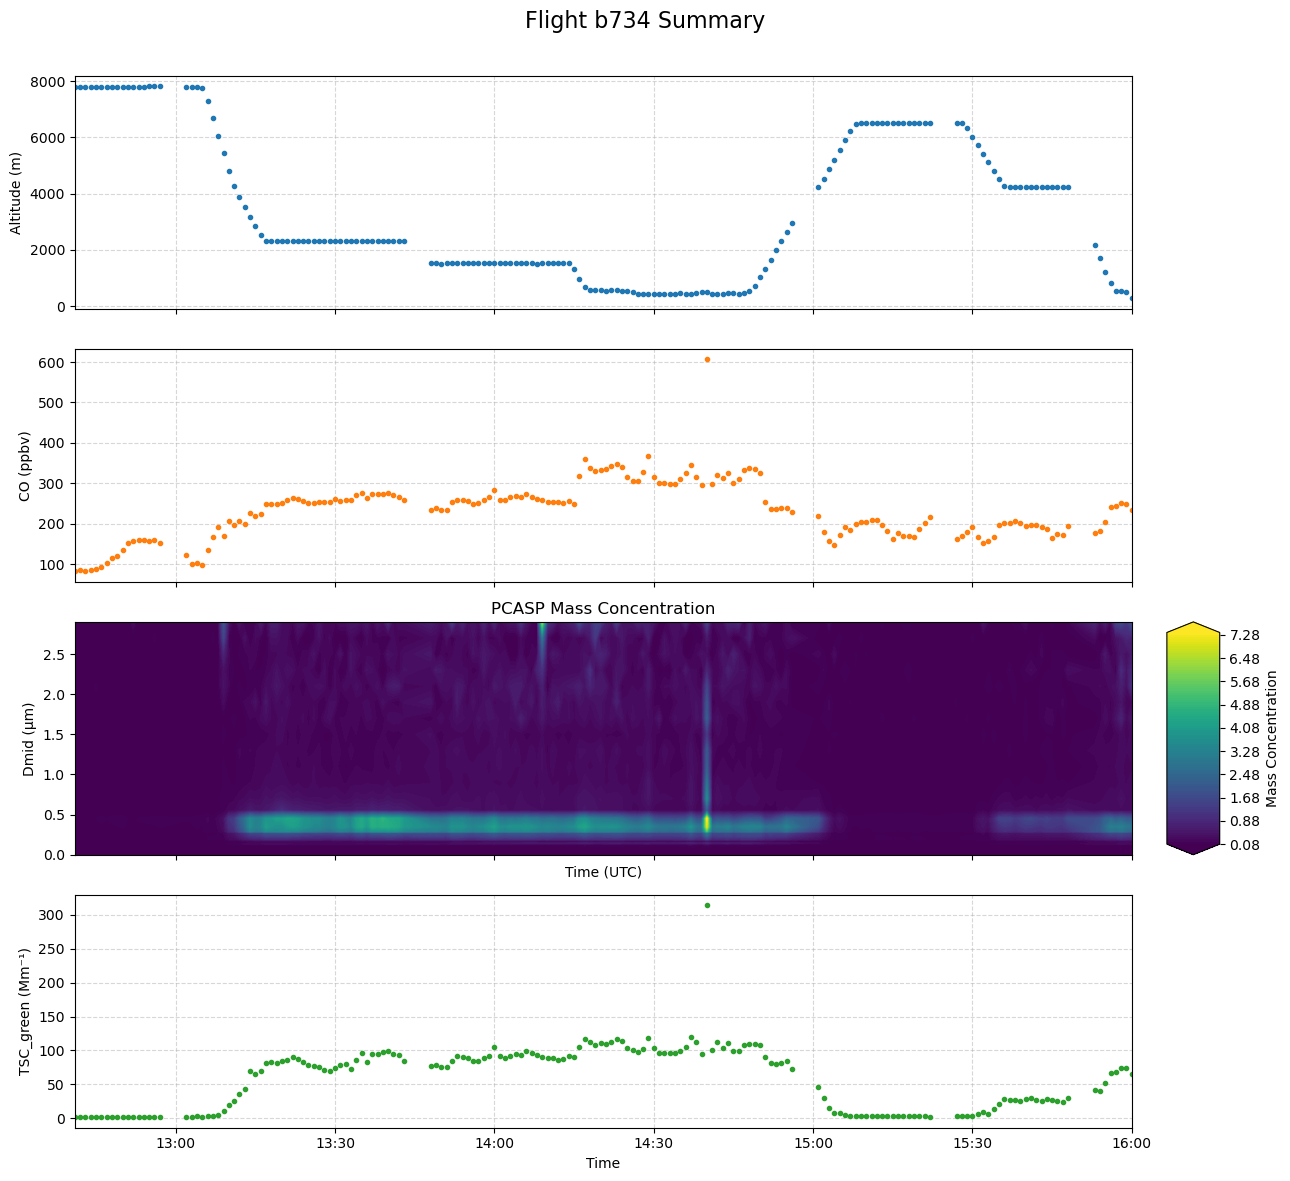

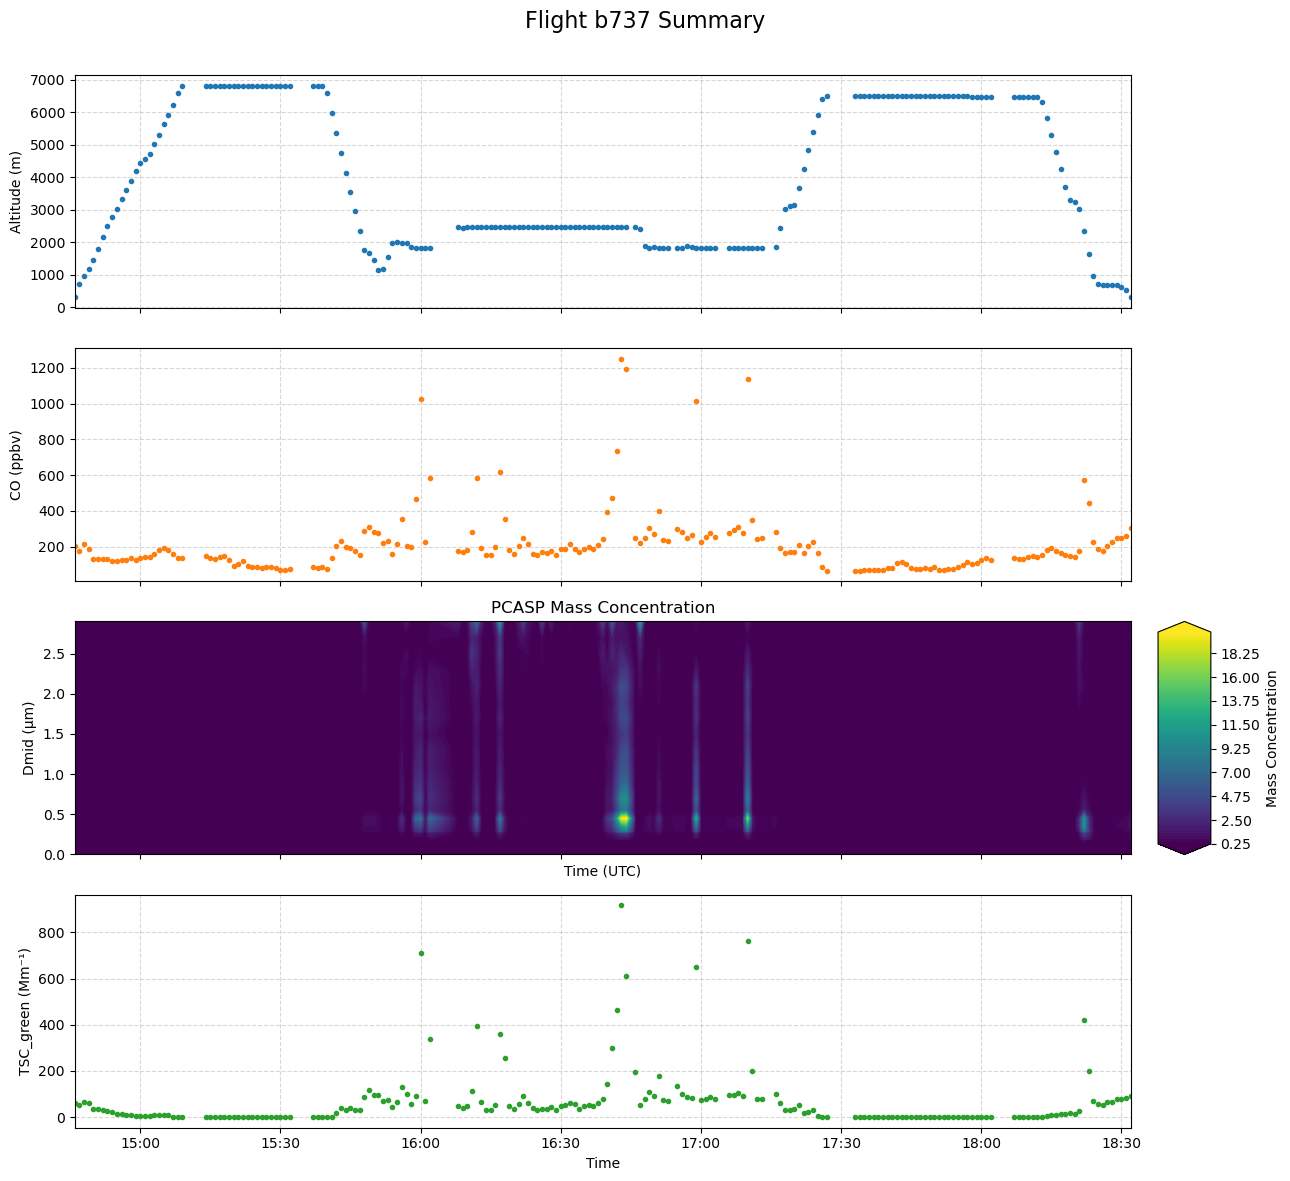

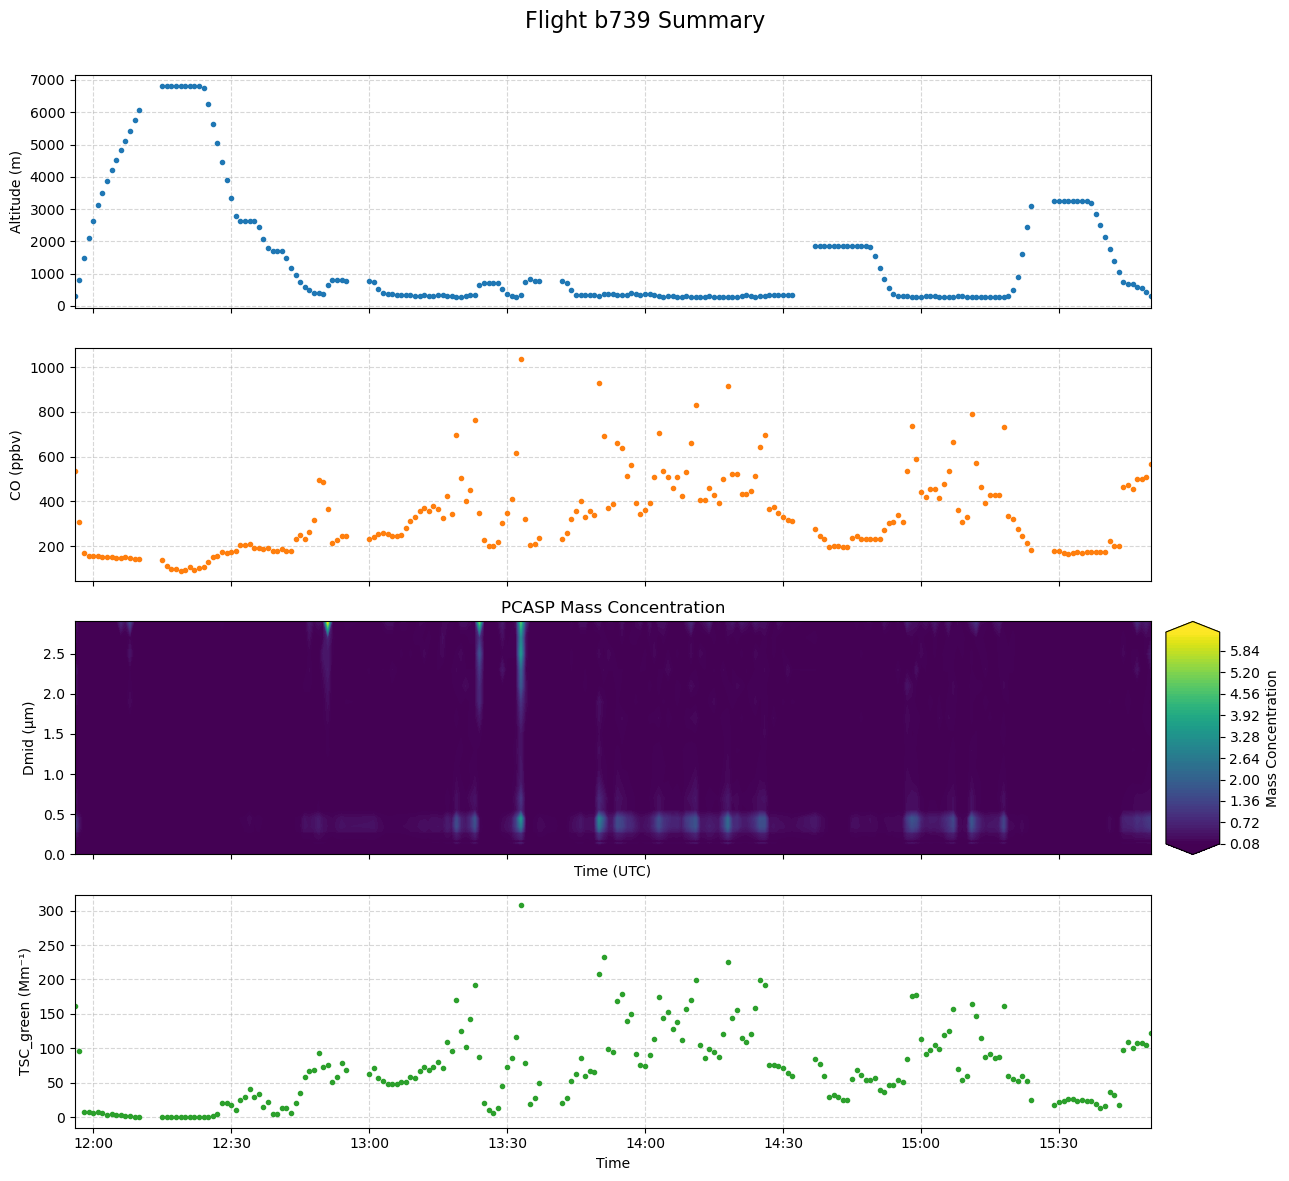

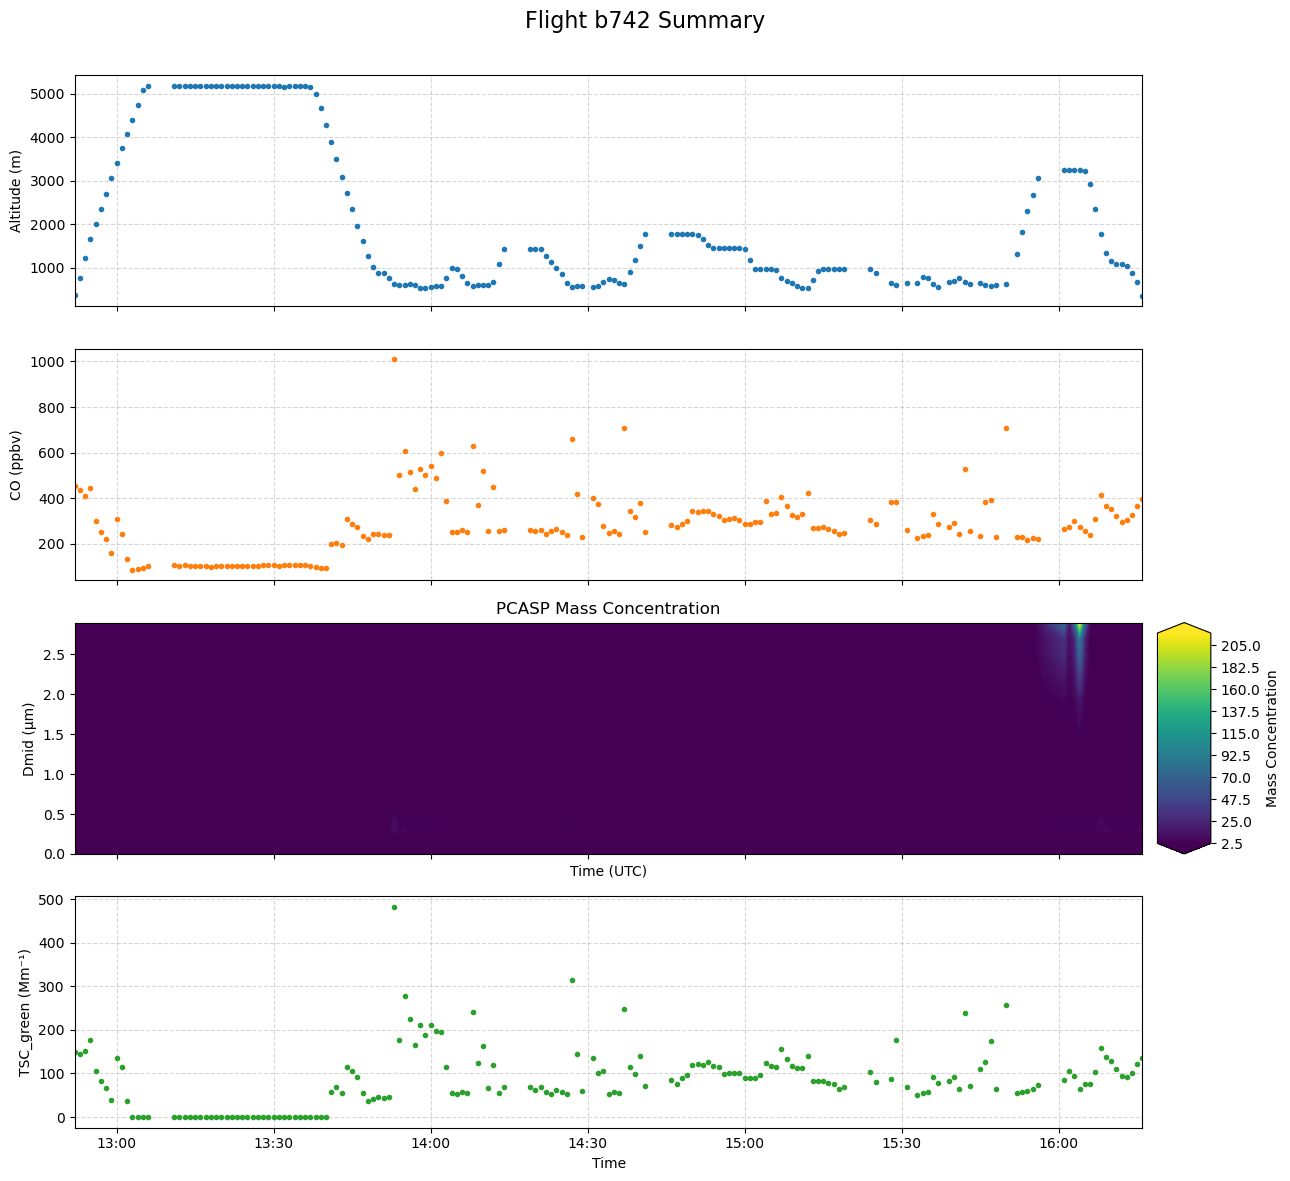

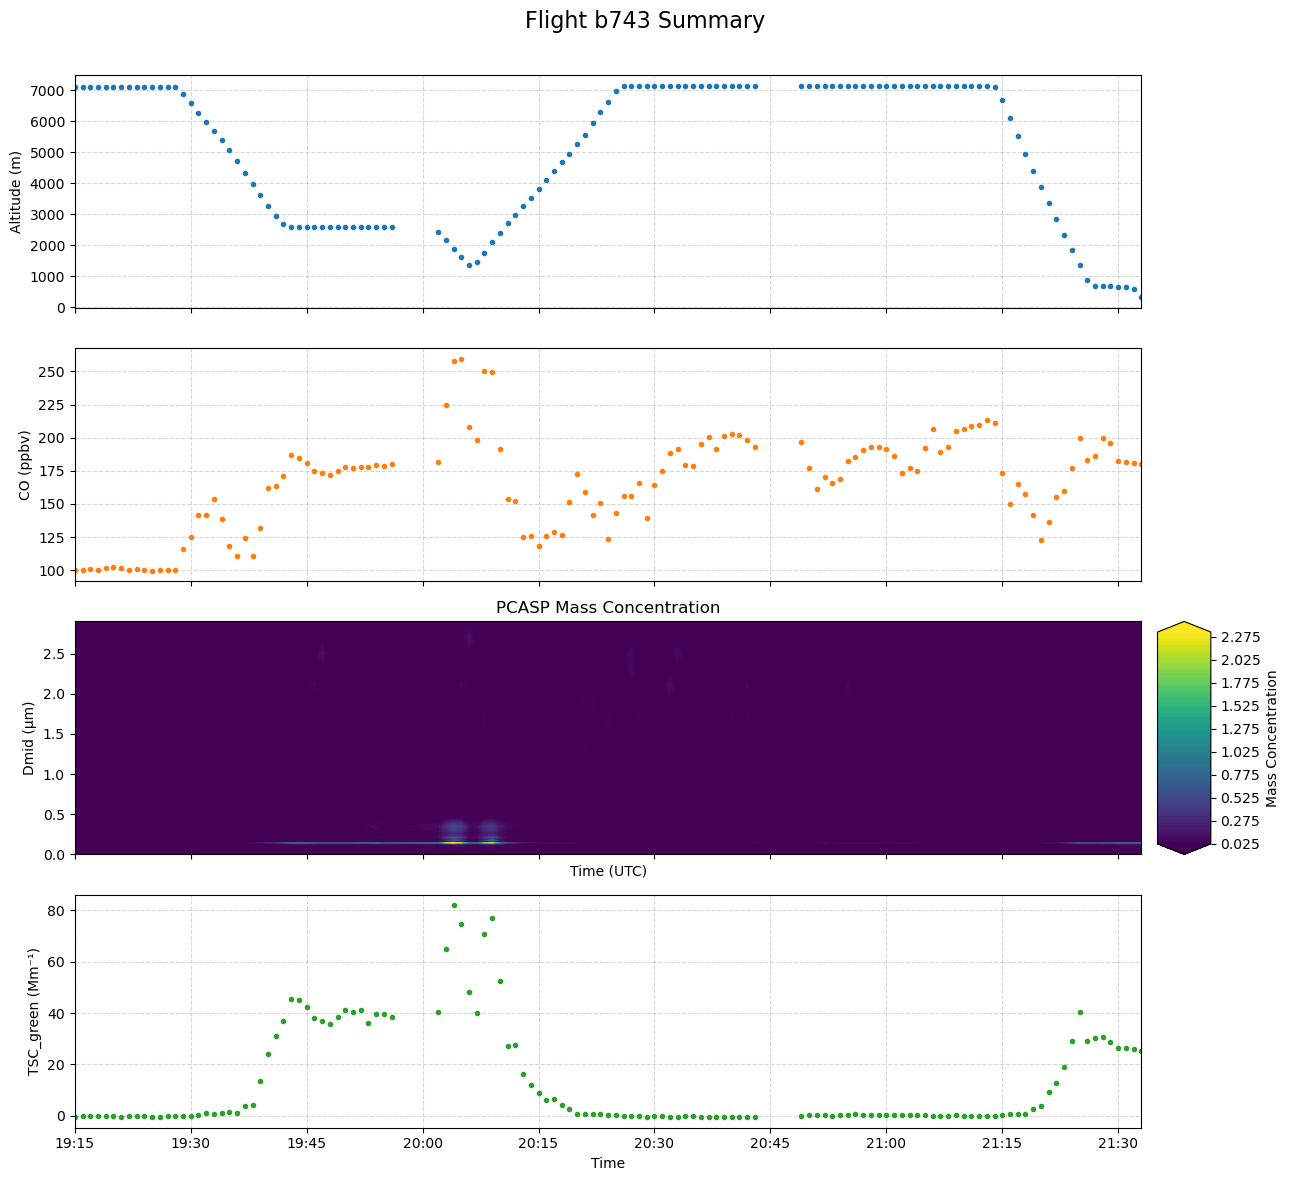

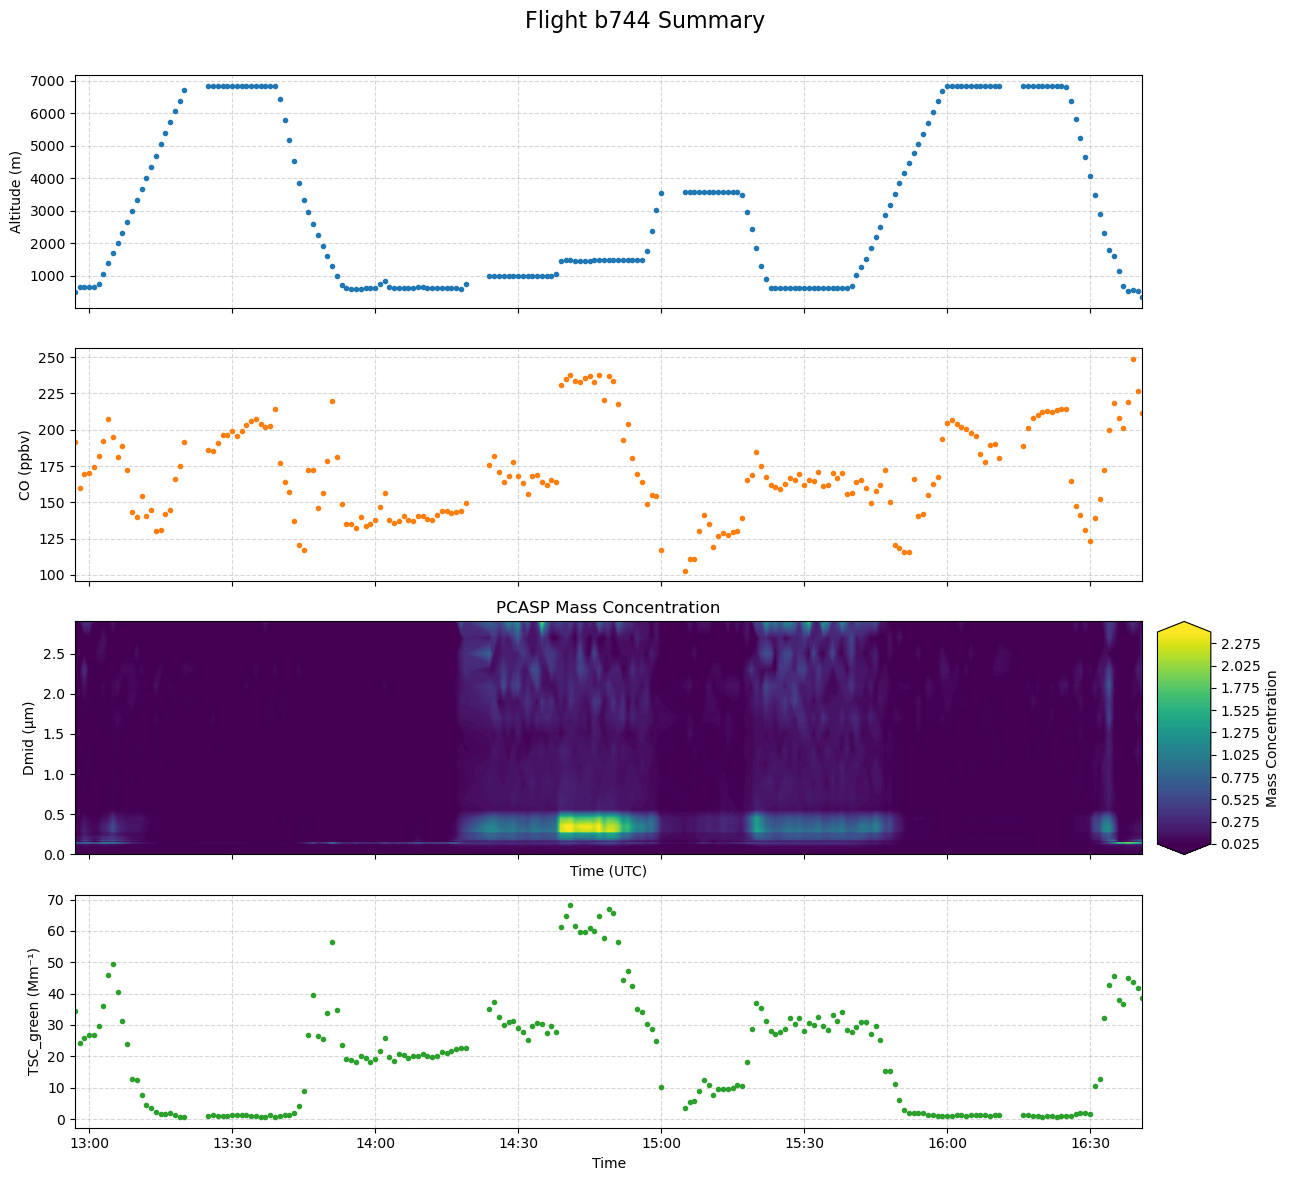

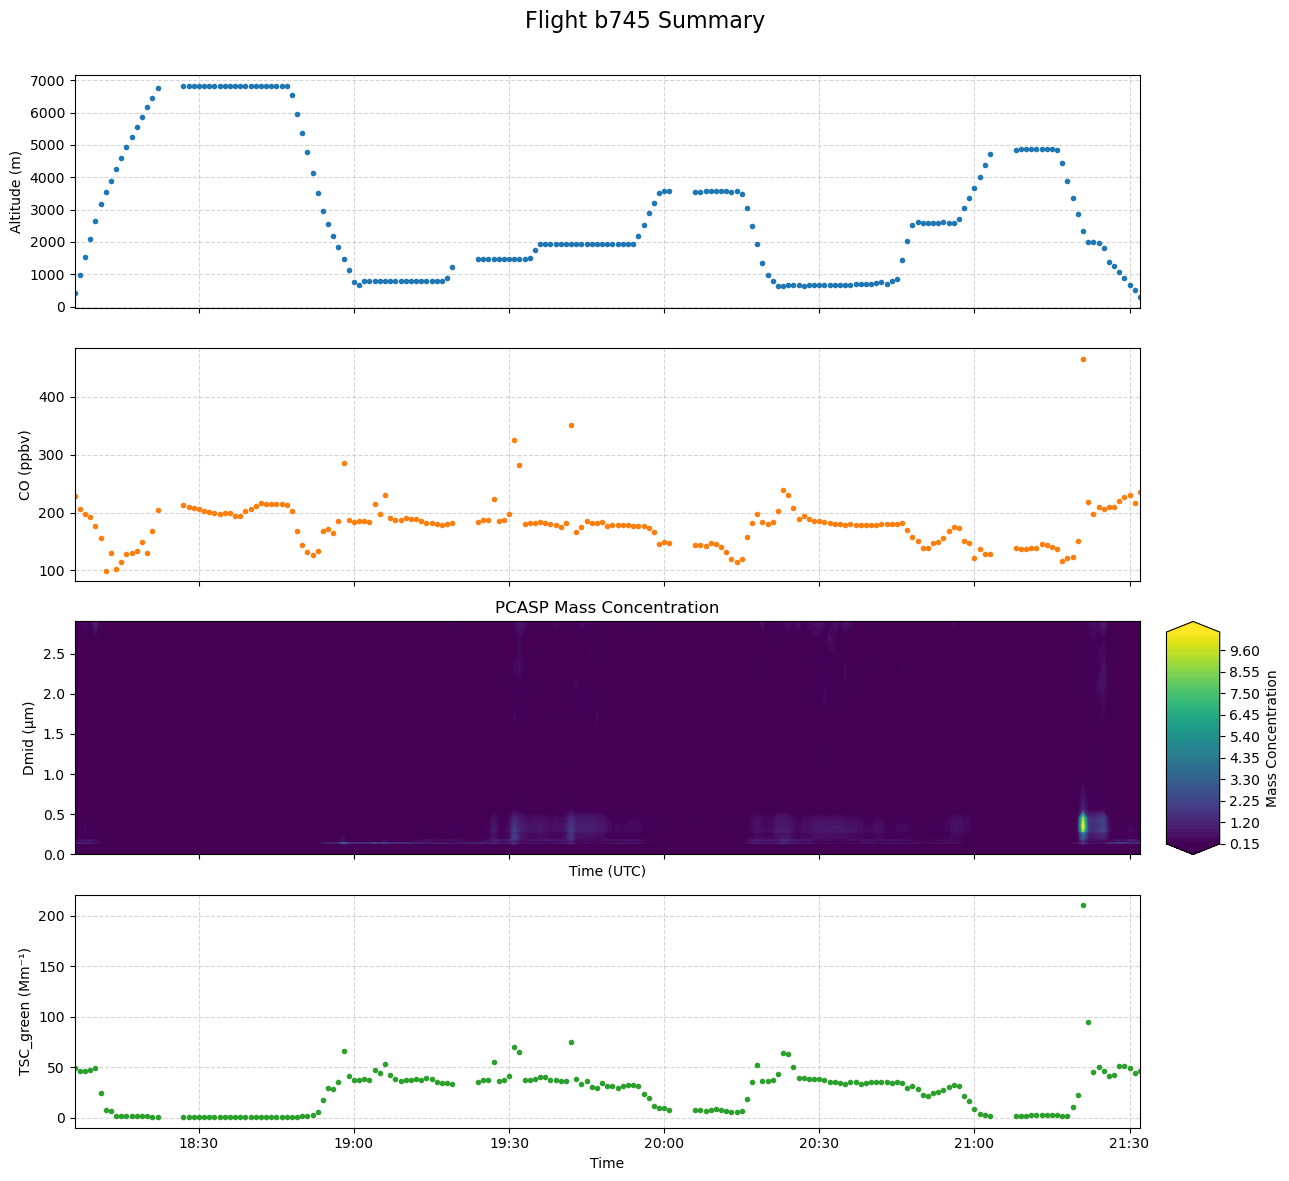

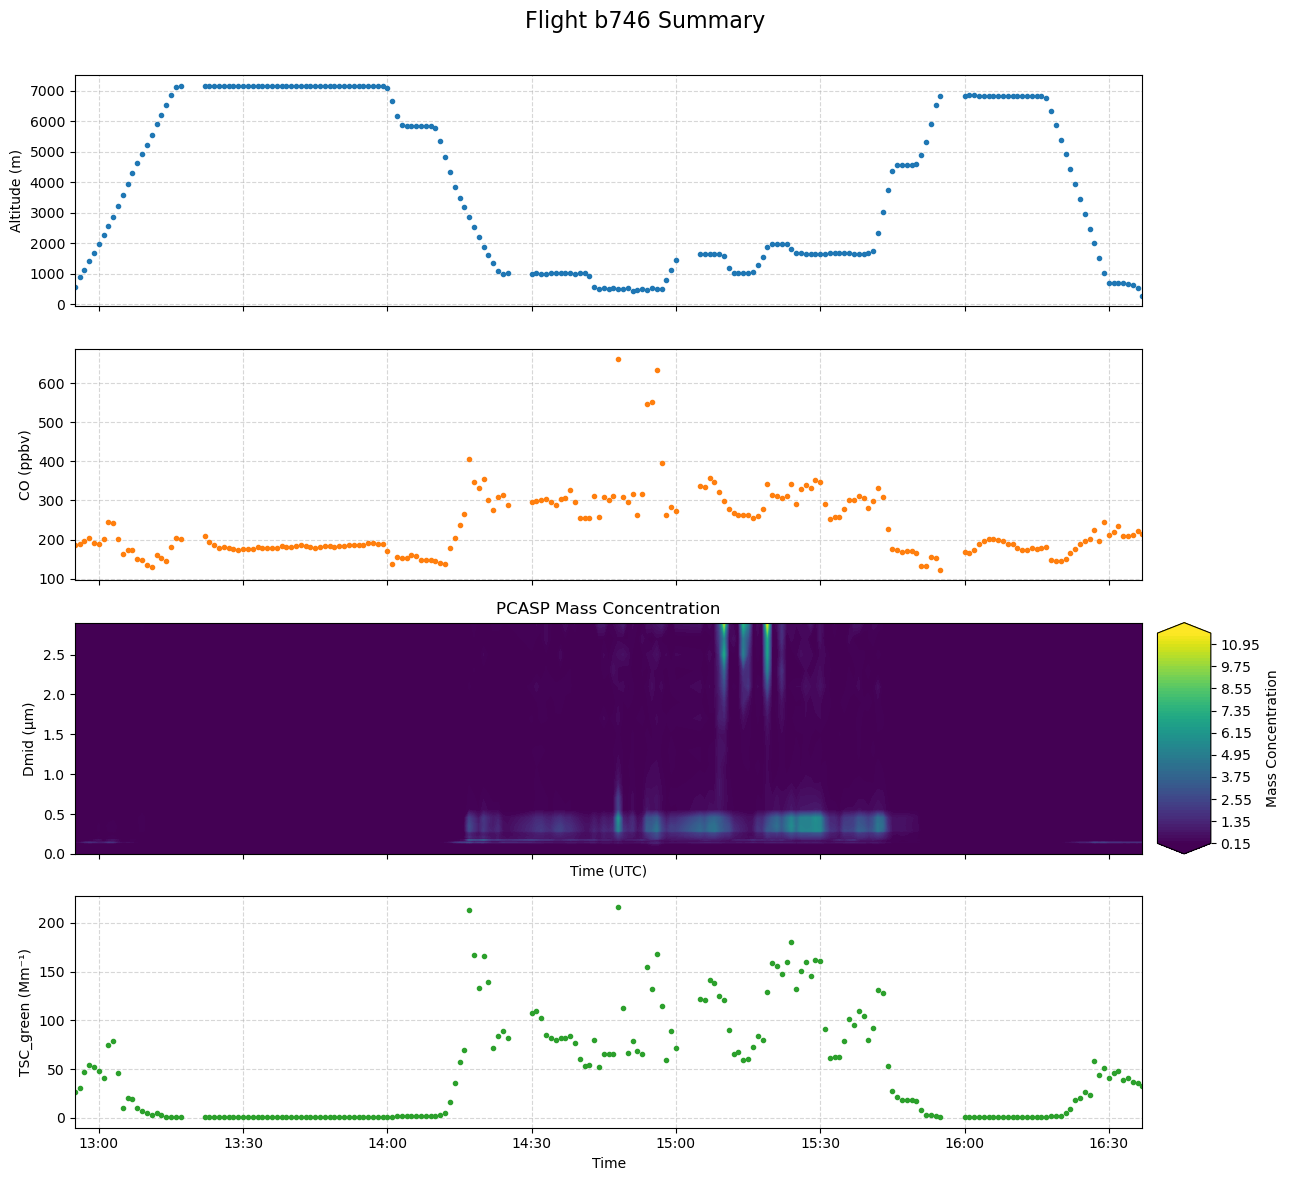

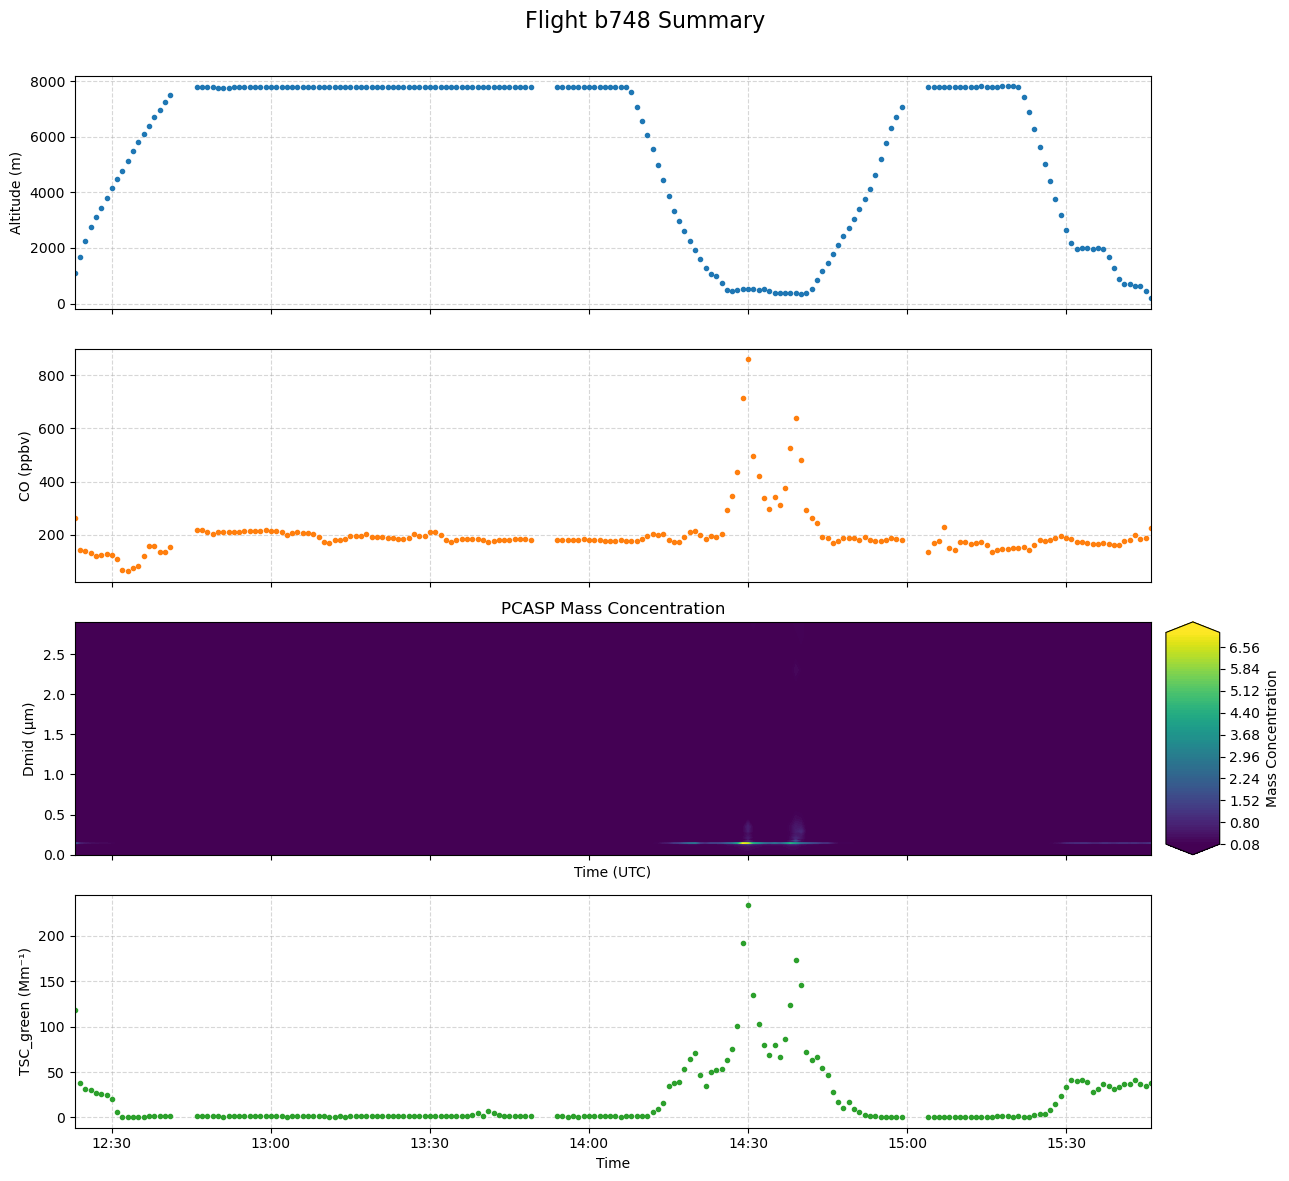

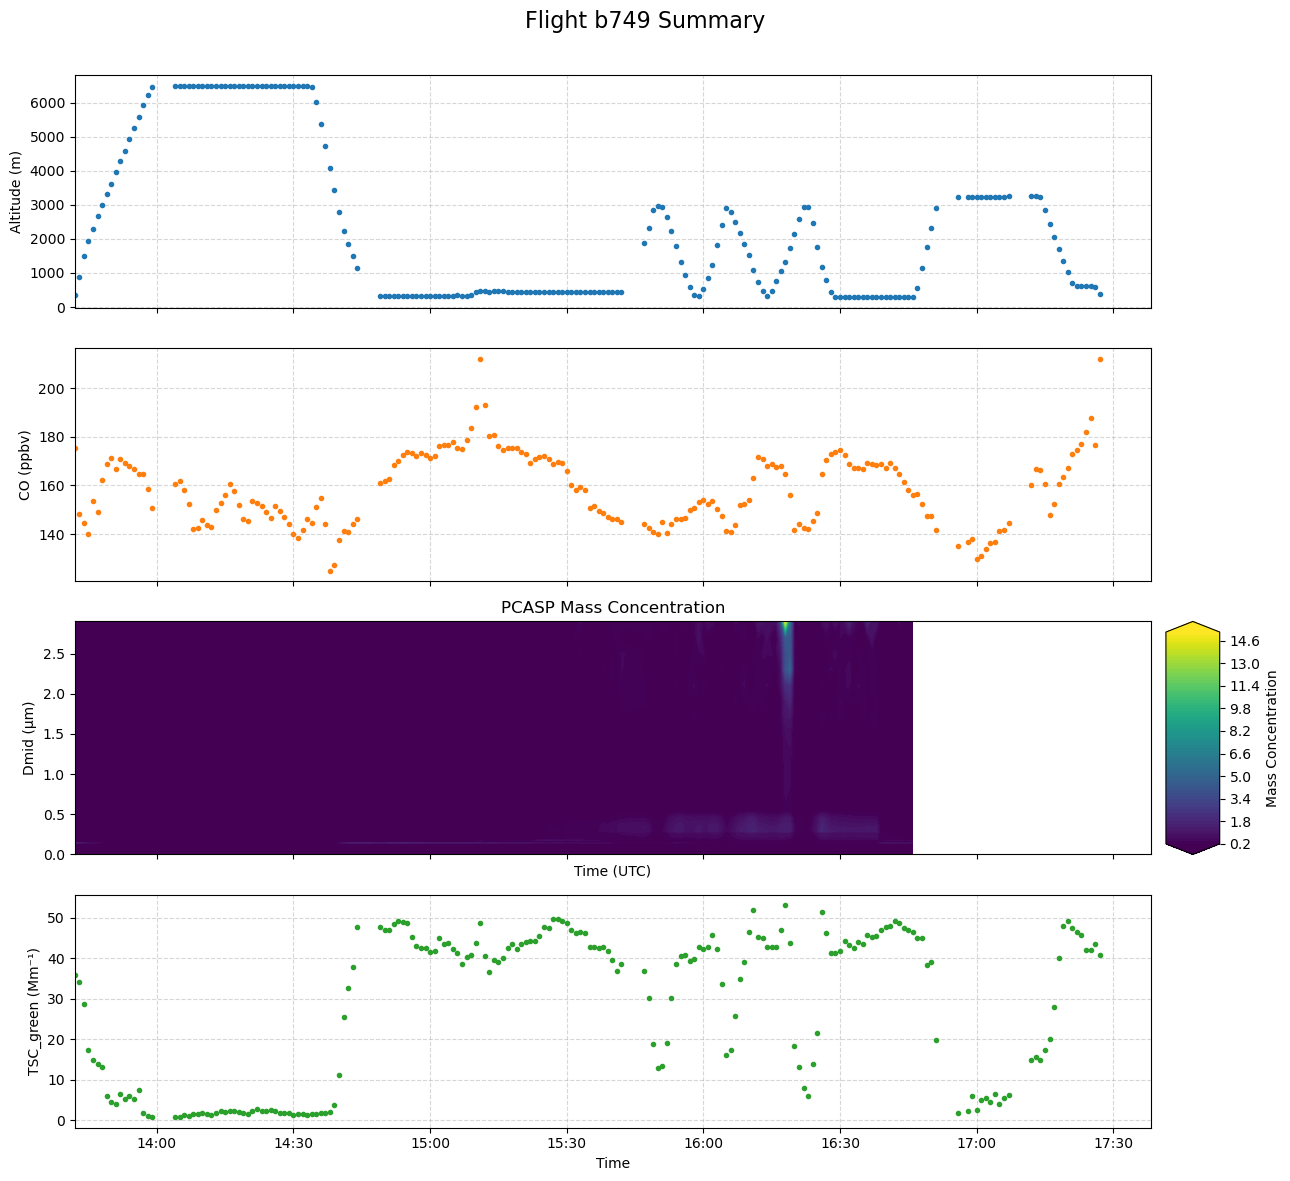

In [179]:
D_lower_limits = ds_core_cloud['PCAS2_D_L_NOM'].values   # shape (30,)
D_upper_limits = ds_core_cloud['PCAS2_D_U_NOM'].values
plot_flight_summary_and_regressions_xr_v4(ds_all_flights,D_lower_limits,D_upper_limits)